<a href="https://colab.research.google.com/github/toluale/Change-Detection-in-Multi-Temporal-Images/blob/main/TSAS_Submission_WorkNoteBook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import re
import glob
import socket
import random
from collections import deque
import zipfile

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_squared_error, accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score

from pathlib import Path
from typing import List, Tuple, Dict

import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import pynvml

In [ ]:
# Data loading and preprocessing pipeline for model training
# Define paths
RASTER_CHIPS_PATH = Path("/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/sam_1/chips/raster_chips/")
DIFF_CHIPS_PATH = Path("/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/sam_1/chips/diff_chips/")
METADATA_PATH = Path("/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/sam_1/chips/")
FULL_RASTER_PATH = Path("/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/")


print("="*60)
print("DATA LOADING AND PREPROCESSING PIPELINE")
print("="*60)

# Load metadata
raster_chips_df = pd.read_csv(FULL_RASTER_PATH / 'full_raster_files_list.csv')
diff_chips_df = pd.read_csv(METADATA_PATH / 'diff_chips_metadata.csv')

print(f"\nLoaded metadata:")
print(f"  - Raster chips: {len(raster_chips_df)}")
print(f"  - Difference chips: {len(diff_chips_df)}")

# Calculate total number of unique spatial locations
#total_images = raster_chips_df['image_index'].nunique()
#chips_per_image = len(raster_chips_df) // total_images

print(f"\nDataset structure:")
#print(f"  - Total images: {total_images}")
#print(f"  - Chips per image: {chips_per_image}")
#print(f"  - Total spatial locations: {chips_per_image}")

DATA LOADING AND PREPROCESSING PIPELINE

Loaded metadata:
  - Raster chips: 1423
  - Difference chips: 16

Dataset structure:


In [ ]:
def load_sequential_images(image_paths: List[Path], target_size: Tuple[int, int] = (256, 256)) -> np.ndarray:
    """
    Load images, resize, and stack along channel axis.

    Args:
        image_paths: List of paths to image files
        target_size: Target size for resizing (height, width)

    Returns:
        np.ndarray: Stacked images with shape (H, W, T*C) where T is time, C is channels
    """
    ims = []
    for p in image_paths:
        img = cv2.imread(str(p))
        if img is None:
            raise ValueError(f"Failed to load image: {p}")
        img = cv2.resize(img, target_size)
        ims.append(img)

    # Stack along last axis and reshape to (H, W, T*C)
    # Each image has shape (H, W, 3), we want to concatenate all channels
    stacked = np.concatenate(ims, axis=-1)  # Changed from np.stack to np.concatenate

    return stacked

# Fixed FFT preprocessing functions
def apply_low_freq_mask(image: np.ndarray, radius: int = 80) -> np.ndarray:
    """
    Keep only low-frequency components via FFT.

    Args:
        image: Input 2D image array (H, W)
        radius: Radius of low-frequency mask

    Returns:
        np.ndarray: Filtered 2D image with only low-frequency components
    """
    # Ensure input is 2D
    if image.ndim != 2:
        raise ValueError(f"Expected 2D image, got shape {image.shape}")

    # Apply FFT
    dft = np.fft.fftshift(np.fft.fft2(image))
    mag = np.abs(dft)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    # Create circular mask
    mask = np.zeros((rows, cols), np.uint8)
    cv2.circle(mask, (ccol, crow), radius, 1, -1)

    # Apply mask to magnitude
    low_mag = mag * mask
    phase = np.angle(dft)
    combined = low_mag * np.exp(1j * phase)

    # Inverse FFT
    inv = np.fft.ifftshift(combined)
    recon = np.real(np.fft.ifft2(inv))

    return np.clip(recon, 0, 255).astype(np.uint8)

def mask_sequence(images: np.ndarray, radius: int = 80) -> np.ndarray:
    """
    Apply low-frequency mask per channel in the sequence.

    Args:
        images: Image sequence with shape (H, W, T*C) where each channel is processed independently
        radius: Radius of low-frequency mask

    Returns:
        np.ndarray: Filtered image sequence with same shape (H, W, T*C)
    """
    # Verify input shape
    if images.ndim != 3:
        raise ValueError(f"Expected 3D array (H, W, Channels), got shape {images.shape}")

    height, width, total_channels = images.shape
    filtered_channels = []

    # Process each channel independently
    for ch_idx in range(total_channels):
        # Extract single channel (H, W)
        channel = images[:, :, ch_idx]

        # Apply FFT filtering
        filtered_channel = apply_low_freq_mask(channel, radius)

        filtered_channels.append(filtered_channel)

    # Stack all filtered channels back together
    result = np.stack(filtered_channels, axis=-1)

    return result

print("\n✓ Fixed preprocessing functions defined")



✓ Fixed preprocessing functions defined


In [ ]:
def get_chip_sequence_paths(self, chip_number: int) -> List[Path]:
    """Get file paths for a chip sequence."""
    paths = []

    if self.using_chips:
        # Chip naming: originalXX_YYY.tif
        # XX = temporal index (01-26), YYY = chip number (001-999)
        for img_idx in range(1, self.actual_temporal_length + 1):
            chip_filename = f"original{img_idx:02d}_{chip_number:03d}.tif"
            chip_path = self.active_raster_path / chip_filename

            if not chip_path.exists():
                raise FileNotFoundError(f"Chip file not found: {chip_path}")

            paths.append(chip_path)
    else:
        # Full raster naming: originalraster_XX_YYY.tif
        for img_idx in range(1, self.actual_temporal_length + 1):
            chip_filename = f"originalraster_{self.sam_folder_num:02d}_{img_idx:03d}.tif"
            chip_path = self.active_raster_path / chip_filename

            if not chip_path.exists():
                raise FileNotFoundError(f"Raster file not found: {chip_path}")

            paths.append(chip_path)

    # Standardize length
    if len(paths) < self.target_temporal_length:
        while len(paths) < self.target_temporal_length:
            paths.append(paths[-1])
    elif len(paths) > self.target_temporal_length:
        paths = paths[:self.target_temporal_length]

    return paths

In [ ]:
def diff_sequence(image_paths: List[Path], target_size: Tuple[int, int] = (256, 256)) -> np.ndarray:
    """
    Load images, normalize, and compute absolute difference between consecutive frames.

    Args:
        image_paths: List of paths to image files (must have at least 2 images)
        target_size: Target size for resizing (height, width)

    Returns:
        np.ndarray: Stacked difference images with shape (H, W, (T-1)*C)
                   where T is number of images, C is channels per image
    """
    if len(image_paths) < 2:
        raise ValueError("Need at least 2 images to compute differences")

    # Load and normalize images
    ims = []
    for p in image_paths:
        img = cv2.imread(str(p))
        if img is None:
            raise ValueError(f"Failed to load image: {p}")
        img = cv2.resize(img, target_size)
        img = img / 255.0  # Normalize to [0, 1]
        ims.append(img)

    # Compute absolute differences between consecutive frames
    diffs = []
    for i in range(len(ims) - 1):
        diff = np.abs(ims[i + 1] - ims[i])

        # Normalize each difference to [0, 1]
        max_val = np.max(diff)
        if max_val > 0:
            diff = diff / max_val

        diffs.append(diff)

    # Stack all differences along the channel axis
    # Each diff has shape (H, W, 3), we concatenate to get (H, W, (T-1)*3)
    stacked_diffs = np.concatenate(diffs, axis=-1)

    return stacked_diffs

print("\n✓ diff_sequence function defined")

# Test the function
print("\nTesting diff_sequence...")



✓ diff_sequence function defined

Testing diff_sequence...


In [ ]:
# Ground Truth Loading Pipeline
# The ground truth for each chip is the building mask from the last temporal image (month 24)

def load_ground_truth(chip_path: Path, target_size: Tuple[int, int] = (256, 256)) -> np.ndarray:
    """
    Load grayscale ground truth mask and threshold to binary mask.

    Args:
        chip_path: Path to the ground truth chip image
        target_size: Target size for resizing (height, width)

    Returns:
        np.ndarray: Binary mask with shape (H, W), values in {0, 1}
    """
    img = cv2.imread(str(chip_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(f"Ground truth not found: {chip_path}")

    # Resize if needed
    if img.shape != target_size:
        img = cv2.resize(img, (target_size[1], target_size[0]))

    # Threshold to binary mask (0 or 1)
    _, bin_mask = cv2.threshold(img, 128, 1, cv2.THRESH_BINARY)

    return bin_mask  # shape (H, W)


def get_ground_truth_path(chip_number: int,
                         diff_chips_path: Path = DIFF_CHIPS_PATH) -> Path:
    """
    Get path to ground truth mask for a specific chip.
    The ground truth is the building mask from the last temporal image (image 24).

    Args:
        chip_number: Chip number (1 to total_chips)
        image_chips_path: Path to image chips directory

    Returns:
        Path to ground truth chip file
    """
    # Ground truth is from image 24 (last temporal image)
    gt_filename = f"diff_01_02_{chip_number:03d}.png"
    gt_path = diff_chips_path / gt_filename

    if not gt_path.exists():
        raise FileNotFoundError(f"Ground truth not found: {gt_path}")

    return gt_path


def load_ground_truth_batch(chip_numbers: List[int],
                            target_size: Tuple[int, int] = (256, 256)) -> np.ndarray:
    """
    Load ground truth masks for a batch of chips.

    Args:
        chip_numbers: List of chip numbers
        target_size: Target size for masks

    Returns:
        np.ndarray: Batch of binary masks with shape (N, H, W)
    """
    gt_masks = []

    for chip_num in chip_numbers:
        gt_path = get_ground_truth_path(chip_num)
        gt_mask = load_ground_truth(gt_path, target_size)
        gt_masks.append(gt_mask)

    return np.array(gt_masks)


print("\n✓ Ground truth loading functions defined")

# Test the ground truth loading
print("\n" + "="*60)
print("TESTING GROUND TRUTH LOADING")
print("="*60)
'''
# Test single chip
test_chip_num = 1
print(f"\nLoading ground truth for chip {test_chip_num}...")

gt_path = get_ground_truth_path(test_chip_num)
print(f"Ground truth path: {gt_path}")

gt_mask = load_ground_truth(gt_path, (256, 256))
print(f"\nGround truth shape: {gt_mask.shape}")
print(f"Ground truth dtype: {gt_mask.dtype}")
print(f"Unique values: {np.unique(gt_mask)}")
print(f"Building pixels: {np.sum(gt_mask)} / {gt_mask.size} ({100*np.mean(gt_mask):.2f}%)")

# Test batch loading
test_batch = [1, 2, 3]
print(f"\n\nLoading ground truth batch for chips: {test_batch}")

gt_batch = load_ground_truth_batch(test_batch, (256, 256))
print(f"Ground truth batch shape: {gt_batch.shape}")
print(f"Building coverage per chip:")
for i, chip_num in enumerate(test_batch):
    coverage = 100 * np.mean(gt_batch[i])
    print(f"  Chip {chip_num}: {coverage:.2f}% building pixels")
'''


✓ Ground truth loading functions defined

TESTING GROUND TRUTH LOADING


'\n# Test single chip\ntest_chip_num = 1\nprint(f"\nLoading ground truth for chip {test_chip_num}...")\n\ngt_path = get_ground_truth_path(test_chip_num)\nprint(f"Ground truth path: {gt_path}")\n\ngt_mask = load_ground_truth(gt_path, (256, 256))\nprint(f"\nGround truth shape: {gt_mask.shape}")\nprint(f"Ground truth dtype: {gt_mask.dtype}")\nprint(f"Unique values: {np.unique(gt_mask)}")\nprint(f"Building pixels: {np.sum(gt_mask)} / {gt_mask.size} ({100*np.mean(gt_mask):.2f}%)")\n\n# Test batch loading\ntest_batch = [1, 2, 3]\nprint(f"\n\nLoading ground truth batch for chips: {test_batch}")\n\ngt_batch = load_ground_truth_batch(test_batch, (256, 256))\nprint(f"Ground truth batch shape: {gt_batch.shape}")\nprint(f"Building coverage per chip:")\nfor i, chip_num in enumerate(test_batch):\n    coverage = 100 * np.mean(gt_batch[i])\n    print(f"  Chip {chip_num}: {coverage:.2f}% building pixels")\n'

In [ ]:
# Multi-SAM Directory Configuration
from pathlib import Path
import glob

# Base path for processed training data
PROCESSED_TRAIN_BASE = Path("/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data")

# Define SAM directories for each split
TRAIN_SAMS = ['sam_52', 'sam_32', 'sam_38', 'sam_32', 'sam_44', 'sam_39', 'sam_50', 'sam_45', 'sam_34', 'sam_43',
              'sam_42', 'sam_41', 'sam_40', 'sam_36','sam_13', 'sam_10', 'sam_37', 'sam_35', 'sam_30', 'sam_29',
              'sam_28', 'sam_27', 'sam_26', 'sam_25', 'sam_24',]
VAL_SAMS = ['sam_60']
TEST_SAMS = ['sam_33']

print("="*60)
print("MULTI-SAM DATA LOADING CONFIGURATION")
print("="*60)

# Function to detect number of temporal images in a sam directory
def detect_temporal_length(sam_dir: Path) -> int:
    """Detect the actual number of temporal images."""
    import re
    image_indices = set()

    # Try chips/raster_chips first (preferred)
    raster_chips_path = sam_dir / 'chips' / 'raster_chips'

    if not raster_chips_path.exists():
        # Fallback to full_raster
        raster_chips_path = sam_dir / 'full_raster'
        if not raster_chips_path.exists():
            return 0

    # Pattern: originalXX_YYY.tif where XX is temporal index
    all_files = list(raster_chips_path.glob('original*.tif'))

    for f in all_files:
        match = re.search(r'original(\d+)_', f.name)
        if match:
            image_indices.add(int(match.group(1)))

    return len(image_indices)

def count_chips_in_sam(sam_dir: Path) -> int:
    """Count the number of chips in a sam directory."""
    # Try chips/raster_chips first (preferred)
    raster_chips_path = sam_dir / 'chips' / 'raster_chips'

    if not raster_chips_path.exists():
        # Fallback to full_raster
        raster_chips_path = sam_dir / 'full_raster'
        if not raster_chips_path.exists():
            return 0

    # Count chips from first temporal image
    # Pattern: original01_001.tif, original01_002.tif, etc.
    first_image_chips = list(raster_chips_path.glob('original01_*.tif'))
    return len(first_image_chips)

# Inspect all SAM directories
print("\nInspecting SAM directories:")
print("-" * 60)

sam_info = {}

for sam_name in TRAIN_SAMS + VAL_SAMS + TEST_SAMS:
    sam_path = PROCESSED_TRAIN_BASE / sam_name

    if not sam_path.exists():
        print(f"  ✗ {sam_name}: Directory not found")
        sam_info[sam_name] = {'exists': False, 'num_images': 0, 'num_chips': 0}
        continue

    num_images = detect_temporal_length(sam_path)
    num_chips = count_chips_in_sam(sam_path)

    sam_info[sam_name] = {
        'exists': True,
        'path': sam_path,
        'num_images': num_images,
        'num_chips': num_chips
    }

    print(f"  ✓ {sam_name:8s}: {num_images:2d} temporal images, {num_chips:4d} chips")

print("\n" + "="*60)
print("DATASET SPLIT SUMMARY")
print("="*60)

def summarize_split(sam_names, split_name):
    print(f"\n{split_name}:")
    total_chips = 0
    image_lengths = []

    for sam_name in sam_names:
        if sam_name in sam_info and sam_info[sam_name]['exists']:
            num_chips = sam_info[sam_name]['num_chips']
            num_images = sam_info[sam_name]['num_images']
            total_chips += num_chips
            image_lengths.append(num_images)
            print(f"  - {sam_name}: {num_chips} chips × {num_images} images")

    if len(image_lengths) > 0:
        print(f"  Total chips: {total_chips}")
        print(f"  Temporal lengths: {set(image_lengths)}")
    else:
        print(f"  No valid data found!")

    return total_chips, image_lengths

train_total, train_lengths = summarize_split(TRAIN_SAMS, "Training Set")
val_total, val_lengths = summarize_split(VAL_SAMS, "Validation Set")
test_total, test_lengths = summarize_split(TEST_SAMS, "Test Set")

print(f"\n" + "="*60)
print(f"Overall: {train_total + val_total + test_total} total chips")
print(f"Temporal variation: Need to handle {len(set(train_lengths + val_lengths + test_lengths))} different temporal lengths")
print("="*60)

MULTI-SAM DATA LOADING CONFIGURATION

Inspecting SAM directories:
------------------------------------------------------------
  ✓ sam_52  : 26 temporal images,   16 chips
  ✓ sam_33  : 25 temporal images,   16 chips
  ✓ sam_38  : 25 temporal images,   16 chips
  ✓ sam_32  : 26 temporal images,   16 chips
  ✓ sam_44  : 23 temporal images,   16 chips
  ✓ sam_39  : 24 temporal images,   16 chips
  ✓ sam_50  : 18 temporal images,   16 chips
  ✓ sam_45  : 24 temporal images,   16 chips
  ✓ sam_34  : 25 temporal images,   16 chips
  ✓ sam_43  : 18 temporal images,   16 chips
  ✓ sam_42  : 22 temporal images,   16 chips
  ✓ sam_41  : 24 temporal images,   16 chips
  ✓ sam_40  : 25 temporal images,   16 chips
  ✓ sam_36  : 25 temporal images,   16 chips
  ✓ sam_13  : 20 temporal images,   16 chips
  ✓ sam_10  : 24 temporal images,   16 chips
  ✓ sam_37  : 25 temporal images,   16 chips
  ✓ sam_35  : 23 temporal images,   16 chips
  ✓ sam_30  : 24 temporal images,   16 chips
  ✓ sam_29  : 24 t

In [ ]:
TEST_SAMS = ['sam_33']
test_total, test_lengths = summarize_split(TEST_SAMS, "Test Set")


Test Set:
  - sam_33: 16 chips × 25 images
  Total chips: 16
  Temporal lengths: {25}


In [ ]:
def load_ground_truth(chip_path: Path, target_size: Tuple[int, int] = (256, 256)) -> np.ndarray:
    """
    Load grayscale ground truth mask and threshold to binary mask.

    Args:
        chip_path: Path to the ground truth chip image
        target_size: Target size for resizing (height, width)

    Returns:
        np.ndarray: Binary mask with shape (H, W), values in {0, 1}
    """
    img = cv2.imread(str(chip_path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise FileNotFoundError(f"Ground truth not found: {chip_path}")

    # Resize if needed
    if img.shape != target_size:
        img = cv2.resize(img, (target_size[1], target_size[0]))

    # Threshold to binary mask (0 or 1)
    _, bin_mask = cv2.threshold(img, 128, 1, cv2.THRESH_BINARY)

    return bin_mask  # shape (H, W)


def get_ground_truth_path_fullraster(sam_path: Path, target_size: Tuple[int, int] = (256, 256)) -> Path:
    """
    Get path to full raster ground truth difference mask for a SAM directory.
    The ground truth is the difference between first and last temporal images.

    Args:
        sam_path: Path to SAM directory (e.g., sam_1, sam_52)

    Returns:
        Path to ground truth difference file
    """
    # Look for ground truth file with pattern: diff_first_to_last_*.png
    gt_files = list(sam_path.glob('diff_first_to_last_*.png'))

    if len(gt_files) == 0:
        raise FileNotFoundError(f"Ground truth difference file not found in {sam_path}")

    if len(gt_files) > 1:
        print(f"  ⚠ Warning: Multiple ground truth files found in {sam_path.name}, using first one")

    return gt_files[0]


print("\n✓ Updated ground truth loading functions for full raster")


✓ Updated ground truth loading functions for full raster


In [ ]:
# Delete cells #VSC-bd75abf8 and #VSC-1bf92419, then use this unified version:

class MultiSAMDataLoader:
    """
    Data loader for multiple SAM directories with varying temporal lengths.
    Handles BOTH chip-based and full-raster loading automatically.
    """
    def __init__(self, sam_path: Path, target_temporal_length: int = 25,
                 target_size: Tuple[int, int] = (256, 256),
                 fft_radius: int = 150,
                 min_building_coverage: float = 0.01,  # ✓ NEW: Min 1% buildings
                 max_building_coverage: float = 0.95):
        """Initialize the multi-SAM data loader."""
        self.sam_path = sam_path
        self.sam_name = sam_path.name
        self.target_temporal_length = target_temporal_length
        self.target_size = target_size
        self.fft_radius = fft_radius
        self.min_building_coverage = min_building_coverage
        self.max_building_coverage = max_building_coverage

        # Extract SAM folder number
        import re
        match = re.search(r'sam_(\d+)', self.sam_name)
        self.sam_folder_num = int(match.group(1)) if match else 1

        # Define paths
        self.raster_chips_path = sam_path / 'chips' / 'raster_chips'
        self.full_raster_path = sam_path / 'full_raster'
        self.diff_chips_path = sam_path / 'chips' / 'diff_chips'

        # ✅ AUTO-DETECT: Prefer raster_chips if it exists
        if self.raster_chips_path.exists():
            self.active_raster_path = self.raster_chips_path
            self.using_chips = True
            print(f"  ✓ Using chips/raster_chips directory")
        elif self.full_raster_path.exists():
            self.active_raster_path = self.full_raster_path
            self.using_chips = False
            print(f"  ✓ Using full_raster directory")
        else:
            raise FileNotFoundError(f"No raster data found in {sam_path}")

        # Detect temporal length and count chips
        self.actual_temporal_length = self._detect_temporal_length()
        self.total_chips = self._count_chips()

        # Load full raster ground truth (if using full raster)
        self.full_gt = None
        if not self.using_chips:
            try:
                gt_path = get_ground_truth_path_fullraster(sam_path)
                self.full_gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
                if self.full_gt is None:
                    raise ValueError(f"Failed to load GT from {gt_path}")
                print(f"  ✓ Loaded full raster GT: {self.full_gt.shape}")
            except FileNotFoundError as e:
                print(f"  ⚠ Warning: {e}")

        print(f"  Initialized {self.sam_name}:")
        print(f"    - Temporal length: {self.actual_temporal_length}/{self.target_temporal_length}")
        print(f"    - Total chips: {self.total_chips}")

        # Filter valid chips during initialization
        self.valid_chip_indices = self._filter_valid_chips()
        self.total_chips = len(self.valid_chip_indices)

        print(f"    - Valid chips after filtering: {self.total_chips}")

    def _detect_temporal_length(self) -> int:
        """Detect the actual number of temporal images."""
        import re
        image_indices = set()
        all_files = list(self.active_raster_path.glob('original*.tif'))

        for f in all_files:
            if self.using_chips:
                # Chip naming: original01_001.tif (temporal index = 01)
                match = re.search(r'original(\d+)_', f.name)
            else:
                # Full raster naming: originalraster_52_001.tif (temporal index = 001)
                match = re.search(r'originalraster_\d+_(\d+)', f.name)

            if match:
                image_indices.add(int(match.group(1)))

        return len(image_indices)

    def _filter_valid_chips(self) -> List[int]:
        """
        Filter chips based on ground truth quality.
        Returns list of valid chip indices.
        """
        if not self.using_chips:
            return [1]  # Full raster always valid

        valid_indices = []

        for chip_num in range(1, self._count_all_chips() + 1):
            try:
                # Load ground truth for this chip
                gt_filename = f"diff_01_{chip_num:03d}.png"
                gt_path = self.diff_chips_path / gt_filename

                if not gt_path.exists():
                    gt_path = self.diff_chips_path / f"diff_01_02_{chip_num:03d}.png"

                if not gt_path.exists():
                    continue  # Skip chips without GT

                # Load and check coverage
                gt = cv2.imread(str(gt_path), cv2.IMREAD_GRAYSCALE)
                if gt is None:
                    continue

                # Calculate building coverage
                _, gt_binary = cv2.threshold(gt, 128, 1, cv2.THRESH_BINARY)
                coverage = float(np.mean(gt_binary))

                # ✓ FILTER: Keep chips within acceptable range
                if self.min_building_coverage <= coverage <= self.max_building_coverage:
                    valid_indices.append(chip_num)
                else:
                    print(f"      Filtered chip {chip_num}: coverage={coverage*100:.2f}%")

            except Exception as e:
                print(f"      Error checking chip {chip_num}: {e}")
                continue

        return valid_indices

    def _count_all_chips(self) -> int:
        """Count total chips before filtering."""
        if self.using_chips:
            first_image_chips = list(self.active_raster_path.glob('original01_*.tif'))
            return len(first_image_chips)
        else:
            return 1

    def _count_chips(self) -> int:
        """Count the number of chips (unique spatial locations)."""
        if self.using_chips:
            # Count chips from first temporal image
            first_image_chips = list(self.active_raster_path.glob('original01_*.tif'))
            return len(first_image_chips)
        else:
            # Full raster: only 1 sample
            return 1

    def get_chip_sequence_paths(self, chip_number: int) -> List[Path]:
        """Get file paths for a chip/raster sequence."""
        paths = []

        if self.using_chips:
            # Chip naming: original{temporal:02d}_{chip:03d}.tif
            for img_idx in range(1, self.actual_temporal_length + 1):
                chip_filename = f"original{img_idx:02d}_{chip_number:03d}.tif"
                chip_path = self.active_raster_path / chip_filename

                if not chip_path.exists():
                    raise FileNotFoundError(f"Chip not found: {chip_path}")

                paths.append(chip_path)
        else:
            # Full raster naming: originalraster_{sam:02d}_{temporal:03d}.tif
            for img_idx in range(1, self.actual_temporal_length + 1):
                raster_filename = f"originalraster_{self.sam_folder_num:02d}_{img_idx:03d}.tif"
                raster_path = self.active_raster_path / raster_filename

                if not raster_path.exists():
                    raise FileNotFoundError(f"Raster not found: {raster_path}")

                paths.append(raster_path)

        # Standardize length (pad/truncate)
        while len(paths) < self.target_temporal_length:
            paths.append(paths[-1])  # Repeat last frame

        if len(paths) > self.target_temporal_length:
            paths = paths[:self.target_temporal_length]

        return paths

    def load_chip_sequence(self, chip_number: int,
                          apply_fft: bool = True,
                          compute_diffs: bool = False,
                          apply_fft_to_diffs: bool = True,  # ✅ NEW PARAMETER
                          load_original: bool = True,
                          load_gt: bool = True) -> Dict[str, np.ndarray]:
        """Load a complete chip/raster sequence with preprocessing."""

        # Get paths
        chip_paths = self.get_chip_sequence_paths(chip_number)

        # Load original sequence (0-255 range)
        sequence = load_sequential_images(chip_paths, self.target_size)

        # Normalize (0-1 range)
        sequence_normalized = None
        if load_original:
            sequence_normalized = sequence / 255.0

        # Apply FFT preprocessing
        sequence_fft = None
        if apply_fft:
            sequence_fft = mask_sequence(sequence, self.fft_radius)

        # Compute spatial differences
        sequence_diff = None
        if compute_diffs:
            sequence_diff = diff_sequence(chip_paths, self.target_size)

        # ✅ NEW: Apply FFT to difference images
        sequence_diff_fft = None
        if compute_diffs and apply_fft_to_diffs:
            # Convert normalized differences to 0-255 range for FFT
            sequence_diff_uint8 = (sequence_diff * 255).astype(np.uint8)
            sequence_diff_fft = mask_sequence(sequence_diff_uint8, self.fft_radius)

        # Load ground truth
        ground_truth = None
        if load_gt:
            if self.using_chips:
                # Load chip-specific ground truth
                gt_filename = f"diff_01_{chip_number:03d}.png"
                gt_path = self.diff_chips_path / gt_filename

                if not gt_path.exists():
                    gt_path = self.diff_chips_path / f"diff_01_02_{chip_number:03d}.png"

                if gt_path.exists():
                    ground_truth = load_ground_truth(gt_path, self.target_size)
                else:
                    print(f"    ⚠ Warning: GT not found for chip {chip_number}")
            else:
                # Use full raster ground truth
                if self.full_gt is not None:
                    gt_resized = cv2.resize(self.full_gt,
                                           (self.target_size[1], self.target_size[0]))
                    _, ground_truth = cv2.threshold(gt_resized, 128, 1, cv2.THRESH_BINARY)

        # Metadata
        metadata = {
            'sam_name': self.sam_name,
            'chip_number': chip_number,
            'actual_temporal_length': self.actual_temporal_length,
            'target_temporal_length': self.target_temporal_length,
            'sequence_shape': sequence.shape,
            'using_chips': self.using_chips,
            'building_coverage': float(np.mean(ground_truth)) if ground_truth is not None else None
        }

        return {
            'sequence': sequence,
            'sequence_normalized': sequence_normalized,
            'sequence_fft': sequence_fft,
            'sequence_diff': sequence_diff,
            'sequence_diff_fft': sequence_diff_fft,  # ✅ NEW OUTPUT
            'ground_truth': ground_truth,
            'metadata': metadata
        }

    def load_all_chips(self, apply_fft: bool = True, compute_diffs: bool = False,
                       apply_fft_to_diffs: bool = True,  # ✅ NEW PARAMETER
                       load_original: bool = True, load_gt: bool = True) -> Dict[str, np.ndarray]:
        """Load all chips/rasters from this SAM directory."""
        all_data = {
            'sequences': [],
            'sequences_normalized': [],
            'sequences_fft': [],
            'sequences_diff': [],
            'sequences_diff_fft': [],  # ✅ NEW KEY
            'ground_truths': [],
            'metadata': []
        }

        for chip_num in self.valid_chip_indices:
            try:
                data = self.load_chip_sequence(
                    chip_num, apply_fft, compute_diffs, load_original, load_gt
                )

                all_data['sequences'].append(data['sequence'])

                if data['sequence_normalized'] is not None:
                    all_data['sequences_normalized'].append(data['sequence_normalized'])

                if data['sequence_fft'] is not None:
                    all_data['sequences_fft'].append(data['sequence_fft'])

                if data['sequence_diff'] is not None:
                    all_data['sequences_diff'].append(data['sequence_diff'])

                # ✅ NEW: Append diff FFT
                if data['sequence_diff_fft'] is not None:
                    all_data['sequences_diff_fft'].append(data['sequence_diff_fft'])

                if data['ground_truth'] is not None:
                    all_data['ground_truths'].append(data['ground_truth'])

                all_data['metadata'].append(data['metadata'])

            except Exception as e:
                print(f"    ✗ Error loading chip {chip_num}: {e}")
                continue

        # Convert to numpy arrays
        result = {}
        for key, value in all_data.items():
            if len(value) > 0 and key != 'metadata':
                result[key] = np.array(value)
            else:
                result[key] = value

        return result


# Keep your existing load_multi_sam_dataset() function - it's fine!

print("\n✓ Unified MultiSAMDataLoader class defined")


✓ Unified MultiSAMDataLoader class defined


In [ ]:
def load_multi_sam_dataset(sam_names: List[str],
                           base_path: Path = PROCESSED_TRAIN_BASE,
                           target_temporal_length: int = 25,
                           apply_fft: bool = True,
                           compute_diffs: bool = False,
                           apply_fft_to_diffs: bool = True,  # ✅ NEW PARAMETER
                           load_original: bool = True,
                           load_gt: bool = True) -> Dict[str, np.ndarray]:
    """
    Load data from multiple SAM directories and combine them.

    Args:
        sam_names: List of SAM directory names (e.g., ['sam_1', 'sam_2'])
        base_path: Base path to processed training data
        target_temporal_length: Standardized temporal length
        apply_fft: Whether to apply FFT preprocessing
        compute_diffs: Whether to compute spatial differences
        load_original: Whether to load original sequences
        load_gt: Whether to load ground truth

    Returns:
        Combined dataset dictionary
    """
    print(f"\nLoading data from {len(sam_names)} SAM directories...")

    combined_data = {
        'sequences': [],
        'sequences_normalized': [],
        'sequences_fft': [],
        'sequences_diff': [],
        'sequences_diff_fft': [],  # ✅ NEW KEY
        'ground_truths': [],
        'metadata': []
    }

    for sam_name in sam_names:
        sam_path = base_path / sam_name

        if not sam_path.exists():
            print(f"  ✗ {sam_name}: Directory not found, skipping")
            continue

        print(f"\n  Loading {sam_name}...")

        # Initialize loader for this SAM
        loader = MultiSAMDataLoader(
            sam_path=sam_path,
            target_temporal_length=target_temporal_length,
            target_size=(256, 256),
            fft_radius=150
        )

        # Load all chips from this SAM
        sam_data = loader.load_all_chips(apply_fft, compute_diffs, apply_fft_to_diffs, load_original, load_gt)

        # Append to combined dataset
        for key in ['sequences', 'sequences_normalized', 'sequences_fft',
                    'sequences_diff', 'sequences_diff_fft', 'ground_truths', 'metadata']:
            if key in sam_data and len(sam_data[key]) > 0:
                combined_data[key].append(sam_data[key])

        print(f"    Loaded {len(sam_data['metadata'])} chips from {sam_name}")

    # Concatenate all data
    final_data = {}
    for key, value in combined_data.items():
        if len(value) > 0 and key != 'metadata':
            final_data[key] = np.concatenate(value, axis=0)
            print(f"\n  Combined {key}: {final_data[key].shape}")
        elif key == 'metadata':
            # Flatten metadata list
            final_data[key] = [item for sublist in value for item in sublist]
        else:
            final_data[key] = np.array([])

    return final_data


print("\n✓ MultiSAMDataLoader class defined")
print("✓ load_multi_sam_dataset function defined")
print("\n✓ MultiSAMDataLoader class updated for full raster with difference ground truth")



✓ MultiSAMDataLoader class defined
✓ load_multi_sam_dataset function defined

✓ MultiSAMDataLoader class updated for full raster with difference ground truth


In [ ]:
# Should show which mode it's using for each SAM
train_data = load_multi_sam_dataset(
    sam_names=TRAIN_SAMS[:1],  # Test with just 2 SAMs first
    base_path=PROCESSED_TRAIN_BASE,
    target_temporal_length=25,
    apply_fft=True,
    compute_diffs=False,
    load_original=True,
    load_gt=True
)

print(f"Total chips loaded: {len(train_data['sequences'])}")
print(f"Expected: {sum([sam_info[sam]['num_chips'] for sam in TRAIN_SAMS[:2]])}")


Loading data from 1 SAM directories...

  Loading sam_52...
  ✓ Using chips/raster_chips directory
  Initialized sam_52:
    - Temporal length: 26/25
    - Total chips: 16
      Filtered chip 3: coverage=0.48%
      Filtered chip 4: coverage=0.60%
      Filtered chip 5: coverage=0.49%
      Filtered chip 8: coverage=0.25%
      Filtered chip 13: coverage=0.53%
      Filtered chip 16: coverage=0.99%
    - Valid chips after filtering: 10
    Loaded 10 chips from sam_52

  Combined sequences: (10, 256, 256, 75)

  Combined sequences_normalized: (10, 256, 256, 75)

  Combined sequences_fft: (10, 256, 256, 75)

  Combined ground_truths: (10, 256, 256)
Total chips loaded: 10
Expected: 32


In [ ]:
# Function to detect number of temporal images in a sam directory
def detect_temporal_length(sam_dir: Path) -> int:
    """Detect the number of temporal images in a sam directory."""
    raster_chips_path = sam_dir / 'full_raster'

    if not raster_chips_path.exists():
        print(f"  ✗ {sam_dir.name}: full_raster directory not found")
        return 0

    # Extract image indices from filenames (new naming convention)
    import re
    image_indices = set()
    all_files = list(raster_chips_path.glob('originalraster_*.tif'))

    for f in all_files:
        # New naming: originalraster_XX_YYY.tif
        match = re.search(r'originalraster_\d+_(\d+)', f.name)
        if match:
            image_indices.add(int(match.group(1)))

    num_images = len(image_indices)
    return num_images


def count_chips_in_sam(sam_dir: Path) -> int:
    """
    Count the number of chips in a sam directory.
    For full raster approach, always returns 1.
    """
    raster_chips_path = sam_dir / 'full_raster'

    if not raster_chips_path.exists():
        return 0

    # With full raster approach, we have 1 sample per SAM directory
    return 1


print("\n✓ Detection functions updated for new naming convention")


✓ Detection functions updated for new naming convention


In [ ]:
# Load complete datasets
print("="*80)
print("LOADING COMPLETE DATASETS")
print("="*80)

# Set target temporal length (standardize to 24 months)
TARGET_TEMPORAL_LENGTH = 26

# Load Training Set (sam_1 to sam_5)
print("\n" + "="*80)
print("LOADING TRAINING SET")
print("="*80)
train_data = load_multi_sam_dataset(
    sam_names=TRAIN_SAMS,
    base_path=PROCESSED_TRAIN_BASE,
    target_temporal_length=TARGET_TEMPORAL_LENGTH,
    apply_fft=True,
    compute_diffs=True,
    apply_fft_to_diffs=True,
    load_original=True,
    load_gt=True
)

# Load Validation Set (sam_6)
print("\n" + "="*80)
print("LOADING VALIDATION SET")
print("="*80)
val_data = load_multi_sam_dataset(
    sam_names=VAL_SAMS,
    base_path=PROCESSED_TRAIN_BASE,
    target_temporal_length=TARGET_TEMPORAL_LENGTH,
    apply_fft=True,
    compute_diffs=True,
    apply_fft_to_diffs=True,
    load_original=True,
    load_gt=True
)

# Load Test Set (sam_8)
print("\n" + "="*80)
print("LOADING TEST SET")
print("="*80)
test_data = load_multi_sam_dataset(
    sam_names=TEST_SAMS,
    base_path=PROCESSED_TRAIN_BASE,
    target_temporal_length=TARGET_TEMPORAL_LENGTH,
    apply_fft=True,
    compute_diffs=True,
    apply_fft_to_diffs=True,
    load_original=True,
    load_gt=True
)

# Add expanded ground truth for model compatibility
print("\n" + "="*80)
print("PREPARING DATA FOR TRAINING")
print("="*80)

if 'ground_truths' in train_data and len(train_data['ground_truths']) > 0:
    train_data['ground_truths_expanded'] = np.expand_dims(train_data['ground_truths'], axis=-1)
    print(f"✓ Training ground truth expanded: {train_data['ground_truths_expanded'].shape}")

if 'ground_truths' in val_data and len(val_data['ground_truths']) > 0:
    val_data['ground_truths_expanded'] = np.expand_dims(val_data['ground_truths'], axis=-1)
    print(f"✓ Validation ground truth expanded: {val_data['ground_truths_expanded'].shape}")

if 'ground_truths' in test_data and len(test_data['ground_truths']) > 0:
    test_data['ground_truths_expanded'] = np.expand_dims(test_data['ground_truths'], axis=-1)
    print(f"✓ Test ground truth expanded: {test_data['ground_truths_expanded'].shape}")

# Final summary
print("\n" + "="*80)
print("FINAL DATASET SUMMARY")
print("="*80)

print("\nTraining Set:")
if 'sequences' in train_data and len(train_data['sequences']) > 0:
    print(f"  - Sequences: {train_data['sequences'].shape}")
    print(f"  - Original Sequences (normalized): {train_data['sequences_normalized'].shape}")
    print(f"  - FFT Sequences: {train_data['sequences_fft'].shape}")
    print(f"  - Diff Sequences: {train_data['sequences_diff'].shape}")
    print(f"  - Ground Truth: {train_data['ground_truths'].shape}")
    print(f"  - Ground Truth (expanded): {train_data['ground_truths_expanded'].shape}")
    print(f"  - Total samples: {len(train_data['sequences'])}")
    print(f"  - sequences_diff_fft: {train_data['sequences_diff_fft'].shape}")
else:
    print("  ✗ No training data loaded!")

print("\nValidation Set:")
if 'sequences' in val_data and len(val_data['sequences']) > 0:
    print(f"  - Sequences: {val_data['sequences'].shape}")
    print(f"  - Original Sequences (normalized): {val_data['sequences_normalized'].shape}")
    print(f"  - FFT Sequences: {val_data['sequences_fft'].shape}")
    print(f"  - Diff Sequences: {val_data['sequences_diff'].shape}")
    print(f"  - Ground Truth: {val_data['ground_truths'].shape}")
    print(f"  - Ground Truth (expanded): {val_data['ground_truths_expanded'].shape}")
    print(f"  - Total samples: {len(val_data['sequences'])}")
    print(f"  - sequences_diff_fft: {val_data['sequences_diff_fft'].shape}")
else:
    print("  ✗ No validation data loaded!")

print("\nTest Set:")
if 'sequences' in test_data and len(test_data['sequences']) > 0:
    print(f"  - Sequences: {test_data['sequences'].shape}")
    print(f"  - Original Sequences (normalized): {test_data['sequences_normalized'].shape}")
    print(f"  - FFT Sequences: {test_data['sequences_fft'].shape}")
    print(f"  - Diff Sequences: {test_data['sequences_diff'].shape}")
    print(f"  - Ground Truth: {test_data['ground_truths'].shape}")
    print(f"  - Ground Truth (expanded): {test_data['ground_truths_expanded'].shape}")
    print(f"  - Total samples: {len(test_data['sequences'])}")
    print(f"  - sequences_diff_fft: {test_data['sequences_diff_fft'].shape}")
else:
    print("  ✗ No test data loaded!")

print("\n" + "="*80)
print("DATA READY FOR TRAINING!")
print("="*80)

LOADING COMPLETE DATASETS

LOADING TRAINING SET

Loading data from 25 SAM directories...

  Loading sam_52...
  ✓ Using chips/raster_chips directory
  Initialized sam_52:
    - Temporal length: 26/26
    - Total chips: 16
      Filtered chip 3: coverage=0.48%
      Filtered chip 4: coverage=0.60%
      Filtered chip 5: coverage=0.49%
      Filtered chip 8: coverage=0.25%
      Filtered chip 13: coverage=0.53%
      Filtered chip 16: coverage=0.99%
    - Valid chips after filtering: 10
    Loaded 10 chips from sam_52

  Loading sam_33...
  ✓ Using chips/raster_chips directory
  Initialized sam_33:
    - Temporal length: 25/26
    - Total chips: 16
      Filtered chip 1: coverage=0.84%
      Filtered chip 2: coverage=0.00%
      Filtered chip 3: coverage=0.05%
      Filtered chip 6: coverage=0.03%
      Filtered chip 8: coverage=0.60%
      Filtered chip 9: coverage=0.41%
      Filtered chip 13: coverage=0.44%
      Filtered chip 16: coverage=0.75%
    - Valid chips after filtering: 8
  

In [ ]:
TARGET_TEMPORAL_LENGTH = 26

# Load Test Set (sam_8)
print("\n" + "="*80)
print("LOADING TEST SET")
print("="*80)
test_data = load_multi_sam_dataset(
    sam_names=TEST_SAMS,
    base_path=PROCESSED_TRAIN_BASE,
    target_temporal_length=TARGET_TEMPORAL_LENGTH,
    apply_fft=True,
    compute_diffs=True,
    load_original=True,
    load_gt=True
)

if 'ground_truths' in test_data and len(test_data['ground_truths']) > 0:
    test_data['ground_truths_expanded'] = np.expand_dims(test_data['ground_truths'], axis=-1)
    print(f"✓ Test ground truth expanded: {test_data['ground_truths_expanded'].shape}")


LOADING TEST SET

Loading data from 1 SAM directories...

  Loading sam_33...
  ✓ Using chips/raster_chips directory
  Initialized sam_33:
    - Temporal length: 25/26
    - Total chips: 16
      Filtered chip 1: coverage=0.84%
      Filtered chip 2: coverage=0.00%
      Filtered chip 3: coverage=0.05%
      Filtered chip 6: coverage=0.03%
      Filtered chip 8: coverage=0.60%
      Filtered chip 9: coverage=0.41%
      Filtered chip 13: coverage=0.44%
      Filtered chip 16: coverage=0.75%
    - Valid chips after filtering: 8
    Loaded 8 chips from sam_33

  Combined sequences: (8, 256, 256, 78)

  Combined sequences_normalized: (8, 256, 256, 78)

  Combined sequences_fft: (8, 256, 256, 78)

  Combined sequences_diff: (8, 256, 256, 75)

  Combined sequences_diff_fft: (8, 256, 256, 75)

  Combined ground_truths: (8, 256, 256)
✓ Test ground truth expanded: (8, 256, 256, 1)


In [ ]:
# Data Quality Check
print("="*80)
print("DATA QUALITY CHECK")
print("="*80)

def check_data_quality(data, split_name):
    """Check data quality for a dataset split."""
    print(f"\n{split_name}:")

    if 'sequences' not in data or len(data['sequences']) == 0:
        print("  ✗ No data loaded!")
        return

    # Check shapes
    print(f"  ✓ Loaded {len(data['sequences'])} samples")

    # Check for NaN or Inf values
    has_issues = False

    for key in ['sequences', 'sequences_normalized', 'sequences_fft', 'sequences_diff', 'ground_truths']:
        if key in data and len(data[key]) > 0:
            arr = data[key]
            nan_count = np.isnan(arr).sum()
            inf_count = np.isinf(arr).sum()

            if nan_count > 0 or inf_count > 0:
                print(f"  ✗ {key}: {nan_count} NaN, {inf_count} Inf values")
                has_issues = True

    if not has_issues:
        print(f"  ✓ No NaN or Inf values detected")

    # Check value ranges
    if 'sequences_normalized' in data and len(data['sequences_normalized']) > 0:
        min_val = data['sequences_normalized'].min()
        max_val = data['sequences_normalized'].max()
        print(f"  ✓ Normalized sequence range: [{min_val:.4f}, {max_val:.4f}]")

    if 'ground_truths' in data and len(data['ground_truths']) > 0:
        unique_vals = np.unique(data['ground_truths'])
        coverage = 100 * np.mean(data['ground_truths'])
        print(f"  ✓ Ground truth unique values: {unique_vals}")
        print(f"  ✓ Average building coverage: {coverage:.2f}%")

    # Check metadata
    if 'metadata' in data and len(data['metadata']) > 0:
        sam_names = set([m['sam_name'] for m in data['metadata']])
        print(f"  ✓ SAM directories: {sam_names}")

# Check all splits
check_data_quality(train_data, "Training Set")
check_data_quality(val_data, "Validation Set")
check_data_quality(test_data, "Test Set")

print("\n" + "="*80)

DATA QUALITY CHECK

Training Set:
  ✓ Loaded 115 samples
  ✓ No NaN or Inf values detected
  ✓ Normalized sequence range: [0.0000, 1.0000]
  ✓ Ground truth unique values: [0 1]
  ✓ Average building coverage: 2.95%
  ✓ SAM directories: {'sam_39', 'sam_24', 'sam_50', 'sam_40', 'sam_30', 'sam_27', 'sam_43', 'sam_41', 'sam_36', 'sam_38', 'sam_37', 'sam_29', 'sam_52', 'sam_10', 'sam_44', 'sam_35', 'sam_13', 'sam_45', 'sam_33', 'sam_32', 'sam_34', 'sam_25'}

Validation Set:
  ✓ Loaded 5 samples
  ✓ No NaN or Inf values detected
  ✓ Normalized sequence range: [0.0000, 1.0000]
  ✓ Ground truth unique values: [0 1]
  ✓ Average building coverage: 4.16%
  ✓ SAM directories: {'sam_60'}

Test Set:
  ✓ Loaded 8 samples
  ✓ No NaN or Inf values detected
  ✓ Normalized sequence range: [0.0000, 1.0000]
  ✓ Ground truth unique values: [0 1]
  ✓ Average building coverage: 4.48%
  ✓ SAM directories: {'sam_33'}



In [ ]:
'''def build_frequency_decoder(input_channels=75):
    inp = layers.Input((256, 256, input_channels))
    x = layers.Conv2D(64,3,padding='same')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Conv2D(128,3,padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Conv2D(256,3,padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)

    x = layers.Conv2D(128, 3, padding='same')(x)  # ✓ ADDED INTERMEDIATE LAYER
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dropout(0.1)(x)

    x = layers.Conv2D(64,3,padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Conv2D(input_channels,1,padding='same')(x)
    x = layers.Add()([x, inp])
    out = layers.Conv2D(1,3,padding='same',activation='sigmoid')(x)
    return models.Model(inp, out, name="FrequencyDecoder")
'''
def build_frequency_decoder(input_channels=75):
    """
    U-Net style frequency decoder with skip connections.
    Preserves fine details needed to detect small buildings.
    """
    inp = layers.Input((256, 256, input_channels))

    # ========== ENCODER (DOWNSAMPLING) ==========
    # Block 1: 1024x1024 -> 512x512
    conv1 = layers.Conv2D(64, 3, padding='same')(inp)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.LeakyReLU(0.1)(conv1)
    conv1 = layers.Conv2D(64, 3, padding='same')(conv1)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.LeakyReLU(0.1)(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    # Block 2: 512x512 -> 256x256
    conv2 = layers.Conv2D(128, 3, padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.LeakyReLU(0.1)(conv2)
    conv2 = layers.Conv2D(128, 3, padding='same')(conv2)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.LeakyReLU(0.1)(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    # Block 3: 256x256 -> 128x128
    conv3 = layers.Conv2D(256, 3, padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.LeakyReLU(0.1)(conv3)
    conv3 = layers.Conv2D(256, 3, padding='same')(conv3)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.LeakyReLU(0.1)(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    # ========== BOTTLENECK: 128x128 ==========
    conv4 = layers.Conv2D(512, 3, padding='same')(pool3)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.LeakyReLU(0.1)(conv4)
    conv4 = layers.Dropout(0.1)(conv4)  # ✓ REDUCED dropout
    conv4 = layers.Conv2D(512, 3, padding='same')(conv4)
    conv4 = layers.BatchNormalization()(conv4)
    conv4 = layers.LeakyReLU(0.1)(conv4)

    # ========== DECODER (UPSAMPLING WITH SKIP CONNECTIONS) ==========
    # Block 5: 128x128 -> 256x256
    up5 = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(conv4)
    up5 = layers.Concatenate()([up5, conv3])  # ✓ SKIP CONNECTION
    conv5 = layers.Conv2D(256, 3, padding='same')(up5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.LeakyReLU(0.1)(conv5)
    conv5 = layers.Conv2D(256, 3, padding='same')(conv5)
    conv5 = layers.BatchNormalization()(conv5)
    conv5 = layers.LeakyReLU(0.1)(conv5)

    # Block 6: 256x256 -> 512x512
    up6 = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(conv5)
    up6 = layers.Concatenate()([up6, conv2])  # ✓ SKIP CONNECTION
    conv6 = layers.Conv2D(128, 3, padding='same')(up6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.LeakyReLU(0.1)(conv6)
    conv6 = layers.Conv2D(128, 3, padding='same')(conv6)
    conv6 = layers.BatchNormalization()(conv6)
    conv6 = layers.LeakyReLU(0.1)(conv6)

    # Block 7: 512x512 -> 1024x1024
    up7 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(conv6)
    up7 = layers.Concatenate()([up7, conv1])  # ✓ SKIP CONNECTION
    conv7 = layers.Conv2D(64, 3, padding='same')(up7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.LeakyReLU(0.1)(conv7)
    conv7 = layers.Conv2D(64, 3, padding='same')(conv7)
    conv7 = layers.BatchNormalization()(conv7)
    conv7 = layers.LeakyReLU(0.1)(conv7)

    # ========== OUTPUT ==========
    out = layers.Conv2D(1, 1, activation='sigmoid')(conv7)

    return models.Model(inp, out, name="FrequencyDecoderUNet")


def encoder_block(x, filters, drop, l2r):
    x = layers.Conv2D(filters,3,padding='same',kernel_regularizer=regularizers.l2(l2r))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters,3,padding='same',kernel_regularizer=regularizers.l2(l2r))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(drop)(x)
    x = layers.MaxPooling2D()(x)
    return x

def decoder_block(x, skip, filters, drop):
    x = layers.Conv2DTranspose(filters,2,strides=2,padding='same')(x)
    #skip = tf.image.resize(skip, (x.shape[1], x.shape[2]))
    skip = layers.UpSampling2D(size=(x.shape[1] // skip.shape[1],
                                     x.shape[2] // skip.shape[2]),
                               interpolation='bilinear')(skip)
    x = layers.Concatenate()([x, skip])
    x = layers.Conv2D(filters,3,padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters,3,padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(drop)(x)
    return x

def build_unet(input_shape=(256, 256, 75)):
    inp = layers.Input(input_shape)
    s1 = encoder_block(inp, 64, 0.2, 1e-4)
    s2 = encoder_block(s1,128,0.2,1e-4)
    s3 = encoder_block(s2,256,0.2,1e-4)
    s4 = encoder_block(s3,512,0.2,1e-4)
    s5 = encoder_block(s4, 512, 0.2, 1e-4)

    b  = layers.Conv2D(1024,3,padding='same',kernel_regularizer=regularizers.l2(1e-4))(s5)
    b = layers.BatchNormalization()(b)
    b  = layers.Activation('relu')(b)
    b=layers.Dropout(0.2)(b)
    b  = layers.Conv2D(1024,3,padding='same',kernel_regularizer=regularizers.l2(1e-4))(b)
    b = layers.BatchNormalization()(b)
    b  = layers.Activation('relu')(b)
    b=layers.Dropout(0.2)(b)

    d1 = decoder_block(b, s5, 512, 0.2)
    d2 = decoder_block(d1, s4, 512, 0.2)
    d3 = decoder_block(d2,s3,256,0.2)
    d4 = decoder_block(d3,s2,128,0.2)
    d5 = decoder_block(d4,s1, 64,0.2)
    out= layers.Conv2D(1,1,activation='sigmoid')(d5)
    return models.Model(inp, out, name="U-Net")
'''
def build_shared_decoder():
    inp = layers.Input((256,256,2))
    x = layers.Conv2D(64,3,padding='same')(inp)
    x = layers.BatchNormalization()(x); x=layers.LeakyReLU(0.1)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Conv2D(128,3,padding='same')(x)
    x = layers.BatchNormalization()(x); x=layers.LeakyReLU(0.1)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Conv2D(256,3,padding='same')(x)
    x = layers.BatchNormalization()(x); x=layers.LeakyReLU(0.1)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Conv2D(2,1,padding='same')(x)
    x = layers.Add()([x, inp])
    x = layers.Dropout(0.1)(x)
    out = layers.Conv2D(1,1,activation='sigmoid')(x)
    return models.Model(inp, out, name="SharedDecoder")
'''
def build_shared_decoder():
    """
    Enhanced shared decoder with attention mechanism.
    Combines frequency and spatial features intelligently.
    """
    inp = layers.Input((256, 256, 2))

    # ✓ ADDED: Channel attention to weight freq vs spatial
    attention = layers.GlobalAveragePooling2D()(inp)
    attention = layers.Dense(2, activation='sigmoid')(attention)
    attention = layers.Reshape((1, 1, 2))(attention)
    weighted_input = layers.Multiply()([inp, attention])

    # Encoder path with skip connections
    x1 = layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-5))(weighted_input) # Added L2
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.LeakyReLU(0.1)(x1)
    x1 = layers.Dropout(0.2)(x1)

    x2 = layers.Conv2D(128, 3, padding='same', kernel_regularizer=regularizers.l2(1e-5))(x1) # Added L2
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.LeakyReLU(0.1)(x2)
    x2 = layers.Dropout(0.2)(x2)

    x3 = layers.Conv2D(256, 3, padding='same', kernel_regularizer=regularizers.l2(1e-5))(x2) # Added L2
    x3 = layers.BatchNormalization()(x3)
    x3 = layers.LeakyReLU(0.1)(x3)
    x3 = layers.Dropout(0.2)(x3)

    # Decoder path with skip connections
    x = layers.Conv2D(128, 3, padding='same', kernel_regularizer=regularizers.l2(1e-5))(x3) # Added L2
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Add()([x, x2])  # ✓ SKIP CONNECTION

    x = layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-5))(x) # Added L2
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.1)(x)
    x = layers.Dropout(0.1)(x)
    x = layers.Add()([x, x1])  # ✓ SKIP CONNECTION

    # Residual connection with proper channel projection
    residual = layers.Conv2D(64, 1, padding='same', kernel_regularizer=regularizers.l2(1e-5))(weighted_input) # Added L2
    x = layers.Add()([x, residual])

    # Output
    x = layers.Dropout(0.1)(x)
    out = layers.Conv2D(1, 1, activation='sigmoid', kernel_regularizer=regularizers.l2(1e-5))(x) # Added L2

    return models.Model(inp, out, name="SharedDecoder")
'''
def build_discriminator():
    inp = layers.Input((1024,1024,1))
    x = layers.Conv2D(64,3,2,padding='same')(inp)
    x=layers.BatchNormalization()(x)
    x=layers.LeakyReLU(0.2)(x)
    x=layers.Dropout(0.2)(x)
    x = layers.Conv2D(128,3,2,padding='same')(x)
    x=layers.BatchNormalization()(x)
    x=layers.LeakyReLU(0.2)(x)
    x=layers.Dropout(0.2)(x)
    x = layers.Conv2D(256,3,2,padding='same')(x)
    x=layers.BatchNormalization()(x)
    x=layers.LeakyReLU(0.2)(x)
    x=layers.Dropout(0.2)(x)
    x = layers.Conv2D(512,3,2,padding='same')(x)
    x=layers.BatchNormalization()(x)
    x=layers.LeakyReLU(0.2)(x)
    x=layers.Dropout(0.1)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(128,activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x=layers.Dropout(0.1)(x)
    out = layers.Dense(1,activation='sigmoid')(x)
    return models.Model(inp, out, name="Discriminator")
'''
def build_discriminator():
    """
    Improved PatchGAN-style discriminator for 1024×1024 images.
    Uses GlobalAveragePooling instead of Flatten to reduce parameters.
    """
    inp = layers.Input((256, 256, 1))

    # Encoder path (5 downsampling steps)
    x = layers.Conv2D(64, 4, strides=2, padding='same')(inp)    # 512
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(128, 4, strides=2, padding='same')(x)     # 256
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(256, 4, strides=2, padding='same')(x)     # 128
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(512, 4, strides=2, padding='same')(x)     # 64
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Conv2D(512, 4, strides=2, padding='same')(x)     # 32
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(0.2)(x)
    x = layers.Dropout(0.2)(x)

    # ✓ KEY IMPROVEMENT: Use GlobalAveragePooling instead of Flatten
    x = layers.GlobalAveragePooling2D()(x)  # Reduces to (512,) instead of (32×32×512,)

    # Smaller dense layers
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.2)(x)

    out = layers.Dense(1, activation='sigmoid')(x)

    return models.Model(inp, out, name="Discriminator")

In [ ]:
# Adapted Training Loop for Chip-Based Training

print("\n" + "="*60)
print("INITIALIZING MODELS AND TRAINING SETUP")
print("="*60)

base_path = Path('/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/')

# Build models
frequency_decoder = build_frequency_decoder(input_channels=75)
spatial_model = build_unet(input_shape=(256, 256, 75))
shared_decoder = build_shared_decoder()
discriminator = build_discriminator()

print("\nModel Summary:")
print(f"  - Frequency Decoder: {frequency_decoder.count_params():,} parameters")
print(f"  - Spatial U-Net: {spatial_model.count_params():,} parameters")
print(f"  - Shared Decoder: {shared_decoder.count_params():,} parameters")
print(f"  - Discriminator: {discriminator.count_params():,} parameters")

# Setup optimizers
MAX_GRAD_NORM = 1.0  # Gradient clipping threshold
DISC_UPDATE_RATIO = 1

# Initialize optimizers with a float learning rate instead of a schedule
# This allows manual adjustment of the learning rate later if needed
initial_lr = 5e-4
freq_opt = Adam(learning_rate=initial_lr, clipnorm=MAX_GRAD_NORM)
spatial_opt = Adam(learning_rate=initial_lr, clipnorm=MAX_GRAD_NORM)
shared_opt = Adam(learning_rate=initial_lr, clipnorm=MAX_GRAD_NORM)
disc_opt = Adam(learning_rate=initial_lr, clipnorm=MAX_GRAD_NORM)  # Slower discriminator

# Setup checkpoint directory
checkpoint_dir = base_path / "model_weights"
checkpoint_dir.mkdir(parents=True, exist_ok=True)
print(f"\nCheckpoint directory: {checkpoint_dir}")

# Calculate class weights from training set
total_pix = np.prod(train_data['ground_truths_expanded'].shape)
building_pix = np.sum(train_data['ground_truths_expanded'] == 1)
w1 = (1 / building_pix) * (total_pix / 2) if building_pix > 0 else 1.0
w0 = (1 / (total_pix - building_pix)) * (total_pix / 2) if (total_pix - building_pix) > 0 else 1.0

print(f"\nClass weights (from training set):")
print(f"  - Background weight (w0): {w0:.4f}")
print(f"  - Building weight (w1): {w1:.4f}")

print("\n✓ Models and training setup initialized")


INITIALIZING MODELS AND TRAINING SETUP

Model Summary:
  - Frequency Decoder: 7,750,081 parameters
  - Spatial U-Net: 43,952,577 parameters
  - Shared Decoder: 741,895 parameters
  - Discriminator: 7,120,321 parameters

Checkpoint directory: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights

Class weights (from training set):
  - Background weight (w0): 0.5152
  - Building weight (w1): 16.9736

✓ Models and training setup initialized


In [ ]:
#total_pix = np.prod(test_data['ground_truths_expanded'].shape)
#building_pix = np.sum(test_data['ground_truths_expanded'] == 1)
#w1 = (1 / building_pix) * (total_pix / 2) if building_pix > 0 else 1.0
#w0 = (1 / (total_pix - building_pix)) * (total_pix / 2) if (total_pix - building_pix) > 0 else 1.0

def weighted_bce(y_true, y_pred, w0, w1):
    """
    Compute weighted binary cross-entropy loss.

    Args:
        y_true: Ground truth labels (0 or 1)
        y_pred: Predicted probabilities
        w0: Weight for class 0 (background)
        w1: Weight for class 1 (buildings)

    Returns:
        Weighted binary cross-entropy loss
    """
    # Compute standard binary cross-entropy
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)

    # Convert weights to float32 tensors to match BCE dtype
    w0 = tf.cast(w0, tf.float32)
    w1 = tf.cast(w1, tf.float32)

    # Create weight map based on ground truth
    y_true_squeezed = tf.squeeze(y_true, axis=-1)  # (B, H, W)
    weights = tf.where(tf.equal(y_true_squeezed, 1), w1, w0)

    # Apply weights and return mean loss
    weighted_bce_loss = bce * weights

    return tf.reduce_mean(weighted_bce_loss)


def adversarial_loss(real, fake, w0, w1):
    """
    Compute adversarial loss for discriminator training.

    Args:
        real: Discriminator output for real samples
        fake: Discriminator output for fake samples
        w0: Weight for class 0
        w1: Weight for class 1

    Returns:
        Combined adversarial loss
    """
    # Loss for real samples (should be classified as 1)
    real_loss = weighted_bce(tf.ones_like(real), real, w0, w1)

    # Loss for fake samples (should be classified as 0)
    fake_loss = weighted_bce(tf.zeros_like(fake), fake, w0, w1)

    return real_loss + fake_loss


def focal_loss(y_true, y_pred, alpha=0.75, gamma=3.0):
    """
    Compute focal loss for handling class imbalance.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted probabilities
        alpha: Weighting factor for class balance
        gamma: Focusing parameter for hard examples

    Returns:
        Focal loss value
    """
    # Ensure float32 dtype
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    alpha = tf.cast(alpha, tf.float32)
    gamma = tf.cast(gamma, tf.float32)

    # Clip predictions to prevent log(0)
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)

    # Compute focal weight
    weight = tf.where(
        tf.equal(y_true, 1),
        alpha * tf.pow(1 - y_pred, gamma),
        (1 - alpha) * tf.pow(y_pred, gamma)
    )

    # Compute binary cross-entropy
    bce = -(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))

    # Apply focal weight
    focal = weight * bce

    return tf.reduce_mean(focal)


def dice_loss(y_true, y_pred, smooth=1e-6):
    """
    Compute Dice loss for segmentation tasks.

    Args:
        y_true: Ground truth labels
        y_pred: Predicted probabilities
        smooth: Smoothing factor to avoid division by zero

    Returns:
        Dice loss value (1 - Dice coefficient)
    """
    # Ensure float32 dtype
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)
    smooth = tf.cast(smooth, tf.float32)

    # Flatten tensors
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    # Compute intersection
    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    # Compute Dice coefficient
    dice_coef = (2.0 * intersection + smooth) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth
    )

    # Return Dice loss
    return 1.0 - dice_coef


# SOLUTION 1: Add gradient clipping to prevent exploding gradients
def clip_gradients(grads, max_norm=1.0):
    """Clip gradients by global norm."""
    return [tf.clip_by_norm(g, max_norm) if g is not None else None for g in grads]

# SOLUTION 2: Reduce adversarial loss weight and add exponential warmup
def get_adversarial_weight(epoch, max_epochs, max_weight=0.1):
    """Gradually increase adversarial weight with exponential warmup."""
    # Start very small and increase slowly
    warmup_epochs = max_epochs * 0.3  # 30% of training
    if epoch < warmup_epochs:
        return max_weight * (epoch / warmup_epochs) ** 2  # Quadratic warmup
    return max_weight

# SOLUTION 3: Add label smoothing for discriminator
def smooth_labels(labels, smoothing=0.1):
    """Apply label smoothing to prevent overconfident discriminator."""
    return labels * (1 - smoothing) + 0.5 * smoothing

# SOLUTION 4: Improved loss function with stability checks
def stable_adversarial_loss(real, fake, w0, w1, clip_value=10.0):
    """Stable adversarial loss with gradient clipping."""
    # Clip discriminator outputs to prevent extreme values
    real = tf.clip_by_value(real, 1e-7, 1 - 1e-7)
    fake = tf.clip_by_value(fake, 1e-7, 1 - 1e-7)

    # Use label smoothing
    real_labels = smooth_labels(tf.ones_like(real), smoothing=0.1)
    fake_labels = smooth_labels(tf.zeros_like(fake), smoothing=0.1)

    real_loss = weighted_bce(real_labels, real, w0, w1)
    fake_loss = weighted_bce(fake_labels, fake, w0, w1)

    total_loss = real_loss + fake_loss

    # Clip final loss
    return tf.clip_by_value(total_loss, 0.0, clip_value)

# SOLUTION 5: Separate discriminator and generator training rates
def should_train_discriminator(disc_loss, gen_loss, threshold=5.0):
    """Only train discriminator if it's not too strong."""
    return disc_loss < threshold or gen_loss > threshold

# SOLUTION 6: Exponential Moving Average for loss monitoring
class LossMonitor:
    def __init__(self, momentum=0.9):
        self.momentum = momentum
        self.ema_disc = None
        self.ema_gen = None

    def update(self, disc_loss, gen_loss):
        if self.ema_disc is None:
            self.ema_disc = disc_loss
            self.ema_gen = gen_loss
        else:
            self.ema_disc = self.momentum * self.ema_disc + (1 - self.momentum) * disc_loss
            self.ema_gen = self.momentum * self.ema_gen + (1 - self.momentum) * gen_loss
        return self.ema_disc, self.ema_gen

print("\n✓ Stability improvements defined")

print("\n✓ Loss functions corrected with dtype handling")
print("\nKey fix: All weights and constants are cast to tf.float32")
print("This ensures compatibility with TensorFlow's computational graph")


✓ Stability improvements defined

✓ Loss functions corrected with dtype handling

Key fix: All weights and constants are cast to tf.float32
This ensures compatibility with TensorFlow's computational graph


In [ ]:
# ✅ ADD DATA AUGMENTATION
def augment_batch(sequences, ground_truths):
    """Apply random augmentation to training batch."""
    augmented_sequences = []
    augmented_gts = []

    for seq, gt in zip(sequences, ground_truths):
        # Random horizontal flip (50% chance)
        if np.random.random() > 0.5:
            seq = np.flip(seq, axis=1)
            gt = np.flip(gt, axis=1)

        # Random vertical flip (50% chance)
        if np.random.random() > 0.5:
            seq = np.flip(seq, axis=0)
            gt = np.flip(gt, axis=0)

        # Random 90° rotation (25% chance each: 0°, 90°, 180°, 270°)
        k = np.random.randint(0, 4)
        if k > 0:
            seq = np.rot90(seq, k=k, axes=(0, 1))
            gt = np.rot90(gt, k=k, axes=(0, 1))

        augmented_sequences.append(seq)
        augmented_gts.append(gt)

    return np.array(augmented_sequences), np.array(augmented_gts)

print(f"\n✅ Data augmentation will effectively TRIPLE your dataset:")
print(f"   - 50 original samples")
print(f"   - × 4 rotations × 2 flips = 8 variations each")
print(f"   - Effective dataset: ~400 unique variations")


✅ Data augmentation will effectively TRIPLE your dataset:
   - 50 original samples
   - × 4 rotations × 2 flips = 8 variations each
   - Effective dataset: ~400 unique variations


In [ ]:
def compute_batch_class_weights(gt_batch: np.ndarray, min_weight: float = 0.5, max_weight: float = 5.0):
    """
    Compute class weights based on actual batch composition.

    Args:
        gt_batch: Ground truth batch (B, H, W, 1)
        min_weight: Minimum weight to prevent extreme values
        max_weight: Maximum weight to prevent extreme values

    Returns:
        Tuple of (w0, w1) for this batch
    """
    total_pixels = gt_batch.size
    building_pixels = np.sum(gt_batch == 1)
    background_pixels = total_pixels - building_pixels

    if building_pixels == 0:
        # All background: heavily weight buildings (if any appear)
        return 1.0, max_weight

    if background_pixels == 0:
        # All buildings: heavily weight background (rare case)
        return max_weight, 1.0

    # Compute inverse frequency weights
    w1 = (total_pixels / (2 * building_pixels))
    w0 = (total_pixels / (2 * background_pixels))

    # Clip weights to reasonable range
    w0 = np.clip(w0, min_weight, max_weight)
    w1 = np.clip(w1, min_weight, max_weight)

    return float(w0), float(w1)

In [ ]:
# Training Loop with Train/Val/Test Splits
import gc

EPOCHS = 500
BATCH_SIZE = 7 # Reduced batch size to prevent ResourceExhaustedError
MAX_GRAD_NORM = 1.0  # Gradient clipping threshold
DISC_UPDATE_RATIO = 1  # Update discriminator every N batches

# Training history tracking
history = {
    'train_loss': [],
    'train_disc_loss': [],
    'train_gen_loss': [],
    'train_shared_loss': [],
    'val_loss': [],
    'epoch': []
}

best_val_loss = float('inf')
loss_monitor = LossMonitor(momentum=0.9)

early_stopping_patience = 20  # Increased patience
early_stopping_counter = 0
early_stopping_threshold = 1.2 # Reduced threshold
min_epochs_before_stopping = 100

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)
print(f"\nConfiguration:")
print(f"  - Epochs: {EPOCHS}")
print(f"  - Batch size: {BATCH_SIZE}")
print(f"  - Training samples: {len(train_data['sequences'])}")
print(f"  - Validation samples: {len(val_data['sequences'])}")
print(f"  - Test samples: {len(test_data['sequences'])}")
print(f"  - Steps per epoch: {len(train_data['sequences']) // BATCH_SIZE}")
print(f"  - Total training steps: {EPOCHS * (len(train_data['sequences']) // BATCH_SIZE):,}")


# Extract training data
X_train_freq = train_data['sequences_diff_fft']  # (4, 256, 256, 72)
X_train_spatial = train_data['sequences_diff']  # (4, 256, 256, 69)
y_train = train_data['ground_truths_expanded']  # (4, 256, 256, 1)

# Extract validation data
X_val_freq = val_data['sequences_diff_fft']  # (1, 256, 256, 72)
X_val_spatial = val_data['sequences_diff']  # (1, 256, 256, 69)
y_val = val_data['ground_truths_expanded']  # (1, 256, 256, 1)

# Calculate steps per epoch
num_train_samples = len(X_train_freq)
steps_per_epoch = num_train_samples // BATCH_SIZE

print(f"\nData shapes:")
print(f"  - Train FFT: {X_train_freq.shape}")
print(f"  - Train Spatial: {X_train_spatial.shape}")
print(f"  - Train GT: {y_train.shape}")
print(f"  - Val FFT: {X_val_freq.shape}")
print(f"  - Val Spatial: {X_val_spatial.shape}")
print(f"  - Val GT: {y_val.shape}")

for epoch in range(EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"{'='*60}")

    # FIX 1: SHUFFLE DATA AT START OF EACH EPOCH
    # ===================================================================
    indices = np.random.permutation(num_train_samples)
    X_train_freq_shuffled = X_train_freq[indices]
    X_train_spatial_shuffled = X_train_spatial[indices]
    y_train_shuffled = y_train[indices]

    epoch_disc_losses = []
    epoch_gen_losses = []
    epoch_shared_losses = []

    # Get adaptive adversarial weight - Adjusted max_weight
    adv_weight = get_adversarial_weight(epoch, EPOCHS, max_weight=0.02) # Reduced max_weight

    # Training step - iterate through training batch
    for step in range(steps_per_epoch):
        # Get batch indices
        batch_start = step * BATCH_SIZE
        batch_end = min(batch_start + BATCH_SIZE, num_train_samples)

        # Extract batch
        #lf_batch = X_train_freq_shuffled[batch_start:batch_end]  # (8, 256, 256, 75)
        #spatial_batch = X_train_spatial_shuffled[batch_start:batch_end]  # (8, 256, 256, 75)
        #gt_batch = y_train_shuffled[batch_start:batch_end]  # (8, 256, 256, 1)

        lf_batch_orig = X_train_freq_shuffled[batch_start:batch_end]
        spatial_batch_orig = X_train_spatial_shuffled[batch_start:batch_end]
        gt_batch_orig = y_train_shuffled[batch_start:batch_end]

        # Apply augmentation
        spatial_batch, gt_batch = augment_batch(spatial_batch_orig, gt_batch_orig)
        lf_batch, _ = augment_batch(lf_batch_orig, gt_batch_orig)

        batch_w0, batch_w1 = compute_batch_class_weights(gt_batch)

        # 1) Train spatial model and discriminator
        #with tf.GradientTape(persistent=True) as tape:
        with tf.GradientTape() as spatial_tape, tf.GradientTape() as disc_tape:
            # Forward pass
            freq_out = frequency_decoder(lf_batch, training=False)
            sp_out = spatial_model(spatial_batch, training=True)

            # Discriminator outputs
            real_out = discriminator(gt_batch, training=True)
            fake_out = discriminator(sp_out, training=True)

            # Loss weights (gradually increase adversarial weight)
            #adv_w = min(0.5, epoch / EPOCHS)
            bce_w = 1.5
            foc_w = 1.0
            dice_w = 0.75

            # Calculate losses
            #adv_l = adversarial_loss(real_out, fake_out, w0, w1)
            adv_l = stable_adversarial_loss(real_out, fake_out, batch_w0, batch_w1)
            bce_l = weighted_bce(gt_batch, sp_out, batch_w0, batch_w1)
            dice_l = dice_loss(gt_batch, sp_out)
            foc_l = focal_loss(gt_batch, sp_out)

            # Combined discriminator/spatial loss
            spatial_loss = bce_w * bce_l + dice_w * dice_l + foc_w * foc_l + adv_weight * adv_l

        # Update spatial model
        #spatial_grads = tape.gradient(spatial_loss, spatial_model.trainable_variables)
        spatial_grads = spatial_tape.gradient(spatial_loss, spatial_model.trainable_variables)
        clipped_spatial_grads, _ = tf.clip_by_global_norm(spatial_grads, MAX_GRAD_NORM)
        spatial_opt.apply_gradients(zip(clipped_spatial_grads, spatial_model.trainable_variables))

        # Only update discriminator if not too strong
        ema_disc, ema_gen = loss_monitor.update(float(spatial_loss), 0.0)
        if step % DISC_UPDATE_RATIO == 0 and should_train_discriminator(ema_disc, ema_gen):
            disc_grads = disc_tape.gradient(adv_l, discriminator.trainable_variables)
            clipped_disc_grads, _ = tf.clip_by_global_norm(disc_grads, MAX_GRAD_NORM)
            disc_opt.apply_gradients(zip(clipped_disc_grads, discriminator.trainable_variables))

        del spatial_tape, disc_tape
        epoch_disc_losses.append(float(spatial_loss))

        # 2) Train frequency decoder (generator)
        with tf.GradientTape() as gen_tape:
            freq_out = frequency_decoder(lf_batch, training=True)
            fake_out = discriminator(freq_out, training=False)

            # Loss weights
            #adv_w = min(0.1, epoch / EPOCHS)
            gen_adv_weight = adv_weight * 0.1 # Keep this relationship or adjust
            bce_w = 0.75
            foc_w = 1.5
            #dice_w = 0.5

            # Calculate losses
            #adv_l = adversarial_loss(fake_out, fake_out, w0, w1)
            adv_l = stable_adversarial_loss(fake_out, fake_out, batch_w0, batch_w1)
            bce_l = weighted_bce(gt_batch, freq_out, batch_w0, batch_w1)
            foc_l = focal_loss(gt_batch, freq_out)

            # Clip adversarial loss contribution
            adv_contrib = tf.clip_by_value(gen_adv_weight * adv_l, 0.0, 0.5) # Reduced clipping value
            gen_loss = bce_w * bce_l + foc_w * foc_l + adv_contrib

        gen_loss_val = float(gen_loss)

        if np.isnan(gen_loss_val) or np.isinf(gen_loss_val):
            print(f"\n⚠ WARNING: Generator loss is NaN/Inf at step {step}")
            print(f"  - Skipping this update")
            del gen_tape
            continue

        if gen_loss_val > 50.0: # Reduced threshold for warning
            print(f"\n⚠ WARNING: Generator loss exploding: {gen_loss_val:.2f} at step {step}")
            print(f"  - Clipping loss and temporarily reducing learning rate")
            # Remove the line causing the error:
            current_lr = freq_opt.learning_rate
            if hasattr(current_lr, 'numpy'):
              current_lr = current_lr.numpy()
            freq_opt.learning_rate = current_lr * 0.5 # More aggressive temporary reduction

        gen_grads = gen_tape.gradient(gen_loss, frequency_decoder.trainable_variables)
        clipped_gen_grads, _ = tf.clip_by_global_norm(gen_grads, MAX_GRAD_NORM)
        freq_opt.apply_gradients(zip(clipped_gen_grads, frequency_decoder.trainable_variables))
        del gen_tape
        epoch_gen_losses.append(gen_loss_val)

        # 3) Train shared decoder
        with tf.GradientTape() as shared_tape:
            freq_out = frequency_decoder(lf_batch, training=False)
            sp_out = spatial_model(spatial_batch, training=False)
            comb = tf.concat([freq_out, sp_out], axis=-1)
            final_out = shared_decoder(comb, training=True)

            shared_loss = weighted_bce(gt_batch, final_out, batch_w0, batch_w1) # Use weighted BCE for primary task

        shared_grads = shared_tape.gradient(shared_loss, shared_decoder.trainable_variables)
        clipped_shared_grads, _ = tf.clip_by_global_norm(shared_grads, MAX_GRAD_NORM)
        shared_opt.apply_gradients(zip(clipped_shared_grads, shared_decoder.trainable_variables))
        del shared_tape
        epoch_shared_losses.append(float(shared_loss))

        if step % 5 == 0:
            tf.keras.backend.clear_session()
            gc.collect()

        # Print progress every 5 steps
        if (step + 1) % 5 == 0 or step == 0:
            print(f"  Step {step+1}/{steps_per_epoch} | "
                  f"Spatial: {float(spatial_loss):.4f} | "
                  f"Gen: {gen_loss_val:.4f} | "
                  f"Shared: {float(shared_loss):.4f}")

    # Calculate average training losses
    avg_disc_loss = np.mean(epoch_disc_losses) if epoch_disc_losses else 0.0
    avg_gen_loss = np.mean(epoch_gen_losses) if epoch_gen_losses else 0.0
    avg_shared_loss = np.mean(epoch_shared_losses) if epoch_shared_losses else 0.0
    avg_train_loss = avg_shared_loss # Use shared decoder loss as main metric

    # Validation step
    if len(X_val_freq) > 0:
        # Process validation in batches to avoid memory issues
        val_losses = []

        for val_start in range(0, len(X_val_freq), BATCH_SIZE):
            val_end = min(val_start + BATCH_SIZE, len(X_val_freq))

            val_freq_batch = X_val_freq[val_start:val_end]
            val_spatial_batch = X_val_spatial[val_start:val_end]
            val_gt_batch = y_val[val_start:val_end]

            freq_out_val = frequency_decoder(val_freq_batch, training=False)
            sp_out_val = spatial_model(val_spatial_batch, training=False)
            comb_val = tf.concat([freq_out_val, sp_out_val], axis=-1)
            final_out_val = shared_decoder(comb_val, training=False)

            batch_val_loss = float(weighted_bce(val_gt_batch, final_out_val, batch_w0, batch_w1)) # Use weighted BCE for primary validation metric
            val_losses.append(batch_val_loss)

            del freq_out_val, sp_out_val, comb_val, final_out_val
            tf.keras.backend.clear_session()

        val_loss = np.mean(val_losses)
    else:
        val_loss = avg_train_loss

    # Record history
    history['train_loss'].append(avg_train_loss)
    history['train_disc_loss'].append(avg_disc_loss)
    history['train_gen_loss'].append(avg_gen_loss)
    history['train_shared_loss'].append(avg_shared_loss)
    history['val_loss'].append(val_loss)
    history['epoch'].append(epoch + 1)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        early_stopping_counter = 0  # Reset counter
        frequency_decoder.save_weights(str(checkpoint_dir / "freq_best.weights.h5"))
        spatial_model.save_weights(str(checkpoint_dir / "spat_best.weights.h5"))
        shared_decoder.save_weights(str(checkpoint_dir / "share_best.weights.h5"))
        discriminator.save_weights(str(checkpoint_dir / "disc_best.weights.h5"))

        if epoch % 10 == 0 or epoch < 10:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
                  f"Train: {avg_train_loss:.4f} | "
                  f"Val: {val_loss:.4f} | "
                  f"Disc: {avg_disc_loss:.4f} | "
                  f"Gen: {avg_gen_loss:.4f} | "
                  f"AdvW: {adv_weight:.4f} | "
                  f"✓ SAVED")
    else:
        # Check if validation loss exceeds threshold
        if val_loss > best_val_loss * early_stopping_threshold:
            early_stopping_counter += 1
            status_msg = f"⚠ ({early_stopping_counter}/{early_stopping_patience})"
        else:
            early_stopping_counter = 0  # Reset if within threshold
            status_msg = ""

        if epoch % 10 == 0 or epoch < 10:
            print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
                  f"Train: {avg_train_loss:.4f} | "
                  f"Val: {val_loss:.4f} | "
                  f"Disc: {avg_disc_loss:.4f} | "
                  f"Gen: {avg_gen_loss:.4f} | "
                  f"AdvW: {adv_weight:.4f}")

    # Early stopping check - trigger after patience epochs
    if epoch >= min_epochs_before_stopping and early_stopping_counter >= early_stopping_patience:
        print(f"\n" + "="*60)
        print("EARLY STOPPING TRIGGERED")
        print("="*60)
        print(f"Epoch {epoch+1}: Validation loss exceeded threshold for {early_stopping_patience} consecutive epochs")
        print(f"Current validation loss: {val_loss:.4f}")
        print(f"Best validation loss: {best_val_loss:.4f}")
        print(f"Threshold: {best_val_loss * early_stopping_threshold:.4f}")
        break
    gc.collect()
    tf.keras.backend.clear_session()

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"\nBest validation loss: {best_val_loss:.4f}")
print(f"Final epoch: {epoch+1}/{EPOCHS}")
print(f"Model weights saved to: {checkpoint_dir}")


STARTING TRAINING

Configuration:
  - Epochs: 500
  - Batch size: 7
  - Training samples: 115
  - Validation samples: 5
  - Test samples: 8
  - Steps per epoch: 16
  - Total training steps: 8,000

Data shapes:
  - Train FFT: (115, 256, 256, 75)
  - Train Spatial: (115, 256, 256, 75)
  - Train GT: (115, 256, 256, 1)
  - Val FFT: (5, 256, 256, 75)
  - Val Spatial: (5, 256, 256, 75)
  - Val GT: (5, 256, 256, 1)

Epoch 1/500
  Step 1/16 | Spatial: 1.5597 | Gen: 0.6178 | Shared: 0.5618
  Step 5/16 | Spatial: 1.5060 | Gen: 0.4972 | Shared: 0.5037
  Step 10/16 | Spatial: 1.2843 | Gen: 0.3456 | Shared: 0.4154
  Step 15/16 | Spatial: 1.2444 | Gen: 0.2909 | Shared: 0.3509
Epoch   1/500 | Train: 0.4311 | Val: 0.4708 | Disc: 1.3384 | Gen: 0.4103 | AdvW: 0.0000 | ✓ SAVED

Epoch 2/500
  Step 1/16 | Spatial: 1.2665 | Gen: 0.3736 | Shared: 0.5254
  Step 5/16 | Spatial: 1.1799 | Gen: 0.2685 | Shared: 0.3137
  Step 10/16 | Spatial: 1.1509 | Gen: 0.2641 | Shared: 0.3242
  Step 15/16 | Spatial: 1.1689 | 


TRAINING HISTORY VISUALIZATION


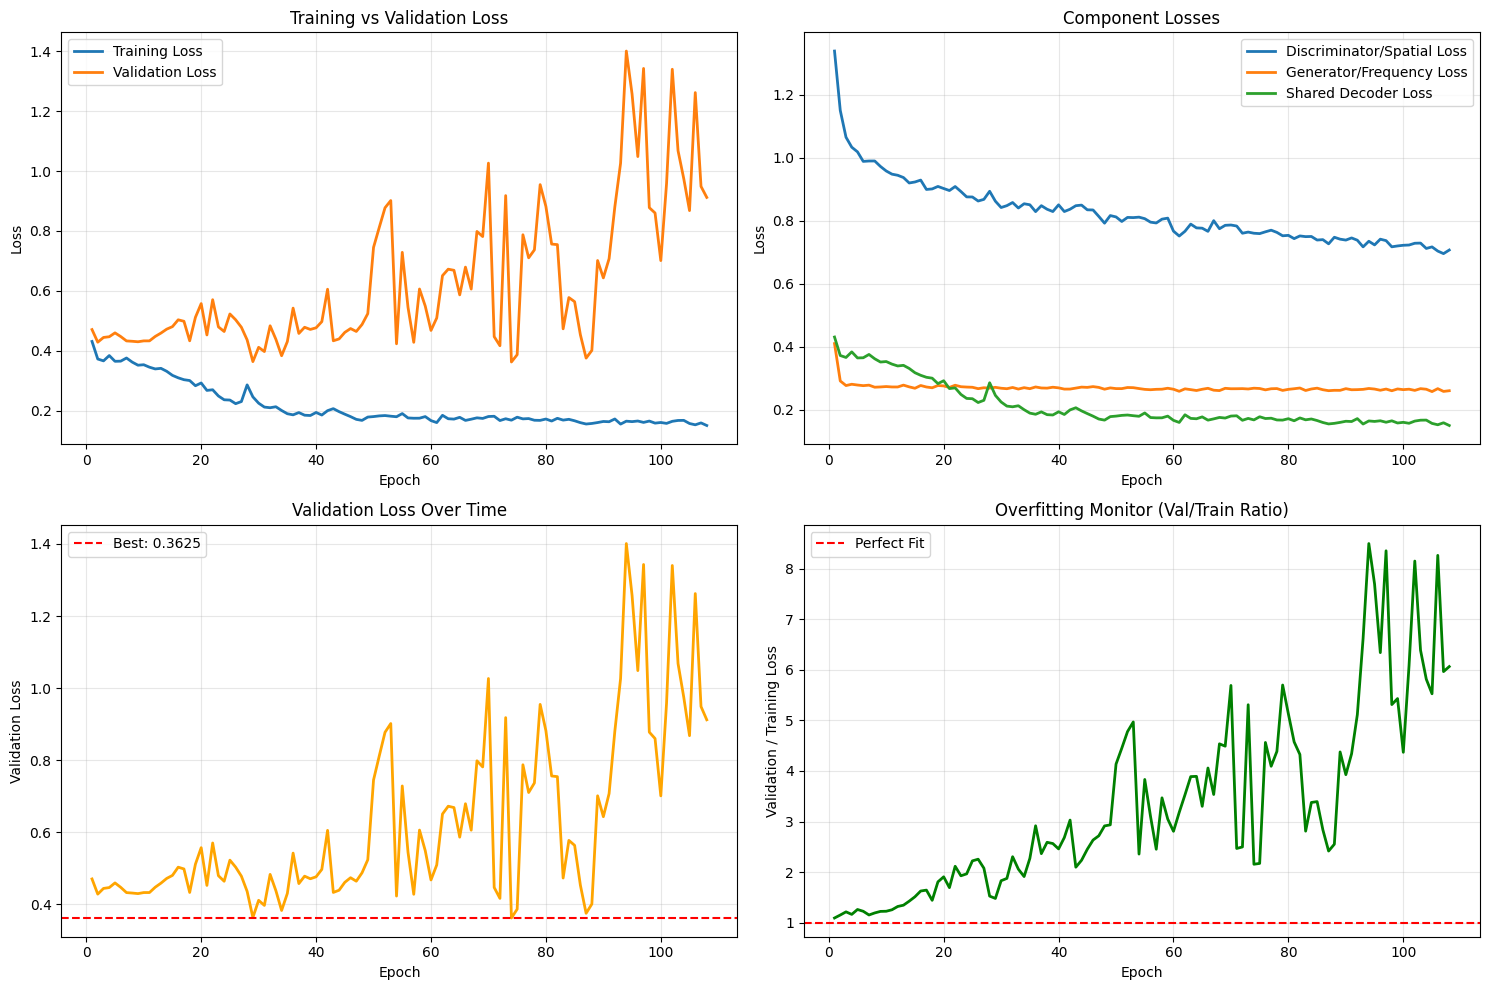


Training history plot saved to: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights/training_history.png
Training history CSV saved to: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights/training_history.csv


In [ ]:
# Plot Training History

import matplotlib.pyplot as plt

print("\n" + "="*60)
print("TRAINING HISTORY VISUALIZATION")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Training vs Validation Loss
axes[0, 0].plot(history['epoch'], history['train_loss'], label='Training Loss', linewidth=2)
axes[0, 0].plot(history['epoch'], history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training vs Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Component Losses
axes[0, 1].plot(history['epoch'], history['train_disc_loss'], label='Discriminator/Spatial Loss', linewidth=2)
axes[0, 1].plot(history['epoch'], history['train_gen_loss'], label='Generator/Frequency Loss', linewidth=2)
axes[0, 1].plot(history['epoch'], history['train_shared_loss'], label='Shared Decoder Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Component Losses')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Validation Loss (zoomed)
axes[1, 0].plot(history['epoch'], history['val_loss'], linewidth=2, color='orange')
axes[1, 0].axhline(y=best_val_loss, color='r', linestyle='--', label=f'Best: {best_val_loss:.4f}')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Validation Loss')
axes[1, 0].set_title('Validation Loss Over Time')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Loss Ratio (Val/Train)
loss_ratio = np.array(history['val_loss']) / (np.array(history['train_loss']) + 1e-8)
axes[1, 1].plot(history['epoch'], loss_ratio, linewidth=2, color='green')
axes[1, 1].axhline(y=1.0, color='r', linestyle='--', label='Perfect Fit')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Validation / Training Loss')
axes[1, 1].set_title('Overfitting Monitor (Val/Train Ratio)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(checkpoint_dir / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTraining history plot saved to: {checkpoint_dir / 'training_history.png'}")

# Save training history to CSV
history_df = pd.DataFrame(history)
history_csv_path = checkpoint_dir / 'training_history.csv'
history_df.to_csv(history_csv_path, index=False)
print(f"Training history CSV saved to: {history_csv_path}")


LOADING BEST MODELS FOR EVALUATION
✓ Best model weights loaded

TEST DATA SUMMARY
  - Number of test samples: 8
  - FFT input shape: (8, 256, 256, 75)
  - Spatial input shape: (8, 256, 256, 75)
  - Ground truth shape: (8, 256, 256, 1)

GENERATING PREDICTIONS
✓ Predictions generated

✓ Test Loss: 0.0121

OPTIMIZING DECISION THRESHOLD

Threshold | Accuracy | Precision | Recall | F1-Score | Kappa
----------------------------------------------------------------------
  0.15    | 0.8336   | 0.2111    | 0.9896  | 0.3479   | 0.2959
  0.20    | 0.8661   | 0.2491    | 0.9859  | 0.3978   | 0.3513
  0.25    | 0.8900   | 0.2869    | 0.9781  | 0.4437   | 0.4022
  0.30    | 0.9102   | 0.3295    | 0.9675  | 0.4916   | 0.4551
  0.35    | 0.9252   | 0.3706    | 0.9560  | 0.5341   | 0.5019
  0.40    | 0.9359   | 0.4073    | 0.9445  | 0.5692   | 0.5404
  0.45    | 0.9436   | 0.4394    | 0.9314  | 0.5971   | 0.5710
  0.50    | 0.9502   | 0.4715    | 0.9167  | 0.6227   | 0.5989
  0.55    | 0.9562   | 0.50

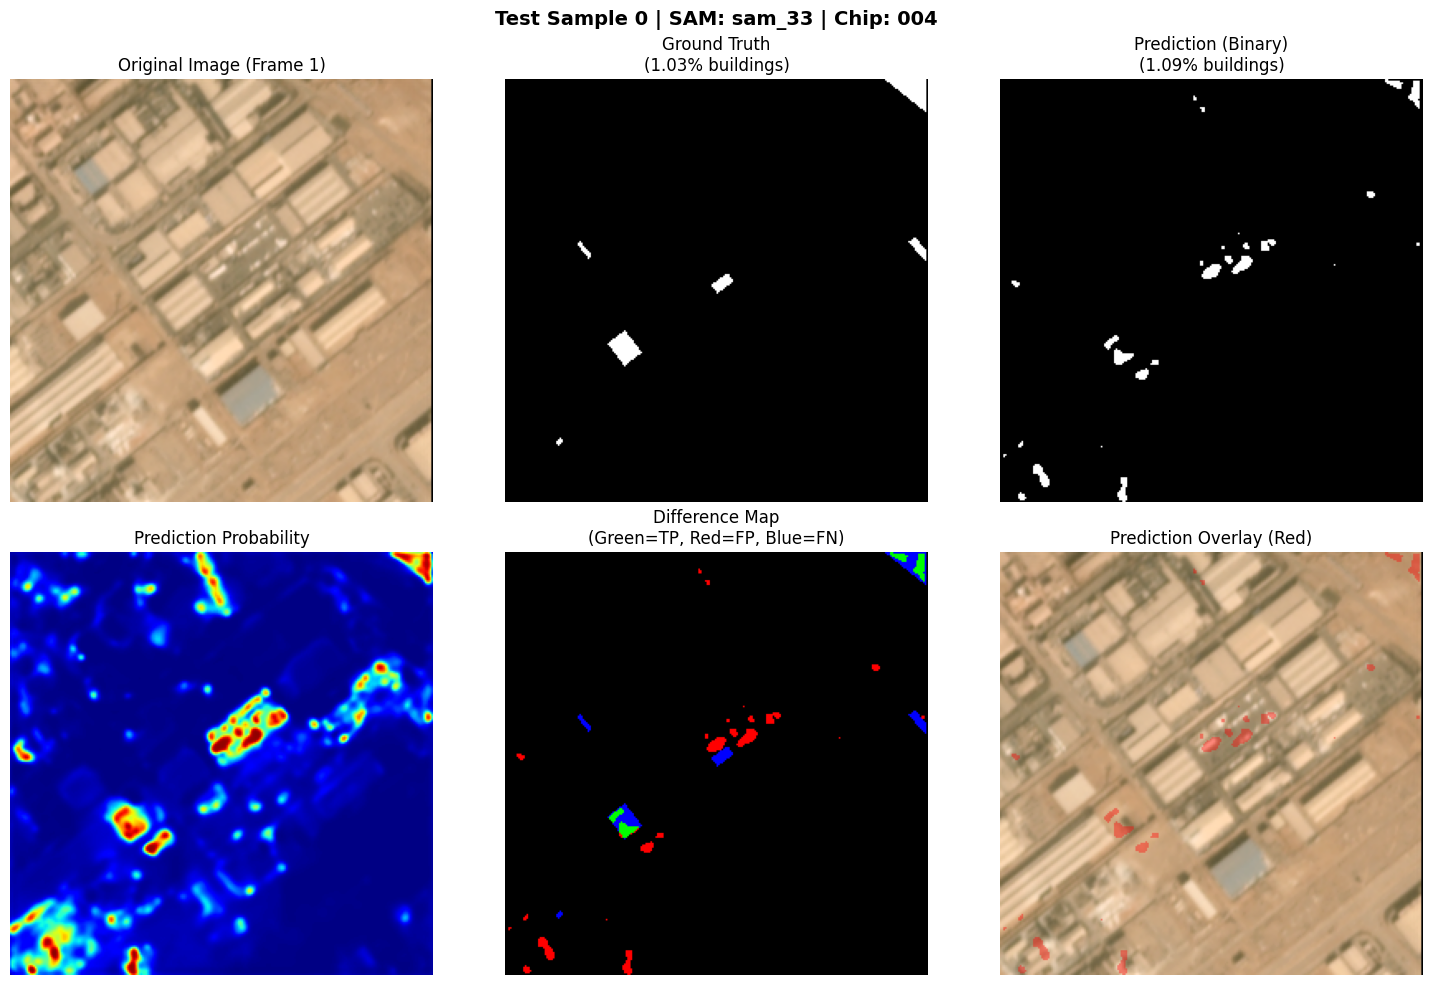

  ✓ Saved: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights/test_prediction_sample_1.png


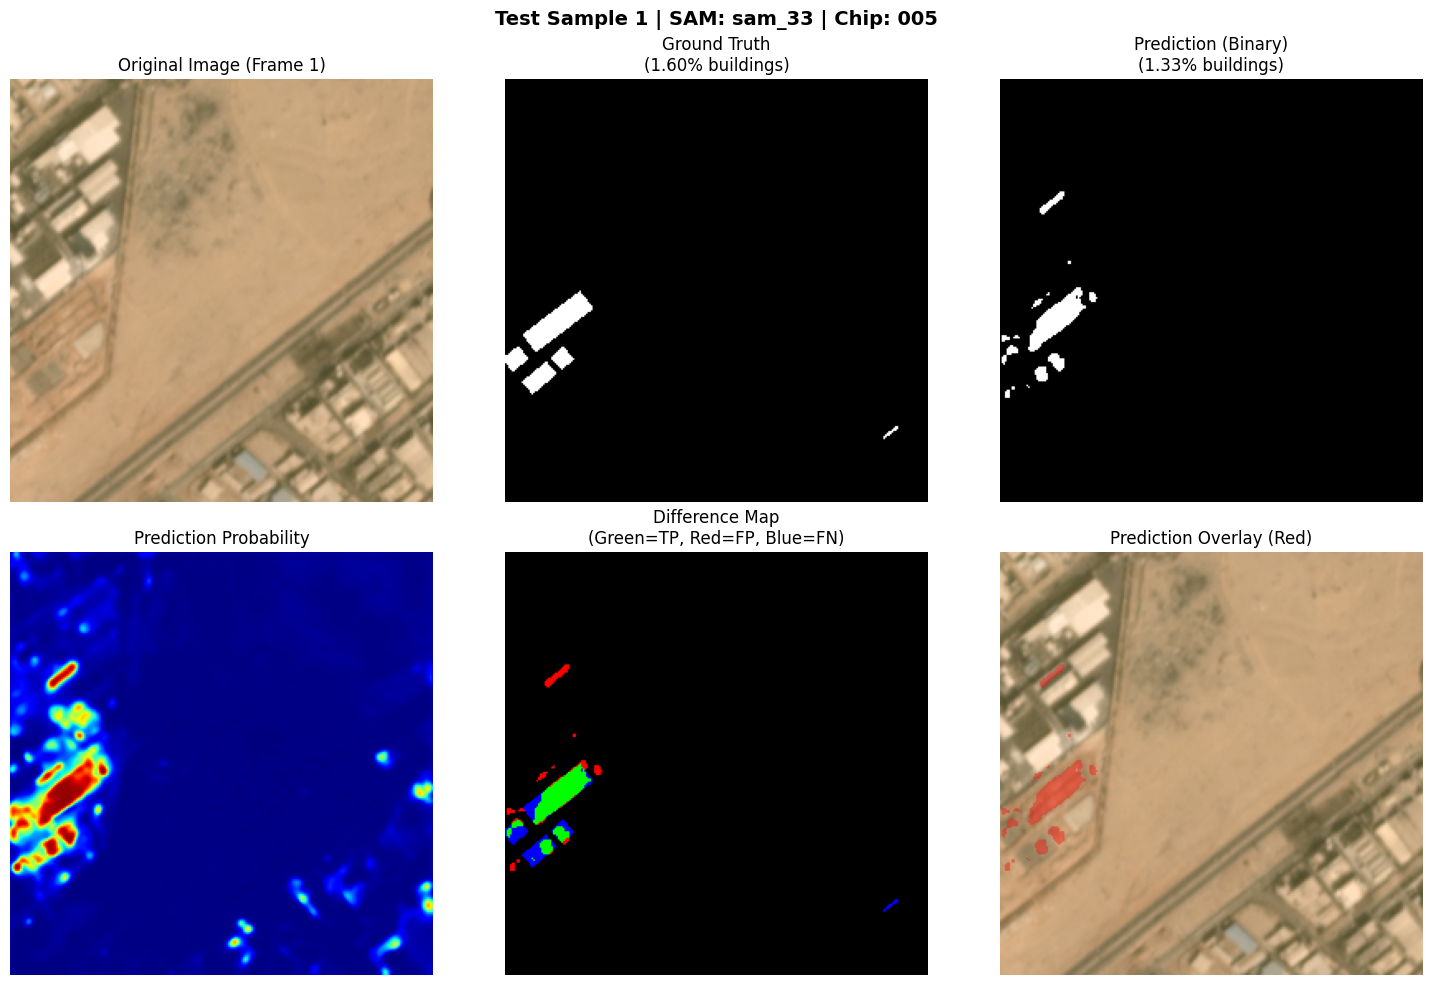

  ✓ Saved: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights/test_prediction_sample_2.png


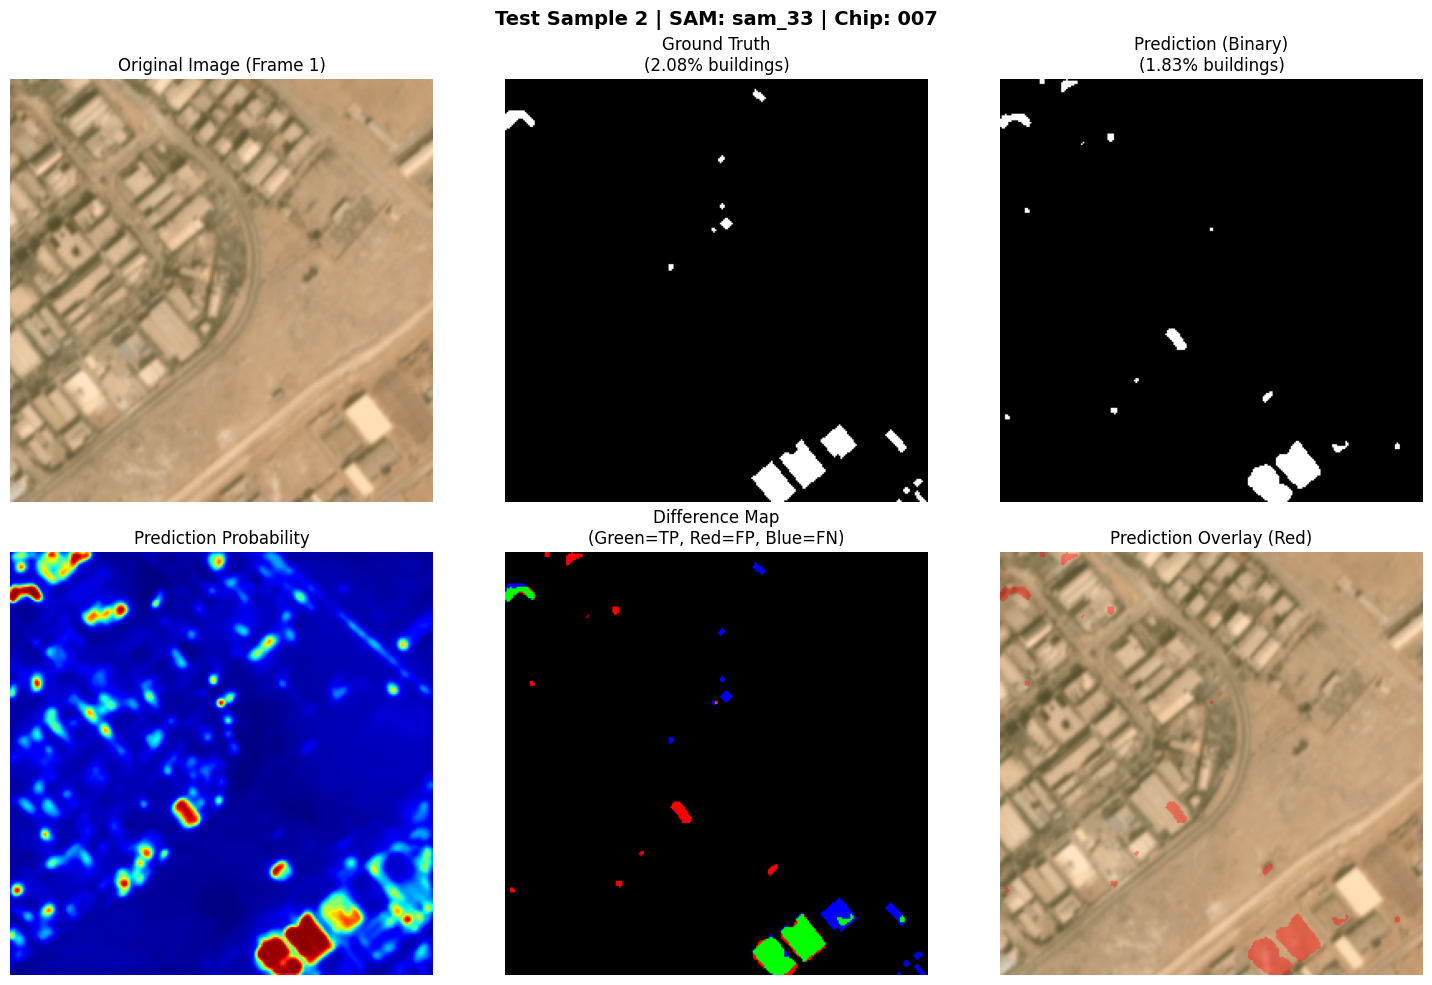

  ✓ Saved: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights/test_prediction_sample_3.png


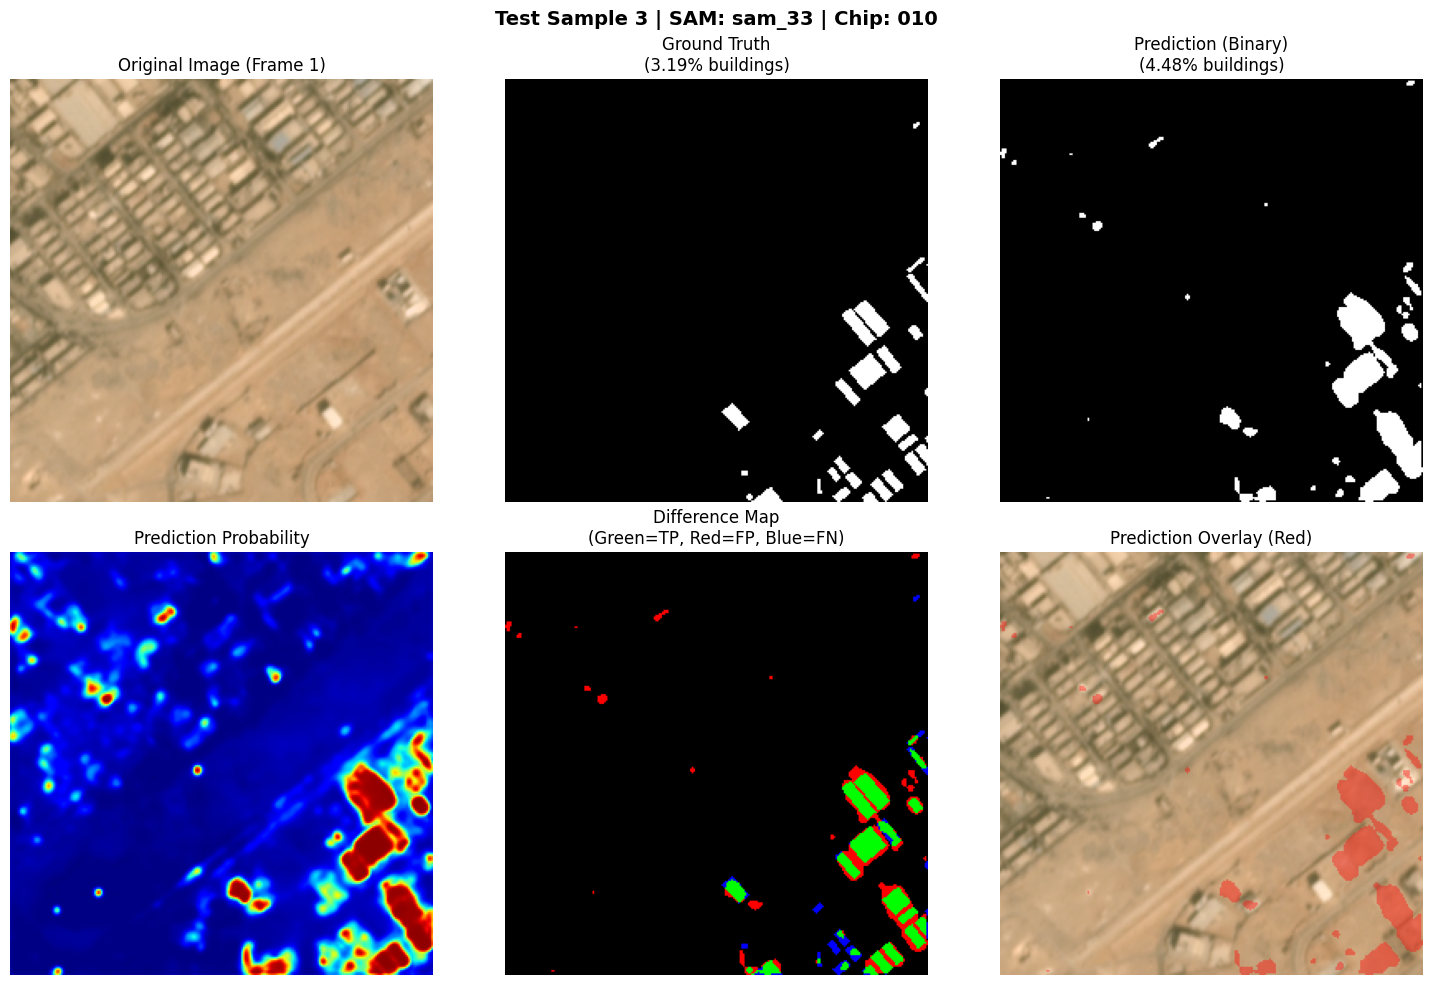

  ✓ Saved: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights/test_prediction_sample_4.png


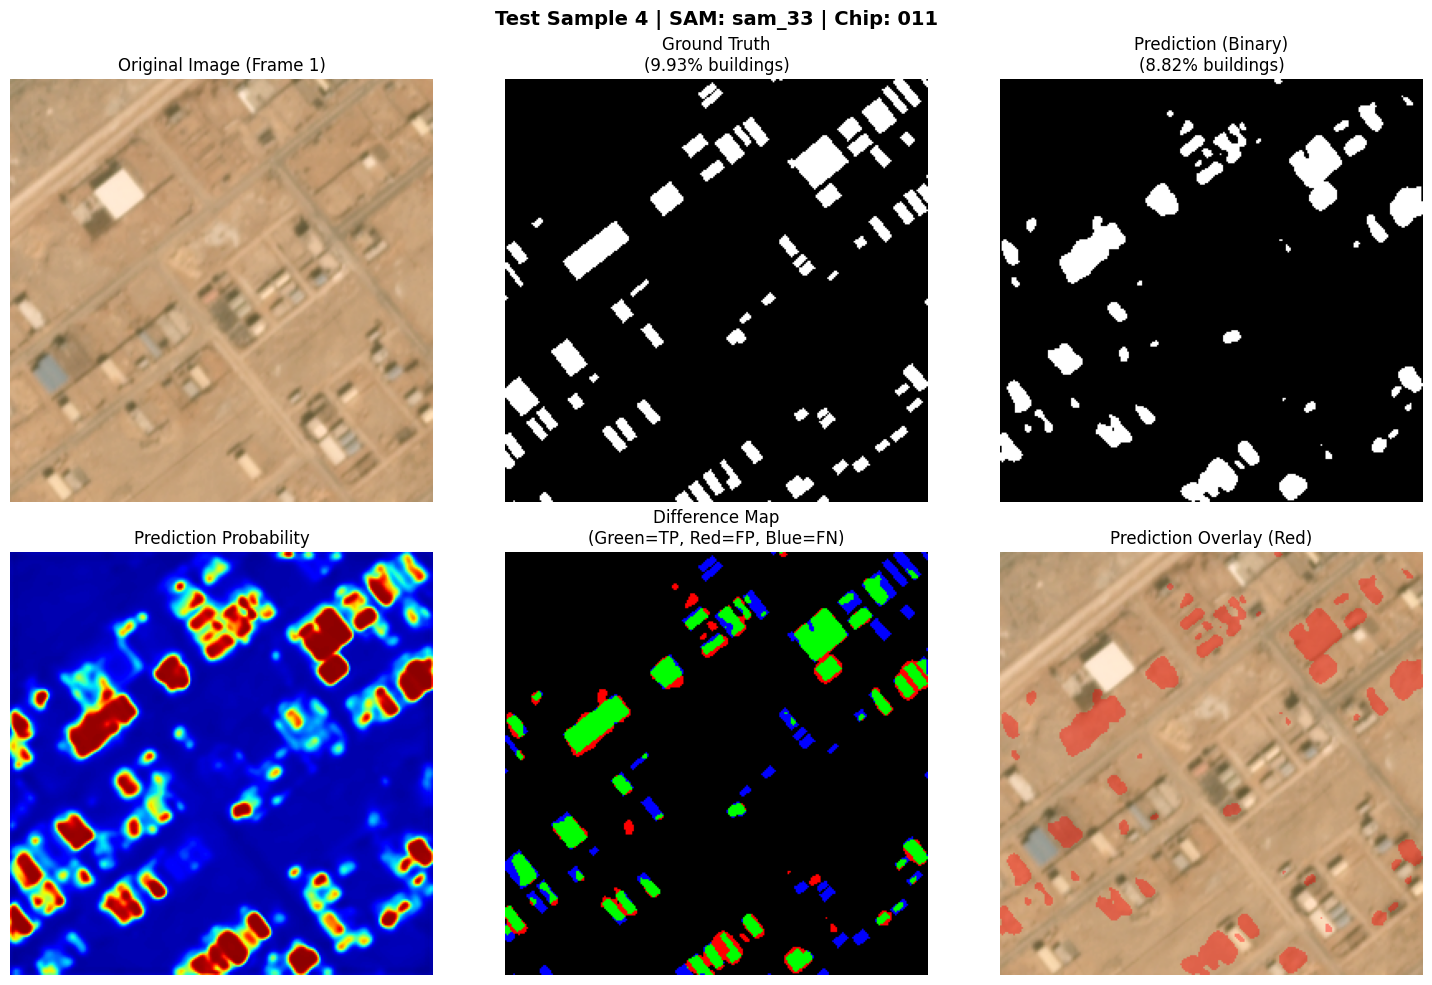

  ✓ Saved: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights/test_prediction_sample_5.png


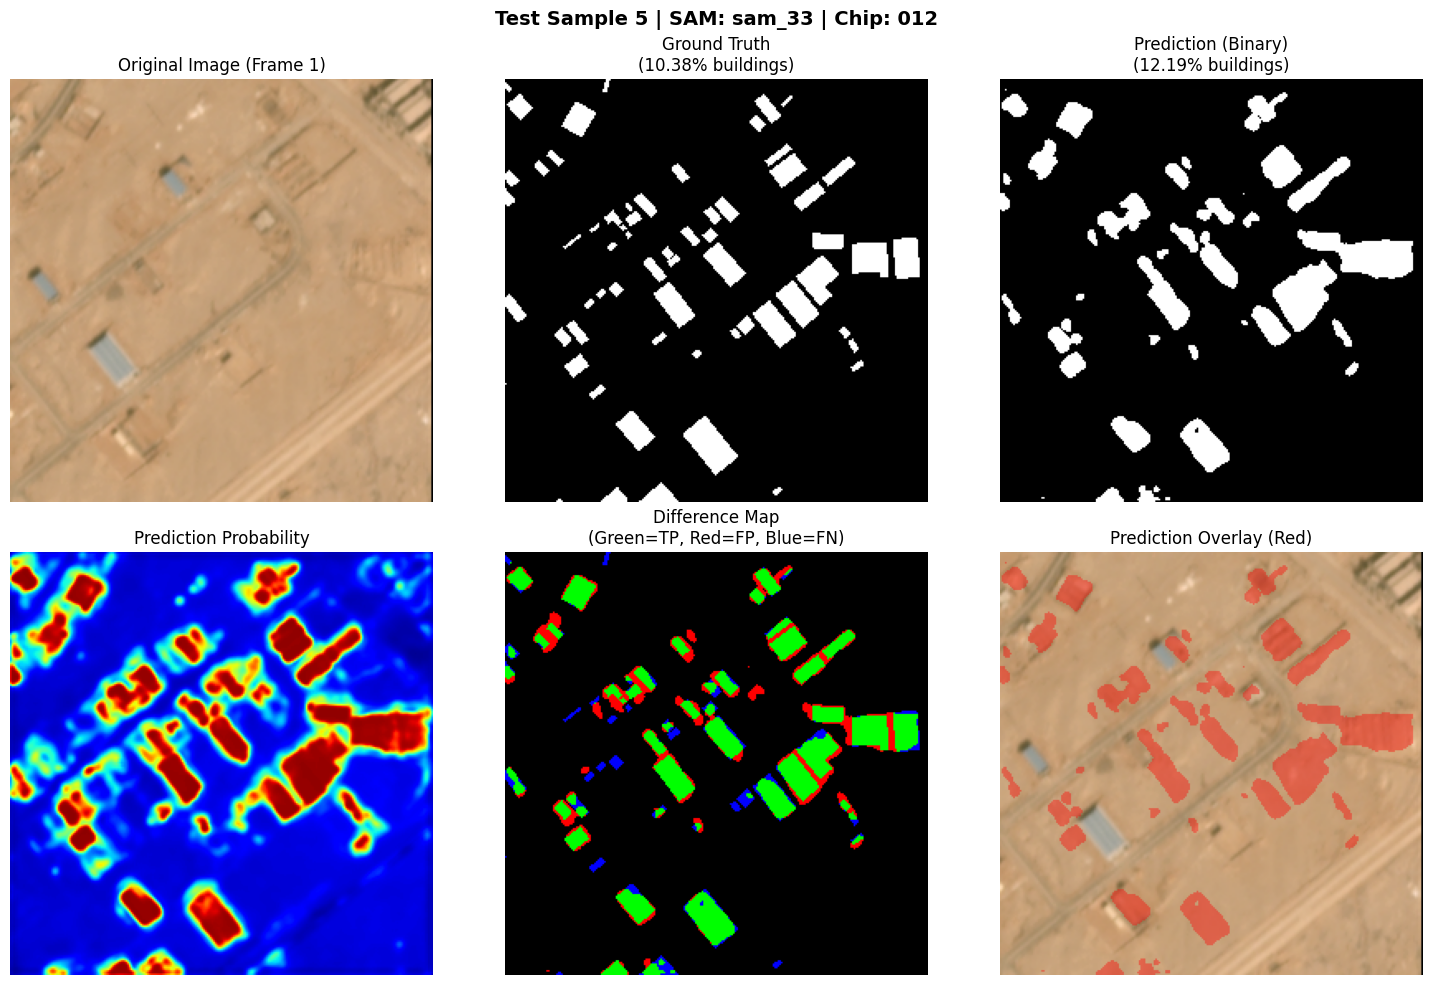

  ✓ Saved: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights/test_prediction_sample_6.png


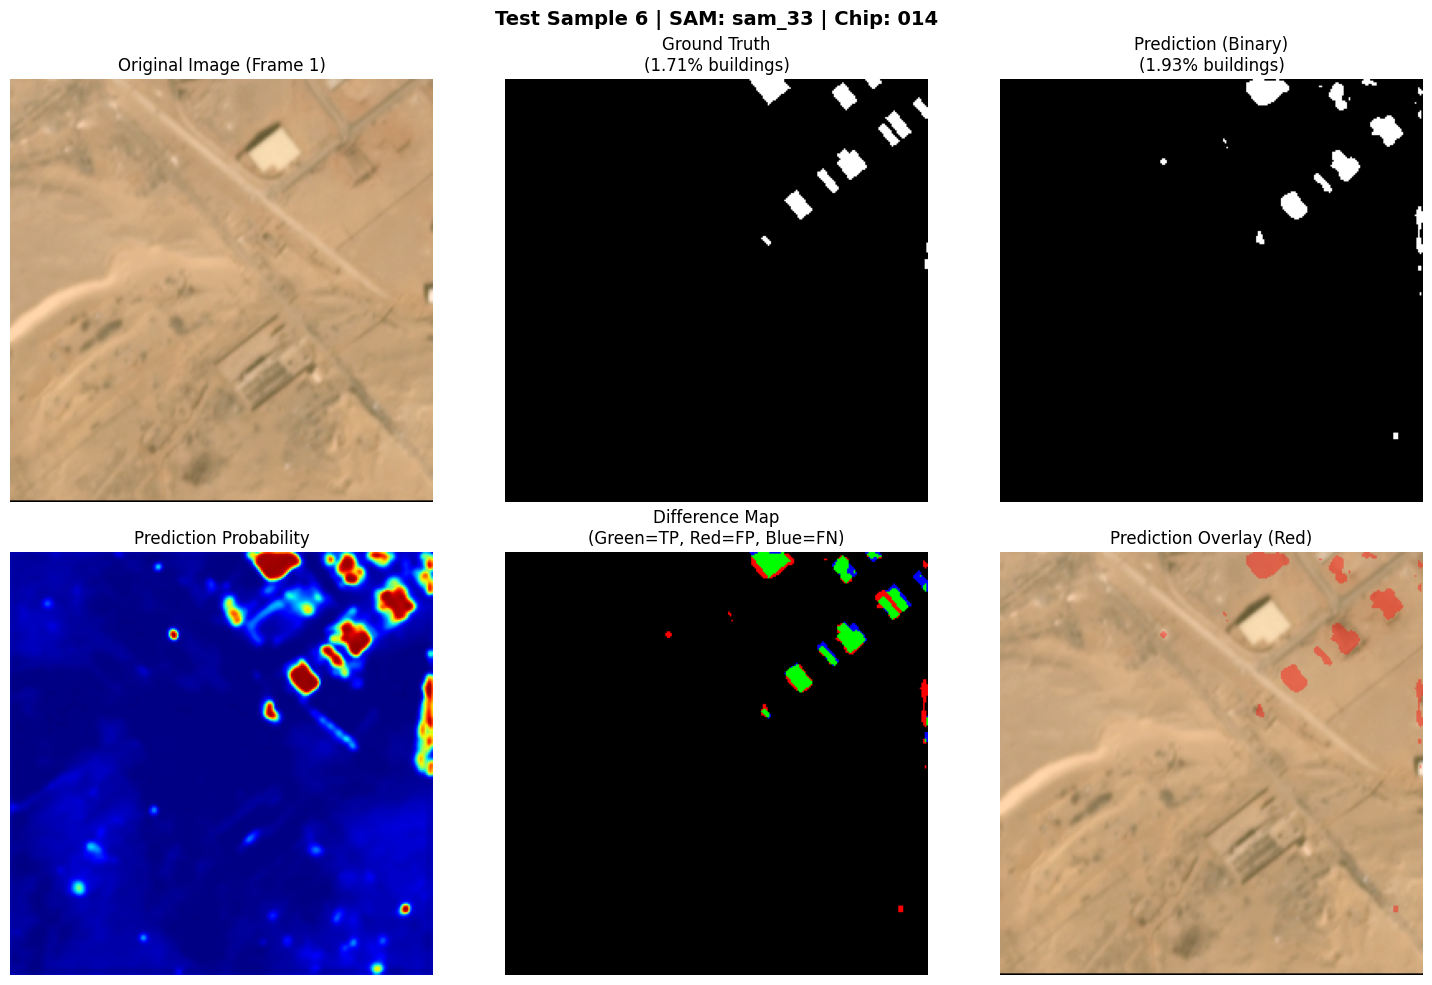

  ✓ Saved: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights/test_prediction_sample_7.png


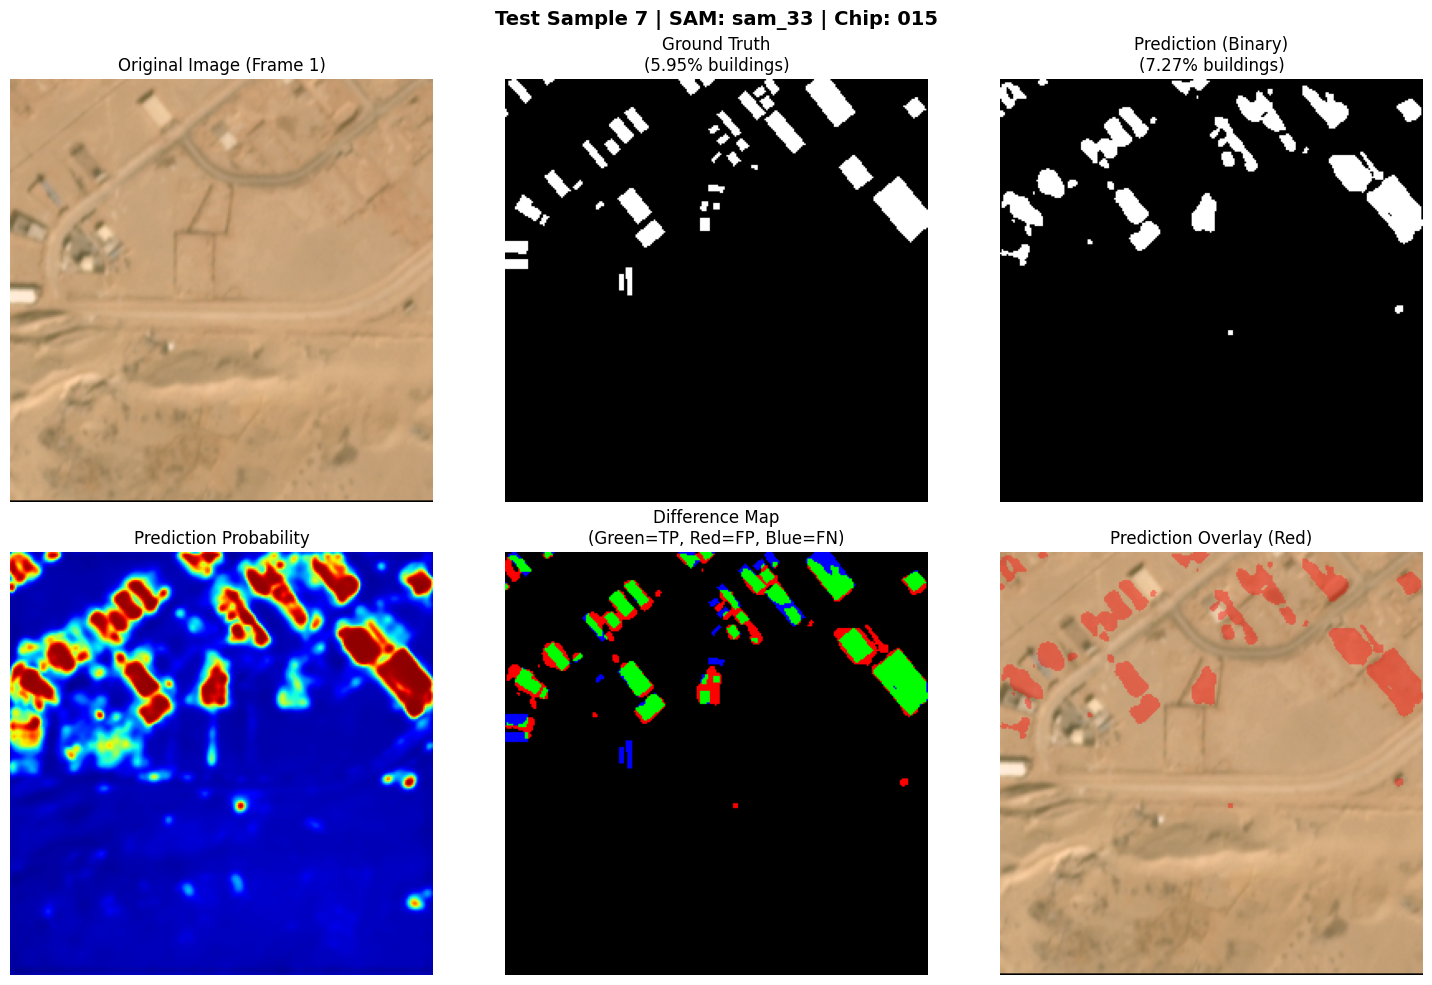


TEST EVALUATION COMPLETE

Results Summary:
  - Test Loss: 0.0121
  - Optimal Threshold: 0.80
  - Best F1-Score: 0.7164
  - Saved results to: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/model/model_weights


In [ ]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    cohen_kappa_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt

# =============================================================================
# LOAD BEST MODELS AND EVALUATE ON TEST SET
# =============================================================================

print("\n" + "="*80)
print("LOADING BEST MODELS FOR EVALUATION")
print("="*80)
checkpoint_dir = base_path / "model_weights"
# Load best model weights
frequency_decoder.load_weights(str(checkpoint_dir / "freq_best.weights.h5"))
spatial_model.load_weights(str(checkpoint_dir / "spat_best.weights.h5"))
shared_decoder.load_weights(str(checkpoint_dir / "share_best.weights.h5"))
discriminator.load_weights(str(checkpoint_dir / "disc_best.weights.h5"))

print("✓ Best model weights loaded")

# =============================================================================
# PREPARE TEST DATA
# =============================================================================

X_test_freq = test_data['sequences_diff_fft']
X_test_spatial = test_data['sequences_diff']
y_test = test_data['ground_truths_expanded']
test_metadata = test_data['metadata']

print("\n" + "="*80)
print("TEST DATA SUMMARY")
print("="*80)
print(f"  - Number of test samples: {len(X_test_freq)}")
print(f"  - FFT input shape: {X_test_freq.shape}")
print(f"  - Spatial input shape: {X_test_spatial.shape}")
print(f"  - Ground truth shape: {y_test.shape}")

# =============================================================================
# GENERATE PREDICTIONS
# =============================================================================

print("\n" + "="*80)
print("GENERATING PREDICTIONS")
print("="*80)

# Forward pass through all models
freq_out_test = frequency_decoder(X_test_freq, training=False)
sp_out_test = spatial_model(X_test_spatial, training=False)
comb_test = tf.concat([freq_out_test, sp_out_test], axis=-1)
final_pred_test = shared_decoder(comb_test, training=False)

print("✓ Predictions generated")

# Calculate test loss
#test_loss = float(weighted_bce(y_test, final_pred_test, w0, w1))
test_loss = float(focal_loss(y_test, final_pred_test))
print(f"\n✓ Test Loss: {test_loss:.4f}")


# =============================================================================
# THRESHOLD OPTIMIZATION
# =============================================================================

print("\n" + "="*80)
print("OPTIMIZING DECISION THRESHOLD")
print("="*80)

# Convert to numpy for processing
y_test_np = y_test.flatten()
y_pred_probs = final_pred_test.numpy().flatten()

# Test multiple thresholds
thresholds = [0.15, 0.20, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85]
threshold_results = []

print("\nThreshold | Accuracy | Precision | Recall | F1-Score | Kappa")
print("-" * 70)

for thresh in thresholds:
    y_pred_binary = (y_pred_probs > thresh).astype(np.float32)

    acc = accuracy_score(y_test_np, y_pred_binary)
    prec = precision_score(y_test_np, y_pred_binary, zero_division=0)
    rec = recall_score(y_test_np, y_pred_binary, zero_division=0)
    f1 = f1_score(y_test_np, y_pred_binary, zero_division=0)
    kappa = cohen_kappa_score(y_test_np, y_pred_binary)

    threshold_results.append({
        'threshold': thresh,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'kappa': kappa
    })

    print(f"  {thresh:.2f}    | {acc:.4f}   | {prec:.4f}    | {rec:.4f}  | {f1:.4f}   | {kappa:.4f}")

# Find optimal threshold based on F1-score
best_result = max(threshold_results, key=lambda x: x['f1'])
optimal_threshold = best_result['threshold']

print(f"\n✓ Optimal threshold (based on F1-score): {optimal_threshold:.2f}")
print(f"  - Accuracy:  {best_result['accuracy']:.4f}")
print(f"  - Precision: {best_result['precision']:.4f}")
print(f"  - Recall:    {best_result['recall']:.4f}")
print(f"  - F1-Score:  {best_result['f1']:.4f}")
print(f"  - Kappa:     {best_result['kappa']:.4f}")

# Use optimal threshold for final predictions
y_pred_binary_optimal = (y_pred_probs > optimal_threshold).astype(np.float32)

# =============================================================================
# OVERALL TEST SET METRICS
# =============================================================================

print("\n" + "="*80)
print("OVERALL TEST SET METRICS (Optimal Threshold)")
print("="*80)

# Compute confusion matrix
cm = confusion_matrix(y_test_np, y_pred_binary_optimal)
tn, fp, fn, tp = cm.ravel()

print(f"\nConfusion Matrix:")
print(f"  True Negatives  (TN): {tn:,}")
print(f"  False Positives (FP): {fp:,}")
print(f"  False Negatives (FN): {fn:,}")
print(f"  True Positives  (TP): {tp:,}")

print(f"\nDerived Metrics:")
print(f"  - Total Pixels: {len(y_test_np):,}")
print(f"  - Building Pixels (Ground Truth): {int(y_test_np.sum()):,} ({100*y_test_np.mean():.2f}%)")
print(f"  - Building Pixels (Predicted): {int(y_pred_binary_optimal.sum()):,} ({100*y_pred_binary_optimal.mean():.2f}%)")
print(f"  - Correctly Classified: {tn + tp:,} ({100*(tn + tp)/len(y_test_np):.2f}%)")
print(f"  - Misclassified: {fp + fn:,} ({100*(fp + fn)/len(y_test_np):.2f}%)")

# Classification report
print(f"\n" + "="*80)
print("CLASSIFICATION REPORT")
print("="*80)
print(classification_report(
    y_test_np,
    y_pred_binary_optimal,
    target_names=['Background', 'Building'],
    digits=4
))

# =============================================================================
# FIX: PER-SAMPLE METRICS (CORRECTED)
# =============================================================================

print("\n" + "="*80)
print("PER-SAMPLE TEST METRICS")
print("="*80)

num_test_samples = len(y_test)
print(f"\nAnalyzing {num_test_samples} test samples...\n")

per_sample_results = []

for i in range(num_test_samples):
    # Extract sample data
    sample_metadata = test_metadata[i]
    chip_num = sample_metadata['chip_number']
    sam_name = sample_metadata['sam_name']

    # Get ground truth and prediction for this sample
    y_true_sample = y_test[i].flatten()
    y_pred_sample = final_pred_test[i].numpy().flatten()
    y_pred_binary_sample = (y_pred_sample > optimal_threshold).astype(np.float32)

    # Calculate metrics
    sample_acc = accuracy_score(y_true_sample, y_pred_binary_sample)
    sample_prec = precision_score(y_true_sample, y_pred_binary_sample, zero_division=0)
    sample_rec = recall_score(y_true_sample, y_pred_binary_sample, zero_division=0)
    sample_f1 = f1_score(y_true_sample, y_pred_binary_sample, zero_division=0)
    sample_kappa = cohen_kappa_score(y_true_sample, y_pred_binary_sample)

    # Store results
    per_sample_results.append({
        'sample_idx': i,
        'sam_name': sam_name,
        'chip_number': chip_num,
        'accuracy': sample_acc,
        'precision': sample_prec,
        'recall': sample_rec,
        'f1': sample_f1,
        'kappa': sample_kappa,
        'building_coverage_gt': float(y_true_sample.mean()),
        'building_coverage_pred': float(y_pred_binary_sample.mean())
    })

    # Print results
    print(f"Sample {i+1}/{num_test_samples} | SAM: {sam_name} | Chip: {chip_num:03d}")
    print(f"  - Accuracy:  {sample_acc:.4f}")
    print(f"  - Precision: {sample_prec:.4f}")
    print(f"  - Recall:    {sample_rec:.4f}")
    print(f"  - F1-Score:  {sample_f1:.4f}")
    print(f"  - Kappa:     {sample_kappa:.4f}")
    print(f"  - Building Coverage (GT):   {100*y_true_sample.mean():.2f}%")
    print(f"  - Building Coverage (Pred): {100*y_pred_binary_sample.mean():.2f}%")
    print()

# =============================================================================
# PER-SAM SUMMARY
# =============================================================================

print("\n" + "="*80)
print("PER-SAM DIRECTORY SUMMARY")
print("="*80)

# Group results by SAM directory
sam_names = set([r['sam_name'] for r in per_sample_results])

for sam in sorted(sam_names):
    sam_results = [r for r in per_sample_results if r['sam_name'] == sam]

    avg_acc = np.mean([r['accuracy'] for r in sam_results])
    avg_prec = np.mean([r['precision'] for r in sam_results])
    avg_rec = np.mean([r['recall'] for r in sam_results])
    avg_f1 = np.mean([r['f1'] for r in sam_results])
    avg_kappa = np.mean([r['kappa'] for r in sam_results])

    print(f"\n{sam}:")
    print(f"  - Number of samples: {len(sam_results)}")
    print(f"  - Average Accuracy:  {avg_acc:.4f}")
    print(f"  - Average Precision: {avg_prec:.4f}")
    print(f"  - Average Recall:    {avg_rec:.4f}")
    print(f"  - Average F1-Score:  {avg_f1:.4f}")
    print(f"  - Average Kappa:     {avg_kappa:.4f}")

# =============================================================================
# SAVE RESULTS TO CSV
# =============================================================================

results_df = pd.DataFrame(per_sample_results)
results_csv_path = checkpoint_dir / 'test_results_per_sample.csv'
results_df.to_csv(results_csv_path, index=False)

print(f"\n✓ Per-sample results saved to: {results_csv_path}")

# =============================================================================
# VISUALIZATION: SAMPLE PREDICTIONS
# =============================================================================

print("\n" + "="*80)
print("VISUALIZING SAMPLE PREDICTIONS")
print("="*80)

def visualize_predictions(sample_idx, save_path=None):
    """Visualize ground truth vs prediction for a sample."""

    # Get data
    sample_metadata = test_metadata[sample_idx]
    gt = y_test[sample_idx].squeeze()
    pred_prob = final_pred_test[sample_idx].numpy().squeeze()
    pred_binary = (pred_prob > optimal_threshold).astype(np.float32)

    # Get original image (first temporal frame)
    orig_img = test_data['sequences_normalized'][sample_idx][:, :, :3]  # First RGB frame
    orig_img_display = (orig_img * 255).astype(np.uint8)
    orig_img_display = cv2.cvtColor(orig_img_display, cv2.COLOR_BGR2RGB)

    # Create figure
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f"Test Sample {sample_idx} | SAM: {sample_metadata['sam_name']} | Chip: {sample_metadata['chip_number']:03d}",
                 fontsize=14, fontweight='bold')

    # Row 1: Original image, Ground truth, Prediction (binary)
    axes[0, 0].imshow(orig_img_display)
    axes[0, 0].set_title("Original Image (Frame 1)")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(gt, cmap='gray')
    axes[0, 1].set_title(f"Ground Truth\n({100*gt.mean():.2f}% buildings)")
    axes[0, 1].axis('off')

    axes[0, 2].imshow(pred_binary, cmap='gray')
    axes[0, 2].set_title(f"Prediction (Binary)\n({100*pred_binary.mean():.2f}% buildings)")
    axes[0, 2].axis('off')

    # Row 2: Prediction probability, Difference map, Overlay
    axes[1, 0].imshow(pred_prob, cmap='jet', vmin=0, vmax=1)
    axes[1, 0].set_title("Prediction Probability")
    axes[1, 0].axis('off')

    # Difference map: green = correct, red = false positive, blue = false negative
    diff_map = np.zeros((*gt.shape, 3))
    diff_map[(gt == 1) & (pred_binary == 1)] = [0, 1, 0]  # True positive (green)
    diff_map[(gt == 0) & (pred_binary == 1)] = [1, 0, 0]  # False positive (red)
    diff_map[(gt == 1) & (pred_binary == 0)] = [0, 0, 1]  # False negative (blue)

    axes[1, 1].imshow(diff_map)
    axes[1, 1].set_title("Difference Map\n(Green=TP, Red=FP, Blue=FN)")
    axes[1, 1].axis('off')

    # Overlay on original image
    overlay = orig_img_display.copy()
    overlay[pred_binary == 1] = [255, 0, 0]  # Red overlay for predicted buildings

    axes[1, 2].imshow(cv2.addWeighted(orig_img_display, 0.6, overlay, 0.4, 0))
    axes[1, 2].set_title("Prediction Overlay (Red)")
    axes[1, 2].axis('off')

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  ✓ Saved: {save_path}")

    plt.show()

# Visualize first 3 test samples
for i in range(min(8, num_test_samples)):
    save_path = checkpoint_dir / f'test_prediction_sample_{i}.png'
    visualize_predictions(i, save_path)

print("\n" + "="*80)
print("TEST EVALUATION COMPLETE")
print("="*80)
print(f"\nResults Summary:")
print(f"  - Test Loss: {test_loss:.4f}")
print(f"  - Optimal Threshold: {optimal_threshold:.2f}")
print(f"  - Best F1-Score: {best_result['f1']:.4f}")
print(f"  - Saved results to: {checkpoint_dir}")

False Negative Analysis:
  - Total FN pixels: 182
  - FN rate: 26.96%
  - Mean confidence in FN regions: 0.245
  - Median confidence in FN regions: 0.269
  - Min confidence in FN regions: 0.000
  - Max confidence in FN regions: 0.498


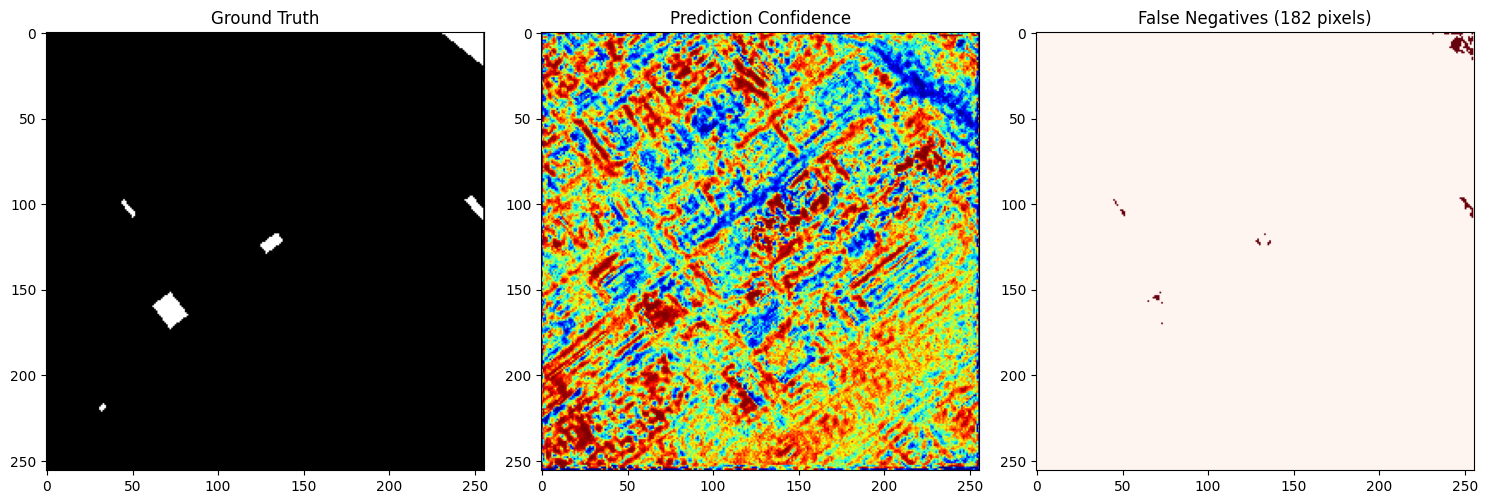

In [ ]:
def analyze_false_negatives(gt, pred, threshold=0.5):
    """Analyze where and why false negatives occur."""
    pred_binary = (pred > threshold).astype(np.uint8)

    # Find false negative regions
    fn_mask = (gt == 1) & (pred_binary == 0)

    # Count FN pixels
    fn_count = np.sum(fn_mask)
    fn_percentage = 100 * fn_count / np.sum(gt == 1)

    # Analyze prediction confidence in FN regions
    fn_confidences = pred[fn_mask]

    print(f"False Negative Analysis:")
    print(f"  - Total FN pixels: {fn_count:,}")
    print(f"  - FN rate: {fn_percentage:.2f}%")
    print(f"  - Mean confidence in FN regions: {fn_confidences.mean():.3f}")
    print(f"  - Median confidence in FN regions: {np.median(fn_confidences):.3f}")
    print(f"  - Min confidence in FN regions: {fn_confidences.min():.3f}")
    print(f"  - Max confidence in FN regions: {fn_confidences.max():.3f}")

    # Visualize
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(gt, cmap='gray')
    axes[0].set_title("Ground Truth")
    axes[1].imshow(pred, cmap='jet', vmin=0, vmax=1)
    axes[1].set_title("Prediction Confidence")
    axes[2].imshow(fn_mask, cmap='Reds')
    axes[2].set_title(f"False Negatives ({fn_count} pixels)")
    plt.tight_layout()
    plt.show()

# Use it:
analyze_false_negatives(
    y_test[0].squeeze(),
    freq_out_test[0].numpy().squeeze(),
    threshold=0.5
)

In [ ]:
import os
import glob
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, cohen_kappa_score

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
#/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/sam_1/chips/raster_chips/
# Define base directories
PROCESSED_TRAIN_BASE = Path("/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data")
RESULTS_DIR = Path("/content/drive/MyDrive/Mdata_lab/Dataset/results_unet_attention_skip/")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Define SAM directories for each split
TRAIN_SAMS = ['sam_52', 'sam_33', 'sam_38', 'sam_44', 'sam_39', 'sam_50', 'sam_45', 'sam_34', 'sam_43',
              'sam_42', 'sam_41', 'sam_40', 'sam_36','sam_13', 'sam_10', 'sam_37', 'sam_35', 'sam_30', 'sam_29',
              'sam_28', 'sam_27', 'sam_26', 'sam_25', 'sam_24']
VAL_SAMS = ['sam_60']
TEST_SAMS = ['sam_33']

# Function to get chip indices for a SAM directory
def get_chip_indices(sam_dir):
    """Get all unique chip indices from diff_chips directory"""
    diff_chips_path = sam_dir / "chips" / "diff_chips"
    if not diff_chips_path.exists():
        return []

    chip_indices = set()
    for diff_file in diff_chips_path.glob("diff_01_*.png"):
        parts = diff_file.stem.split("_")
        if len(parts) >= 3:
            chip_idx = parts[-1]
            chip_indices.add(chip_idx)

    return sorted(chip_indices)

# Function to load sequential images with differencing
def load_sequential_images_for_chip_with_diff(sam_dir, chip_idx, max_timesteps=26, target_size=(256, 256)):
    """Load multi-temporal raster images and compute differences"""
    raster_chips_path = sam_dir / "chips" / "raster_chips"

    images = []
    last_valid_image = None

    # Load images from original01 to original{max_timesteps}
    for t in range(1, max_timesteps + 1):
        image_path = raster_chips_path / f"original{t:02d}_{chip_idx}.tif"

        if image_path.exists():
            image = cv2.imread(str(image_path))
            if image is not None:
                image = cv2.resize(image, target_size)
                image_normalized = image / 255.0
                images.append(image_normalized)
                last_valid_image = image_normalized
            else:
                if last_valid_image is not None:
                    images.append(last_valid_image)
        else:
            if last_valid_image is not None:
                images.append(last_valid_image)

    if len(images) < 2:
        return None

    # Ensure we have exactly max_timesteps images
    while len(images) < max_timesteps:
        if last_valid_image is not None:
            images.append(last_valid_image)
        else:
            break
    return np.array(images)
    ''' # COMPUTE TEMPORAL DIFFERENCES
    diff_images = []
    for i in range(len(images) - 1):
        diff = np.abs(images[i + 1] - images[i])
        # Normalize each difference
        if diff.max() > 0:
            diff = diff / (diff.max() + 1e-7)
        diff_images.append(diff)

    return np.array(diff_images)  # Shape: (timesteps-1, height, width, channels)
    '''
# Function to load ground truth for a specific chip
def load_ground_truth_for_chip(sam_dir, chip_idx, target_size=(256, 256)):
    """Load ground truth diff mask for a specific chip (always diff_01)"""
    diff_chips_path = sam_dir / "chips" / "diff_chips"
    ground_truth_path = diff_chips_path / f"diff_01_{chip_idx}.png"

    if not ground_truth_path.exists():
        raise FileNotFoundError(f"Ground truth not found: {ground_truth_path}")

    ground_truth = cv2.imread(str(ground_truth_path), cv2.IMREAD_GRAYSCALE)
    if ground_truth is None:
        raise ValueError(f"Could not read ground truth: {ground_truth_path}")

    ground_truth = cv2.resize(ground_truth, target_size)
    ground_truth_binary = (ground_truth > 127).astype(np.uint8)

    return ground_truth_binary

# Function to collect dataset (with filtering)
def collect_dataset(sam_list, max_timesteps=26, target_size=(256, 256), min_change_pixels=200):
    """Collect all chips from specified SAM directories, filtering out chips with no/minimal changes"""
    X_data = []
    y_data = []
    metadata = []
    skipped_no_change = 0

    for sam_name in sam_list:
        sam_dir = PROCESSED_TRAIN_BASE / sam_name
        if not sam_dir.exists():
            print(f"Warning: SAM directory not found: {sam_dir}")
            continue

        print(f"Processing {sam_name}...")
        chip_indices = get_chip_indices(sam_dir)
        print(f"  Found {len(chip_indices)} chips")

        for chip_idx in chip_indices:
            try:
                # Load ground truth FIRST to check if it has changes
                ground_truth = load_ground_truth_for_chip(sam_dir, chip_idx, target_size=target_size)

                # Count change pixels
                change_pixel_count = np.sum(ground_truth == 1)

                # Skip if no/minimal changes
                if change_pixel_count < min_change_pixels:
                    skipped_no_change += 1
                    continue

                # Load DIFFERENCE images (only if ground truth has changes)
                diff_images = load_sequential_images_for_chip_with_diff(sam_dir, chip_idx, max_timesteps, target_size)
                if diff_images is None:
                    print(f"  Skipping chip {chip_idx}: insufficient images")
                    continue

                # Concatenate all differences along channel dimension
                combined_diff = np.concatenate(diff_images, axis=-1)  # Shape: (H, W, num_diffs*3)

                X_data.append(combined_diff)
                y_data.append(ground_truth)
                metadata.append({'sam': sam_name, 'chip': chip_idx, 'change_pixels': change_pixel_count})

            except Exception as e:
                print(f"  Error processing {sam_name} chip {chip_idx}: {e}")
                continue

        print(f"  Successfully loaded {len([m for m in metadata if m['sam'] == sam_name])} chips from {sam_name}")

    print(f"\n⚠️  Skipped {skipped_no_change} chips with fewer than {min_change_pixels} change pixels")
    print(f"✅ Kept {len(X_data)} chips with changes")

    return np.array(X_data), np.array(y_data), metadata

In [ ]:
class MultiHeadSelfAttention(layers.Layer):
    def __init__(self, embed_dim, num_heads=4):
        super(MultiHeadSelfAttention, self).__init__()
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim // num_heads)

    def call(self, inputs):
        # inputs shape: (batch, height, width, channels)
        batch_size = tf.shape(inputs)[0]
        height = tf.shape(inputs)[1]
        width = tf.shape(inputs)[2]
        channels = inputs.shape[-1]

        # Reshape to (batch, height*width, channels) for attention
        x = tf.reshape(inputs, [batch_size, height * width, channels])

        # Apply self-attention
        attn_output = self.attention(x, x)

        # Reshape back to (batch, height, width, channels)
        attn_output = tf.reshape(attn_output, [batch_size, height, width, channels])

        return attn_output

# Encoder Block
def encoder_block(inputs, num_filters, dropout_rate, l2_reg):
    x = layers.Conv2D(num_filters, 3, padding='same', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(inputs)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(num_filters, 3, padding='same', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    # Store before pooling for skip connection
    skip = x
    x = layers.MaxPooling2D((2, 2))(x)
    return x, skip

# Decoder Block with Attention
def decoder_block(inputs, skip_features, num_filters, dropout_rate):
    x = layers.Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)

    # Removed tf.image.resize as shapes match with padding='same'
    # skip_features = tf.image.resize(skip_features, (tf.shape(x)[1], tf.shape(x)[2]))

    x = layers.Concatenate()([x, skip_features])

    # Apply Multi-Head Self-Attention
    attn = MultiHeadSelfAttention(embed_dim=num_filters, num_heads=4)(x)
    x = layers.Add()([x, attn])  # Residual connection

    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(num_filters, 3, padding='same')(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

# U-Net Model with Attention
def unet_model(input_shape=(256, 256, 75), num_classes=1, dropout_rate=0.1, l2_reg=0.0001):
    inputs = layers.Input(input_shape)

    # Encoder path
    e1, s1 = encoder_block(inputs, 64, dropout_rate, l2_reg)
    e2, s2 = encoder_block(e1, 128, dropout_rate, l2_reg)
    e3, s3 = encoder_block(e2, 256, dropout_rate, l2_reg)
    e4, s4 = encoder_block(e3, 512, dropout_rate, l2_reg)

    # Bottleneck with Attention
    b1 = layers.Conv2D(1024, 3, padding='same', kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(e4)
    b1 = layers.Activation('relu')(b1)
    b1 = layers.Dropout(dropout_rate)(b1)

    attn_bottleneck = MultiHeadSelfAttention(embed_dim=1024, num_heads=8)(b1)
    b1 = layers.Add()([b1, attn_bottleneck])  # Residual connection

    # Decoder path with Attention
    d1 = decoder_block(b1, s4, 512, dropout_rate)
    d2 = decoder_block(d1, s3, 256, dropout_rate)
    d3 = decoder_block(d2, s2, 128, dropout_rate)
    d4 = decoder_block(d3, s1, 64, dropout_rate)

    # Output layer
    outputs = layers.Conv2D(num_classes, 1, padding='same', activation='sigmoid')(d4)

    model = models.Model(inputs, outputs, name='U-Net-Attn')
    return model

# Instantiate Model
#model = unet_model(input_shape=(256, 256, 75), num_classes=1)


In [ ]:
# Calculate class weights
total_pixels = np.prod(y_train.shape)
change_count = np.sum(y_train == 1)
unchanged_count = total_pixels - change_count

weight_for_changed = (1 / change_count) * (total_pixels / 2.0)
weight_for_unchanged = (1 / unchanged_count) * (total_pixels / 2.0)

print("\n" + "=" * 80)
print("CLASS DISTRIBUTION")
print("=" * 80)
print(f"Total pixels: {total_pixels:,}")
print(f"Changed pixels: {change_count:,} ({100*change_count/total_pixels:.2f}%)")
print(f"Unchanged pixels: {unchanged_count:,} ({100*unchanged_count/total_pixels:.2f}%)")
print(f"Weight for changed: {weight_for_changed:.4f}")
print(f"Weight for unchanged: {weight_for_unchanged:.4f}")

# Define weighted loss function (per-batch weighting)
# Define weighted loss function (per-batch weighting)
def weighted_bce_loss(y_true, y_pred):
    """Weighted Binary Cross-Entropy Loss - calculates weights per batch"""
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    # Calculate class counts for this batch
    total_pixels = tf.cast(tf.reduce_prod(tf.shape(y_true)), tf.float32)
    change_count = tf.reduce_sum(y_true)
    unchanged_count = total_pixels - change_count

    # Calculate weights for this batch (avoid division by zero)
    weight_changed = tf.cond(
        change_count > 0,
        lambda: total_pixels / (2.0 * change_count),
        lambda: 1.0
    )
    weight_unchanged = tf.cond(
        unchanged_count > 0,
        lambda: total_pixels / (2.0 * unchanged_count),
        lambda: 1.0
    )

    # Apply weights
    weights = tf.where(tf.equal(y_true, 1), weight_changed, weight_unchanged)

    # Compute BCE - use from_logits=False since we have sigmoid output
    bce = tf.keras.backend.binary_crossentropy(y_true, y_pred)

    # Ensure shapes match before multiplication
    weighted_loss = bce * weights

    return tf.reduce_mean(weighted_loss)

# Initialize model
input_channels = X_train.shape[-1]  # Should be 75 (25 differences * 3 channels)
model = unet_model(input_shape=(256, 256, input_channels), num_classes=1, dropout_rate=0.2, l2_reg=0.0001)

# Learning rate schedule
initial_lr = 0.001
lr_schedule = ExponentialDecay(initial_learning_rate=initial_lr, decay_steps=1000, decay_rate=0.8, staircase=False)

# Compile model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss=weighted_bce_loss,
    metrics=['accuracy',
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)

model.summary()


CLASS DISTRIBUTION
Total pixels: 12,320,768
Changed pixels: 217,607 (1.77%)
Unchanged pixels: 12,103,161 (98.23%)
Weight for changed: 28.3097
Weight for unchanged: 0.5090


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.ops`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [ ]:
# Train the model
print("\n" + "=" * 80)
print("TRAINING U-NET MODEL")
print("=" * 80)

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=8,
    callbacks=[early_stopping],
    verbose=1
)

# Plot training history
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
if 'precision' in history.history:
    plt.plot(history.history['precision'], label='Train Precision')
    plt.plot(history.history['recall'], label='Train Recall')
    plt.plot(history.history['val_precision'], label='Val Precision')
    plt.plot(history.history['val_recall'], label='Val Recall')
    plt.xlabel('Epoch')
    plt.ylabel('Score')
    plt.legend()
    plt.title('Precision and Recall')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_history.png", dpi=500)
plt.show()

print("\n✅ Training completed!")

In [ ]:
# Evaluate on test set
print("\n" + "=" * 80)
print("EVALUATING ON TEST SET")
print("=" * 80)

# Define thresholds to test
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
threshold_metrics = {thresh: [] for thresh in thresholds}

for idx in range(len(X_test)):
    meta = test_metadata[idx]
    sam_name = meta['sam']
    chip_idx = meta['chip']

    # Predict
    y_pred_prob = model.predict(np.expand_dims(X_test[idx], axis=0), verbose=0)[0].squeeze()
    y_true = y_test[idx].squeeze()

    # Save probability map
    prob_save_path = RESULTS_DIR / f"{sam_name}_chip{chip_idx}_probability.png"
    cv2.imwrite(str(prob_save_path), (y_pred_prob * 255).astype(np.uint8))

    true_flat = y_true.flatten()

    # Evaluate for each threshold
    for threshold in thresholds:
        y_pred = (y_pred_prob > threshold).astype(np.uint8)
        pred_flat = y_pred.flatten()

        precision = precision_score(true_flat, pred_flat, zero_division=0)
        recall = recall_score(true_flat, pred_flat, zero_division=0)
        f1 = f1_score(true_flat, pred_flat, zero_division=0)
        accuracy = accuracy_score(true_flat, pred_flat)
        kappa = cohen_kappa_score(true_flat, pred_flat)

        intersection = np.logical_and(true_flat, pred_flat).sum()
        union = np.logical_or(true_flat, pred_flat).sum()
        iou = intersection / union if union > 0 else 0

        threshold_metrics[threshold].append({
            'sam': sam_name,
            'chip': chip_idx,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'accuracy': accuracy,
            'kappa': kappa,
            'iou': iou
        })

        # Save prediction for this threshold
        prediction_save_path = RESULTS_DIR / f"{sam_name}_chip{chip_idx}_prediction_thresh{threshold:.2f}.png"
        cv2.imwrite(str(prediction_save_path), (y_pred * 255))

    print(f"✅ Processed {sam_name} chip {chip_idx}")

# Calculate and display aggregate metrics
print("\n📊 Results by Threshold:")
print("-" * 80)
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy':<12} {'Kappa':<12} {'IoU':<12}")
print("-" * 80)

best_threshold = None
best_f1 = 0

for threshold in thresholds:
    metrics_list = threshold_metrics[threshold]

    avg_metrics = {
        'precision': np.mean([m['precision'] for m in metrics_list]),
        'recall': np.mean([m['recall'] for m in metrics_list]),
        'f1': np.mean([m['f1'] for m in metrics_list]),
        'accuracy': np.mean([m['accuracy'] for m in metrics_list]),
        'kappa': np.mean([m['kappa'] for m in metrics_list]),
        'iou': np.mean([m['iou'] for m in metrics_list])
    }

    if avg_metrics['f1'] > best_f1:
        best_f1 = avg_metrics['f1']
        best_threshold = threshold

    print(f"{threshold:<12.2f} {avg_metrics['precision']:<12.4f} {avg_metrics['recall']:<12.4f} "
          f"{avg_metrics['f1']:<12.4f} {avg_metrics['accuracy']:<12.4f} "
          f"{avg_metrics['kappa']:<12.4f} {avg_metrics['iou']:<12.4f}")

print("-" * 80)
print(f"\n🎯 Best Threshold: {best_threshold:.2f} (F1 Score: {best_f1:.4f})")

# Save model
model.save(RESULTS_DIR / "unet_model.h5")
print(f"\n✅ Model saved to {RESULTS_DIR / 'unet_model.h5'}")
print(f"🎉 Evaluation completed!")

UTRNet


In [ ]:
import os
import numpy as np
import tensorflow as tf
import cv2
from pathlib import Path
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import layers, models
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, cohen_kappa_score
import matplotlib.pyplot as plt

# Set random seeds
tf.random.set_seed(42)
np.random.seed(42)

# Define base directories
PROCESSED_TRAIN_BASE = Path("/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data")
RESULTS_DIR = Path("/content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/results_utrnet/")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Define SAM directories
TRAIN_SAMS = ['sam_52', 'sam_33', 'sam_38', 'sam_44', 'sam_39', 'sam_50', 'sam_45', 'sam_34', 'sam_43',
              'sam_42', 'sam_41', 'sam_40', 'sam_36','sam_13', 'sam_10', 'sam_37', 'sam_35', 'sam_30', 'sam_29',
              'sam_28', 'sam_27', 'sam_26', 'sam_25', 'sam_24']
VAL_SAMS = ['sam_60']
TEST_SAMS = ['sam_33']

# Hyperparameters
PATCH_SIZE = 9
N_TIMESTEPS = 26
N_CHANNELS = 3
MIN_CHANGE_PIXELS = 200
TARGET_SIZE = (256, 256)
DAYS_BETWEEN_IMAGES = 30

In [ ]:
class TLSTMCell(layers.Layer):
    """
    Time-distance-guided LSTM cell implementing temporal gates with seasonal patterns.
    T_t = β0 + β1*cos(2π*dt/365) + β2*sin(2π*dt/365) - β3*dt
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.units = units

        # Move Dense layer definitions to __init__ for proper weight tracking
        self.dense_i = layers.Dense(self.units, use_bias=True, name="dense_input_gate")
        self.dense_f = layers.Dense(self.units, use_bias=True, name="dense_forget_gate")
        self.dense_c = layers.Dense(self.units, use_bias=True, name="dense_candidate")
        self.dense_o = layers.Dense(self.units, use_bias=True, name="dense_output_gate")

    @property
    def state_size(self):
        return [self.units, self.units]  # [cell_state, hidden_state]

    @property
    def output_size(self):
        return self.units

    def build(self, input_shape):
        # Time-gate parameters (learnable seasonal patterns)
        self.beta0 = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True, name="beta0")
        self.beta1 = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True, name="beta1")
        self.beta2 = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True, name="beta2")
        self.beta3_raw = self.add_weight(shape=(self.units,), initializer="zeros", trainable=True, name="beta3_raw")

        super().build(input_shape)

    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units,
        })
        return config

    def time_gate(self, dt):
        """
        Compute time-modulated gate: T_t = β0 + β1*cos() + β2*sin() - β3*dt
        dt: (batch, 1) - time distance in days
        Returns: (batch, units) - time gate values
        """
        dt = tf.cast(dt, tf.float32)
        two_pi = tf.constant(2.0 * np.pi, dtype=tf.float32)

        # Seasonal terms
        cos_term = tf.cos(two_pi * dt / 365.0)  # (batch, 1)
        sin_term = tf.sin(two_pi * dt / 365.0)  # (batch, 1)

        # Ensure β3 is positive (decay term)
        beta3 = tf.nn.softplus(self.beta3_raw)

        # Expand dimensions for broadcasting
        cos_term = tf.expand_dims(cos_term, -1)  # (batch, 1, 1)
        sin_term = tf.expand_dims(sin_term, -1)  # (batch, 1, 1)
        dt_exp = tf.expand_dims(dt, -1)          # (batch, 1, 1)

        # Reshape betas for broadcasting
        beta0 = tf.reshape(self.beta0, (1, 1, -1))  # (1, 1, units)
        beta1 = tf.reshape(self.beta1, (1, 1, -1))
        beta2 = tf.reshape(self.beta2, (1, 1, -1))
        beta3 = tf.reshape(beta3, (1, 1, -1))

        # Compute time gate
        T = beta0 + beta1 * cos_term + beta2 * sin_term - beta3 * dt_exp
        T = tf.squeeze(T, axis=1)  # (batch, units)

        return T

    def call(self, inputs, states):
        """
        inputs: (batch, feature_dim + 2) where last 2 are dt_t, dt_prev
        states: [c_prev, h_prev]
        """
        c_prev, h_prev = states

        # Split features and time distances
        x = inputs[:, :-2]  # (batch, feature_dim)
        dt_t = tf.expand_dims(inputs[:, -2], axis=-1)      # (batch, 1)
        dt_prev = tf.expand_dims(inputs[:, -1], axis=-1)   # (batch, 1)

        # Compute time gates
        T_t = self.time_gate(dt_t)          # (batch, units)
        T_prev = self.time_gate(dt_prev)    # (batch, units)

        # Input and forget gates (concatenate c, h, x as in paper)
        concat_if = tf.concat([c_prev, h_prev, x], axis=-1)
        i = tf.sigmoid(self.dense_i(concat_if))
        f = tf.sigmoid(self.dense_f(concat_if))

        # Apply time modulation
        i = T_t * i       # Time-modulated input gate
        f = T_prev * f    # Time-modulated forget gate

        # Candidate cell state
        concat_cand = tf.concat([h_prev, x], axis=-1)
        c_tilde = tf.tanh(self.dense_c(concat_cand))

        # New cell state
        c = f * c_prev + i * c_tilde

        # Output gate
        concat_o = tf.concat([c, h_prev, x], axis=-1)
        o = tf.sigmoid(self.dense_o(concat_o))
        h = o * tf.tanh(c)

        return h, [c, h]

def build_tlstm_layer(units=64, return_sequences=False, name="tlstm"):
    """Wrap TLSTMCell in RNN layer"""
    cell = TLSTMCell(units)
    return layers.RNN(cell, return_sequences=return_sequences, name=name)

In [ ]:
def build_patch_cnn(patch_size=5, n_channels=3, dropout_rate=0.2, name="patch_cnn"):
    """
    SIMPLIFIED CNN for 5×5 patches (3-4 layers max)
    12 layers was causing complete gradient collapse!
    """
    inputs = layers.Input(shape=(patch_size, patch_size, n_channels), name=f"{name}_input")

    # Layer 1: Initial feature extraction
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name=f"{name}_conv1")(inputs)
    x = layers.BatchNormalization(name=f"{name}_bn1")(x)  # Add batch norm!
    # Shape: (5, 5, 32)

    # Layer 2: Deeper features
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu',
                      kernel_initializer='he_normal', name=f"{name}_conv2")(x)
    x = layers.BatchNormalization(name=f"{name}_bn2")(x)
    # Shape: (5, 5, 64)

    # Layer 3: Spatial reduction (valid padding reduces to 3×3)
    x = layers.Conv2D(64, (3, 3), padding='valid', activation='relu',
                      kernel_initializer='he_normal', name=f"{name}_conv3")(x)
    x = layers.BatchNormalization(name=f"{name}_bn3")(x)
    # Shape: (3, 3, 64)

    # Global pooling (better than flatten for small spatial dims)
    x = layers.GlobalAveragePooling2D(name=f"{name}_gap")(x)  # (64,)

    # Dropout and output
    x = layers.Dropout(dropout_rate, name=f"{name}_dropout")(x)

    return models.Model(inputs, x, name=name)

In [ ]:
def build_utrnet(
    n_timesteps=26,
    patch_size=5,
    n_channels=3,
    tlstm_units=64,
    fc_units=(64, 32),
    dropout_rate=0.2,
):
    """
    Complete UTRNet architecture:
    1. Input: Multi-temporal image patches + time distances
    2. CNN: Extract spectral-spatial features per timestep
    3. TLSTM: Model temporal dependencies with time-distance guidance
    4. FC layers: Classification head
    5. Output: Change probability

    Args:
        n_timesteps: Number of temporal observations (26 for SpaceNet 7)
        patch_size: Spatial size of patch (5×5)
        n_channels: Number of spectral channels (3 for RGB)
        tlstm_units: Hidden units in TLSTM
        fc_units: Tuple of FC layer sizes
        dropout_rate: Dropout rate

    Returns:
        Keras Model with inputs [images, time_distances] and output [change_prob]
    """
    # ===== INPUTS =====
    images_in = layers.Input(
        shape=(n_timesteps, patch_size, patch_size, n_channels),
        name="images"
    )  # (batch, T, H, W, C)

    dt_in = layers.Input(
        shape=(n_timesteps, 1),
        name="time_distances"
    )  # (batch, T, 1)

    # ===== CNN FEATURE EXTRACTION (Per-Timestep, Shared Weights) =====
    patch_cnn = build_patch_cnn(
        patch_size=patch_size,
        n_channels=n_channels,
        dropout_rate=dropout_rate,
        name="shared_patch_cnn"
    )

    # Apply CNN to each timestep independently (TimeDistributed)
    features = layers.TimeDistributed(patch_cnn, name="td_patch_cnn")(images_in)
    # Shape: (batch, T, feature_dim) where feature_dim = 64 for patch_size=5

    # ===== PREPARE TIME DISTANCES FOR TLSTM =====
    # dt_t: current time distance at step t
    dt_t = dt_in  # (batch, T, 1)

    # dt_prev: previous time distance (shift by 1, pad first with itself)
    # FIX: Use Keras layers to handle symbolic tensors
    dt_first = layers.Lambda(lambda x: x[:, :1, :], name="slice_first")(dt_in)
    dt_rest = layers.Lambda(lambda x: x[:, :-1, :], name="slice_rest")(dt_in)
    dt_prev = layers.Concatenate(axis=1, name="concat_dt")([dt_first, dt_rest])
    # (batch, T, 1)

    # ===== CONCATENATE FEATURES WITH TIME DISTANCES =====
    # TLSTMCell expects input: [feature, dt_t, dt_prev]
    seq_input = layers.Concatenate(axis=-1, name="seq_with_time")(
        [features, dt_t, dt_prev]
    )  # (batch, T, feature_dim + 2)

    # ===== TLSTM TEMPORAL MODELING =====
    tlstm = build_tlstm_layer(units=tlstm_units, return_sequences=False, name="tlstm")
    temporal_feat = tlstm(seq_input)
    # (batch, tlstm_units) - final hidden state capturing temporal patterns

    # ===== FULLY-CONNECTED CLASSIFICATION HEAD =====
    x = temporal_feat
    for i, units in enumerate(fc_units):
        x = layers.Dense(units, activation='relu', name=f"fc_{i+1}")(x)
        x = layers.Dropout(dropout_rate, name=f"dropout_fc_{i+1}")(x)

    # ===== OUTPUT LAYER =====
    logits = layers.Dense(1, activation=None, name="logits")(x)
    probs = layers.Activation('sigmoid', name="change_prob")(logits)
    # (batch, 1) - change probability

    model = models.Model(
        inputs=[images_in, dt_in],
        outputs=probs,
        name="UTRNet"
    )

    return model

In [ ]:
def fwcl_loss(gamma=3.0):
    """
    Focal Weighted Cross-Entropy Loss (FWCL) as per UTRNet paper.

    Combines:
    - Focal loss: Focuses on hard examples
    - Class weighting: Balances positive/negative samples
    - Sample weighting: Incorporates prior confidence (bm_n)

    y_true: (batch, 2)
        y_true[:, 0] = binary label (0 or 1)
        y_true[:, 1] = bm_n (prior weight, 1.0 if no prior)
    y_pred: (batch, 1) - predicted probability

    Returns loss function
    """
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.squeeze(y_pred, axis=-1)  # (batch,)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)  # Numerical stability

        labels = y_true[:, 0]  # (batch,) - binary labels
        bm = y_true[:, 1]       # (batch,) - sample weights

        # ===== CLASS RATIO (Batch-level) =====
        pos_frac = tf.reduce_mean(labels)
        pos_frac = tf.clip_by_value(pos_frac, 1e-6, 1.0 - 1e-6)
        R_pos = pos_frac
        R_neg = 1.0 - pos_frac

        # ===== FOCAL WEIGHTS =====
        # For positive samples: (1 - p)^γ (focus on false negatives)
        # For negative samples: p^γ (focus on false positives)
        focal_weight_pos = tf.pow(1.0 - y_pred, gamma)
        focal_weight_neg = tf.pow(y_pred, gamma)

        # ===== CROSS-ENTROPY TERMS =====
        ce_pos = -labels * tf.math.log(y_pred)
        ce_neg = -(1.0 - labels) * tf.math.log(1.0 - y_pred)

        # ===== COMBINE ALL COMPONENTS (Eq. 16 in paper) =====
        loss = bm * (
            R_neg * focal_weight_pos * ce_pos +
            R_pos * focal_weight_neg * ce_neg
        )

        return tf.reduce_mean(loss)

    return loss_fn

In [ ]:
def get_chip_indices(sam_dir):
    """Get chip indices from diff_chips directory"""
    diff_chips_path = sam_dir / "chips" / "diff_chips"
    if not diff_chips_path.exists():
        return []

    chip_indices = set()
    for diff_file in diff_chips_path.glob("diff_01_*.png"):
        parts = diff_file.stem.split("_")
        if len(parts) >= 3:
            chip_idx = parts[-1]
            chip_indices.add(chip_idx)

    return sorted(chip_indices)

def load_sequential_images_for_chip(sam_dir, chip_idx, max_timesteps=26, target_size=(256, 256)):
    """Load multi-temporal images for a chip"""
    raster_chips_path = sam_dir / "chips" / "raster_chips"

    images = []
    last_valid_image = None

    for t in range(1, max_timesteps + 1):
        image_path = raster_chips_path / f"original{t:02d}_{chip_idx}.tif"

        if image_path.exists():
            image = cv2.imread(str(image_path))
            if image is not None:
                image = cv2.resize(image, target_size)
                image_normalized = image / 255.0
                images.append(image_normalized)
                last_valid_image = image_normalized
            else:
                if last_valid_image is not None:
                    images.append(last_valid_image)
        else:
            if last_valid_image is not None:
                images.append(last_valid_image)

    while len(images) < max_timesteps:
        if last_valid_image is not None:
            images.append(last_valid_image)
        else:
            break

    return np.array(images)  # (T, H, W, C)

def load_ground_truth_for_chip(sam_dir, chip_idx, target_size=(256, 256)):
    """Load ground truth mask"""
    diff_chips_path = sam_dir / "chips" / "diff_chips"
    ground_truth_path = diff_chips_path / f"diff_01_{chip_idx}.png"

    if not ground_truth_path.exists():
        raise FileNotFoundError(f"Ground truth not found: {ground_truth_path}")

    ground_truth = cv2.imread(str(ground_truth_path), cv2.IMREAD_GRAYSCALE)
    if ground_truth is None:
        raise ValueError(f"Could not read ground truth: {ground_truth_path}")

    ground_truth = cv2.resize(ground_truth, target_size)
    ground_truth_binary = (ground_truth > 127).astype(np.float32)

    return ground_truth_binary

def extract_patches_from_chip(images, ground_truth, patch_size=5, stride=2):
    """
    Extract patches centered on each pixel

    Args:
        images: (T, H, W, C)
        ground_truth: (H, W)
        patch_size: Size of patch (must be odd)
        stride: Stride for patch extraction

    Returns:
        patches: List of (T, patch_size, patch_size, C)
        labels: List of center pixel labels
    """
    T, H, W, C = images.shape
    half_patch = patch_size // 2

    patches = []
    labels = []

    for y in range(half_patch, H - half_patch, stride):
        for x in range(half_patch, W - half_patch, stride):
            # Extract patch across all timesteps
            patch = images[
                :,
                y - half_patch : y + half_patch + 1,
                x - half_patch : x + half_patch + 1,
                :
            ]  # (T, patch_size, patch_size, C)

            label = ground_truth[y, x]  # Center pixel label

            patches.append(patch)
            labels.append(label)

    return patches, labels
'''
def collect_patches_dataset(sam_list, patch_size=5, stride=2, min_change_pixels=200, max_timesteps=26, balance_classes=True):
    """
    Optimized patch collection with class balancing and efficient memory usage.

    Args:
        balance_classes: If True, undersample majority class to balance dataset
    """
    all_patches = []
    all_labels = []
    metadata = []
    skipped = 0

    # Pre-compute time distances once
    time_distances = np.array([i * DAYS_BETWEEN_IMAGES for i in range(max_timesteps)], dtype=np.float32)
    time_distances = time_distances.reshape(1, max_timesteps, 1)  # (1, T, 1)

    # Track class counts for balancing
    change_patches = []
    no_change_patches = []

    for sam_name in sam_list:
        sam_dir = PROCESSED_TRAIN_BASE / sam_name
        if not sam_dir.exists():
            print(f"Warning: SAM directory not found: {sam_dir}")
            continue

        print(f"Processing {sam_name}...")
        chip_indices = get_chip_indices(sam_dir)
        print(f"  Found {len(chip_indices)} chips")

        for chip_idx in chip_indices:
            try:
                ground_truth = load_ground_truth_for_chip(sam_dir, chip_idx, target_size=TARGET_SIZE)
                change_pixel_count = np.sum(ground_truth == 1)

                if change_pixel_count < min_change_pixels:
                    skipped += 1
                    continue

                images = load_sequential_images_for_chip(sam_dir, chip_idx, max_timesteps, target_size=TARGET_SIZE)
                if images is None or len(images) < max_timesteps:
                    continue

                # Extract patches efficiently
                patches, labels = extract_patches_from_chip(images, ground_truth, patch_size, stride)

                # Separate by class for balancing
                if balance_classes:
                    for patch, label in zip(patches, labels):
                        if label == 1:
                            change_patches.append((patch, label))
                        else:
                            no_change_patches.append((patch, label))
                else:
                    # Add directly without balancing
                    all_patches.extend(patches)
                    all_labels.extend(labels)

                metadata.append({
                    'sam': sam_name,
                    'chip': chip_idx,
                    'num_patches': len(patches),
                    'change_pixels': change_pixel_count
                })

            except Exception as e:
                print(f"  Error processing {sam_name} chip {chip_idx}: {e}")
                continue

        print(f"  Successfully loaded {len([m for m in metadata if m['sam'] == sam_name])} chips")

    # Balance classes if requested
    if balance_classes and len(change_patches) > 0:
        num_change = len(change_patches)
        num_no_change = len(no_change_patches)

        print(f"\n📊 Class distribution before balancing:")
        print(f"   Change: {num_change:,} patches ({num_change/(num_change+num_no_change)*100:.1f}%)")
        print(f"   No change: {num_no_change:,} patches ({num_no_change/(num_change+num_no_change)*100:.1f}%)")

        # Undersample majority class (no change) to match minority class
        # Keep all change patches, sample from no_change
        if num_no_change > num_change:
            # Random sampling
            np.random.seed(42)
            sampled_indices = np.random.choice(num_no_change, size=num_change * 3, replace=False)  # 1:3 ratio
            no_change_patches = [no_change_patches[i] for i in sampled_indices]

        # Combine and shuffle
        all_data = change_patches + no_change_patches
        np.random.shuffle(all_data)

        # Separate patches and labels
        all_patches = [item[0] for item in all_data]
        all_labels = [item[1] for item in all_data]

        print(f"\n📊 Class distribution after balancing:")
        print(f"   Change: {sum(all_labels):,} patches ({sum(all_labels)/len(all_labels)*100:.1f}%)")
        print(f"   No change: {len(all_labels) - sum(all_labels):,} patches ({(len(all_labels)-sum(all_labels))/len(all_labels)*100:.1f}%)")

    print(f"\n⚠️  Skipped {skipped} chips with < {min_change_pixels} change pixels")
    print(f"✅ Collected {len(all_patches)} patches total")

    # Convert to numpy arrays efficiently
    X_patches = np.array(all_patches, dtype=np.float32)  # Explicit dtype
    y_labels = np.array(all_labels, dtype=np.float32)

    # Broadcast time distances efficiently
    X_time = np.broadcast_to(time_distances, (len(all_patches), max_timesteps, 1)).copy()

    # Format for FWCL loss: [label, bm_n]
    y_with_bm = np.stack([y_labels, np.ones_like(y_labels)], axis=-1)

    # Clear temporary lists to free memory
    del all_patches, all_labels, change_patches, no_change_patches

    return X_patches, X_time, y_with_bm, metadata
'''

'\ndef collect_patches_dataset(sam_list, patch_size=5, stride=2, min_change_pixels=200, max_timesteps=26, balance_classes=True):\n    """\n    Optimized patch collection with class balancing and efficient memory usage.\n\n    Args:\n        balance_classes: If True, undersample majority class to balance dataset\n    """\n    all_patches = []\n    all_labels = []\n    metadata = []\n    skipped = 0\n\n    # Pre-compute time distances once\n    time_distances = np.array([i * DAYS_BETWEEN_IMAGES for i in range(max_timesteps)], dtype=np.float32)\n    time_distances = time_distances.reshape(1, max_timesteps, 1)  # (1, T, 1)\n\n    # Track class counts for balancing\n    change_patches = []\n    no_change_patches = []\n\n    for sam_name in sam_list:\n        sam_dir = PROCESSED_TRAIN_BASE / sam_name\n        if not sam_dir.exists():\n            print(f"Warning: SAM directory not found: {sam_dir}")\n            continue\n\n        print(f"Processing {sam_name}...")\n        chip_indices = g

In [ ]:
# Add these custom metric wrappers before compiling the model
class PrecisionWithWeight(tf.keras.metrics.Precision):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Extract only the label column (first column)
        y_true_labels = y_true[:, 0:1]  # Keep dimension as (batch, 1)
        return super().update_state(y_true_labels, y_pred, sample_weight)

class RecallWithWeight(tf.keras.metrics.Recall):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Extract only the label column (first column)
        y_true_labels = y_true[:, 0:1]  # Keep dimension as (batch, 1)
        return super().update_state(y_true_labels, y_pred, sample_weight)

class AccuracyWithWeight(tf.keras.metrics.BinaryAccuracy):
    def update_state(self, y_true, y_pred, sample_weight=None):
        # Extract only the label column (first column)
        y_true_labels = y_true[:, 0:1]  # Keep dimension as (batch, 1)
        return super().update_state(y_true_labels, y_pred, sample_weight)

In [ ]:
# Collect data
print("="*80)
print("COLLECTING DATA")
print("="*80)

X_train_patches, X_train_time, y_train, train_meta = collect_patches_dataset(
    TRAIN_SAMS, patch_size=PATCH_SIZE, stride=2, min_change_pixels=MIN_CHANGE_PIXELS
)
X_val_patches, X_val_time, y_val, val_meta = collect_patches_dataset(
    VAL_SAMS, patch_size=PATCH_SIZE, stride=2, min_change_pixels=MIN_CHANGE_PIXELS
)
X_test_patches, X_test_time, y_test, test_meta = collect_patches_dataset(
    TEST_SAMS, patch_size=PATCH_SIZE, stride=1, min_change_pixels=MIN_CHANGE_PIXELS
)

print(f"\nDataset Summary:")
print(f"  Train: {X_train_patches.shape[0]} patches, Change ratio: {np.mean(y_train[:, 0]):.2%}")
print(f"  Val:   {X_val_patches.shape[0]} patches, Change ratio: {np.mean(y_val[:, 0]):.2%}")
print(f"  Test:  {X_test_patches.shape[0]} patches, Change ratio: {np.mean(y_test[:, 0]):.2%}")

In [ ]:
# Build model
print("\n" + "="*80)
print("BUILDING MODEL")
print("="*80)

utrnet = build_utrnet(
    n_timesteps=N_TIMESTEPS,
    patch_size=PATCH_SIZE,
    n_channels=N_CHANNELS,
    tlstm_units=64,
    fc_units=(64, 32),
    dropout_rate=0.1
)

utrnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=fwcl_loss(gamma=4.50),
    metrics=[
        AccuracyWithWeight(name='accuracy'),
        PrecisionWithWeight(name='precision'),
        RecallWithWeight(name='recall')
    ]
)

utrnet.summary()

# Train
print("\n" + "="*80)
print("TRAINING")
print("="*80)

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True, verbose=1)

from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    'balanced',
    classes=np.array([0, 1]),
    y=y_train[:, 0]
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}


history = utrnet.fit(
    x={"images": X_train_patches, "time_distances": X_train_time},
    y=y_train,
    validation_data=(
        {"images": X_val_patches, "time_distances": X_val_time},
        y_val
    ),
    batch_size=64,
    epochs=50,
    callbacks=[early_stopping],
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate
print("\n" + "="*80)
print("EVALUATION")
print("="*80)

y_pred_probs = utrnet.predict(
    {"images": X_test_patches, "time_distances": X_test_time},
    batch_size=64
).flatten()

y_true_test = y_test[:, 0]

thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]

print(f"{'Thresh':<10} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy':<12}")
print("-"*60)

best_f1 = 0
best_thresh = None
for thresh in thresholds:
    y_pred = (y_pred_probs > thresh).astype(int)
    p = precision_score(y_true_test, y_pred, zero_division=0)
    r = recall_score(y_true_test, y_pred, zero_division=0)
    f1 = f1_score(y_true_test, y_pred, zero_division=0)
    acc = accuracy_score(y_true_test, y_pred)

    kappa = cohen_kappa_score(y_true_test, y_pred)
    intersection = np.logical_and(y_true_test, y_pred).sum()
    union = np.logical_or(y_true_test, y_pred).sum()
    iou = intersection / union if union > 0 else 0

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

    print(f"{thresh:<10.2f} {p:<12.4f} {r:<12.4f} {f1:<12.4f} {acc:<12.4f}")

print(f"\n🎯 Best: Threshold={best_thresh:.2f}, F1={best_f1:.4f}")

# Save
utrnet.save(RESULTS_DIR / "utrnet_model.h5")
print(f"✅ Model saved!")


BUILDING MODEL


Model: "UTRNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_distances      │ (None, 26, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ images (InputLayer) │ (None, 26, 5, 5,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_first         │ (None, 1, 1)      │          0 │ time_distances[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ slice_rest (Lambda) │ (None, 25, 1)     │          0 │ time_distances[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ td_patch_cnn        │ (None, 26, 128)   │    769,168 │ images[0][0]      │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concat_dt           │ (None, 26, 1)     │          0 │ slice_first[0][0… │
│ (Concatenate)       │                   │            │ slice_rest[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ seq_with_time       │ (None, 26, 130)   │          0 │ td_patch_cnn[0][… │
│ (Concatenate)       │                   │            │ time_distances[0… │
│                     │                   │            │ concat_dt[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ tlstm (RNN)         │ (None, 64)        │        256 │ seq_with_time[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_1 (Dense)        │ (None, 64)        │      4,160 │ tlstm[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_fc_1        │ (None, 64)        │          0 │ fc_1[0][0]        │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fc_2 (Dense)        │ (None, 32)        │      2,080 │ dropout_fc_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_fc_2        │ (None, 32)        │          0 │ fc_2[0][0]        │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logits (Dense)      │ (None, 1)         │         33 │ dropout_fc_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ change_prob         │ (None, 1)         │          0 │ logits[0][0]      │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 775,697 (2.96 MB)

 Trainable params: 775,697 (2.96 MB)

 Non-trainable params: 0 (0.00 B)


TRAINING
Epoch 1/50
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 267s 58ms/step - accuracy: 0.5124 - loss: 0.0197 - precision: 0.2499 - recall: 0.4762 - val_accuracy: 0.4829 - val_loss: 0.0113 - val_precision: 0.2404 - val_recall: 0.4949
Epoch 2/50
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 115s 35ms/step - accuracy: 0.5049 - loss: 0.0187 - precision: 0.2543 - recall: 0.5085 - val_accuracy: 0.2535 - val_loss: 0.0113 - val_precision: 0.2508 - val_recall: 0.9997
Epoch 3/50
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 116s 35ms/step - accuracy: 0.5478 - loss: 0.0187 - precision: 0.2515 - recall: 0.4107 - val_accuracy: 0.3395 - val_loss: 0.0113 - val_precision: 0.2715 - val_recall: 0.9752
Epoch 4/50
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 116s 35ms/step - accuracy: 0.6139 - loss: 0.0187 - precision: 0.2556 - recall: 0.2853 - val_accuracy: 0.2509 - val_loss: 0.0113 - val_precision: 0.2502 - val_recall: 0.9994
Epoch 5/50
3300/3300 ━━━━━━━━━━━━━━━━━━━━ 116s 35ms/step - accuracy: 0.3484 - loss: 0.0187 - precision: 0.2514 - recall: 0.8143 - 

0.90       0.0000       0.0000       0.0000       0.7500      

🎯 Best: Threshold=0.50, F1=0.4000
✅ Model saved!


In [ ]:
!pip install

## Modify Data Balancing

### Subtask:
Update the patch collection function to enforce a strict 1:1 class balance.


**Reasoning**:
Redefine the `collect_patches_dataset` function to enforce a strict 1:1 class balance when `balance_classes` is set to True, updating the previous 1:3 ratio logic.



In [ ]:
def collect_patches_dataset(sam_list, patch_size=5, stride=2, min_change_pixels=200, max_timesteps=26, balance_classes=True):
    """
    Optimized patch collection with strict 1:1 class balancing.

    Args:
        balance_classes: If True, undersample majority class to balance dataset 1:1
    """
    all_patches = []
    all_labels = []
    metadata = []
    skipped = 0

    # Pre-compute time distances once
    time_distances = np.array([i * DAYS_BETWEEN_IMAGES for i in range(max_timesteps)], dtype=np.float32)
    time_distances = time_distances.reshape(1, max_timesteps, 1)  # (1, T, 1)

    # Track class counts for balancing
    change_patches = []
    no_change_patches = []

    for sam_name in sam_list:
        sam_dir = PROCESSED_TRAIN_BASE / sam_name
        if not sam_dir.exists():
            print(f"Warning: SAM directory not found: {sam_dir}")
            continue

        print(f"Processing {sam_name}...")
        chip_indices = get_chip_indices(sam_dir)
        print(f"  Found {len(chip_indices)} chips")

        for chip_idx in chip_indices:
            try:
                ground_truth = load_ground_truth_for_chip(sam_dir, chip_idx, target_size=TARGET_SIZE)
                change_pixel_count = np.sum(ground_truth == 1)

                if change_pixel_count < min_change_pixels:
                    skipped += 1
                    continue

                images = load_sequential_images_for_chip(sam_dir, chip_idx, max_timesteps, target_size=TARGET_SIZE)
                if images is None or len(images) < max_timesteps:
                    continue

                # Extract patches efficiently
                patches, labels = extract_patches_from_chip(images, ground_truth, patch_size, stride)

                # Separate by class for balancing
                if balance_classes:
                    for patch, label in zip(patches, labels):
                        if label == 1:
                            change_patches.append((patch, label))
                        else:
                            no_change_patches.append((patch, label))
                else:
                    # Add directly without balancing
                    all_patches.extend(patches)
                    all_labels.extend(labels)

                metadata.append({
                    'sam': sam_name,
                    'chip': chip_idx,
                    'num_patches': len(patches),
                    'change_pixels': change_pixel_count
                })

            except Exception as e:
                print(f"  Error processing {sam_name} chip {chip_idx}: {e}")
                continue

        print(f"  Successfully loaded {len([m for m in metadata if m['sam'] == sam_name])} chips")

    # Balance classes if requested
    if balance_classes and len(change_patches) > 0:
        num_change = len(change_patches)
        num_no_change = len(no_change_patches)

        print(f"\n📊 Class distribution before balancing:")
        print(f"   Change: {num_change:,} patches ({num_change/(num_change+num_no_change)*100:.1f}%)")
        print(f"   No change: {num_no_change:,} patches ({num_no_change/(num_change+num_no_change)*100:.1f}%)")

        # Undersample majority class (no change) to match minority class (1:1 ratio)
        if num_no_change > num_change:
            # Random sampling for strict 1:1 balance
            np.random.seed(42)
            sampled_indices = np.random.choice(num_no_change, size=num_change, replace=False)  # 1:1 ratio
            no_change_patches = [no_change_patches[i] for i in sampled_indices]

        # If by rare chance we have more change than no change, we keep all (or could undersample change too)
        # Typically no_change >> change, so the above block handles the common case.

        # Combine and shuffle
        all_data = change_patches + no_change_patches
        np.random.shuffle(all_data)

        # Separate patches and labels
        all_patches = [item[0] for item in all_data]
        all_labels = [item[1] for item in all_data]

        print(f"\n📊 Class distribution after balancing:")
        print(f"   Change: {sum(all_labels):,} patches ({sum(all_labels)/len(all_labels)*100:.1f}%)")
        print(f"   No change: {len(all_labels) - sum(all_labels):,} patches ({(len(all_labels)-sum(all_labels))/len(all_labels)*100:.1f}%)")

    print(f"\n⚠️  Skipped {skipped} chips with < {min_change_pixels} change pixels")
    print(f"✅ Collected {len(all_patches)} patches total")

    # Convert to numpy arrays efficiently
    X_patches = np.array(all_patches, dtype=np.float32)  # Explicit dtype
    y_labels = np.array(all_labels, dtype=np.float32)

    # Broadcast time distances efficiently
    if len(all_patches) > 0:
        X_time = np.broadcast_to(time_distances, (len(all_patches), max_timesteps, 1)).copy()
    else:
        X_time = np.array([])

    # Format for FWCL loss: [label, bm_n]
    if len(y_labels) > 0:
        y_with_bm = np.stack([y_labels, np.ones_like(y_labels)], axis=-1)
    else:
        y_with_bm = np.array([])

    # Clear temporary lists to free memory
    del all_patches, all_labels, change_patches, no_change_patches

    return X_patches, X_time, y_with_bm, metadata

In [ ]:
# 1. CHECK DATA INTEGRITY - Add after data collection
print("\n🔍 DATA SANITY CHECK:")
print(f"Train patches shape: {X_train_patches.shape}")
print(f"Train patches min/max: {X_train_patches.min():.3f} / {X_train_patches.max():.3f}")
print(f"Sample patch variance: {X_train_patches[0].var():.6f}")

# Check if patches actually differ between classes
change_idx = np.where(y_train[:, 0] == 1)[0][0]
no_change_idx = np.where(y_train[:, 0] == 0)[0][0]
print(f"\nChange patch mean: {X_train_patches[change_idx].mean():.3f}")
print(f"No-change patch mean: {X_train_patches[no_change_idx].mean():.3f}")
print(f"Temporal variance (change): {X_train_patches[change_idx].var(axis=0).mean():.6f}")
print(f"Temporal variance (no-change): {X_train_patches[no_change_idx].var(axis=0).mean():.6f}")


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, cohen_kappa_score
import cv2

# =============================================================================
# 1. MODIFY DATA BALANCING (1:1 Ratio)
# =============================================================================

def collect_patches_dataset(sam_list, patch_size=9, stride=2, min_change_pixels=200, max_timesteps=26, balance_classes=True):
    """
    Optimized patch collection with strict 1:1 class balancing.
    """
    all_patches = []
    all_labels = []
    metadata = []
    skipped = 0

    # Pre-compute time distances
    days_between = 30
    time_distances = np.array([i * days_between for i in range(max_timesteps)], dtype=np.float32)
    time_distances = time_distances.reshape(1, max_timesteps, 1)  # (1, T, 1)

    change_patches = []
    no_change_patches = []

    for sam_name in sam_list:
        sam_dir = PROCESSED_TRAIN_BASE / sam_name
        if not sam_dir.exists():
            continue

        print(f"Processing {sam_name}...")
        chip_indices = get_chip_indices(sam_dir)

        for chip_idx in chip_indices:
            try:
                ground_truth = load_ground_truth_for_chip(sam_dir, chip_idx, target_size=TARGET_SIZE)
                change_pixel_count = np.sum(ground_truth == 1)

                if change_pixel_count < min_change_pixels:
                    skipped += 1
                    continue

                images = load_sequential_images_for_chip(sam_dir, chip_idx, max_timesteps, target_size=TARGET_SIZE)
                if images is None or len(images) < max_timesteps:
                    continue

                # Extract patches
                patches, labels = extract_patches_from_chip(images, ground_truth, patch_size, stride)

                # Separate by class
                for patch, label in zip(patches, labels):
                    if label == 1:
                        change_patches.append((patch, label))
                    else:
                        no_change_patches.append((patch, label))

                metadata.append({
                    'sam': sam_name,
                    'chip': chip_idx,
                    'num_patches': len(patches),
                    'change_pixels': change_pixel_count
                })

            except Exception as e:
                print(f"  Error processing {sam_name} chip {chip_idx}: {e}")
                continue

    # 1:1 Balancing
    if balance_classes and len(change_patches) > 0:
        num_change = len(change_patches)
        num_no_change = len(no_change_patches)

        print(f"\n📊 Class distribution before balancing:")
        print(f"   Change: {num_change:,} patches")
        print(f"   No change: {num_no_change:,} patches")

        # Undersample majority class to 1:1
        if num_no_change > num_change:
            np.random.seed(42)
            # CHANGED: size=num_change (Strict 1:1 ratio)
            sampled_indices = np.random.choice(num_no_change, size=num_change, replace=False)
            no_change_patches = [no_change_patches[i] for i in sampled_indices]

        # Combine and shuffle
        all_data = change_patches + no_change_patches
        np.random.shuffle(all_data)

        # Separate
        all_patches = [item[0] for item in all_data]
        all_labels = [item[1] for item in all_data]

        print(f"\n📊 Class distribution after balancing:")
        print(f"   Change: {sum(all_labels):,} patches ({sum(all_labels)/len(all_labels)*100:.1f}%)")
        print(f"   Total: {len(all_labels):,} patches")

    print(f"\n✅ Collected {len(all_patches)} patches total")

    # Convert to numpy
    X_patches = np.array(all_patches, dtype=np.float32)
    y_labels = np.array(all_labels, dtype=np.float32)

    # Broadcast time distances
    X_time = np.broadcast_to(time_distances, (len(all_patches), max_timesteps, 1)).copy()

    # Format y: [label, sample_weight(1.0)]
    y_with_bm = np.stack([y_labels, np.ones_like(y_labels)], axis=-1)

    return X_patches, X_time, y_with_bm, metadata

# =============================================================================
# 2. COLLECT DATA (Retrigger collection)
# =============================================================================
print("\n" + "="*80)
print("COLLECTING BALANCED DATASET (1:1 RATIO)")
print("="*80)

X_train_patches, X_train_time, y_train, train_meta = collect_patches_dataset(
    TRAIN_SAMS, patch_size=PATCH_SIZE, stride=2, min_change_pixels=MIN_CHANGE_PIXELS, balance_classes=True
)
# Keep validation natural (unbalanced) or balance it? Usually valid should reflect reality,
# but for monitoring loss stability, balanced val might be easier to interpret.
# Let's keep validation standard (1:3 or full) to see real performance.
# We'll stick to the function default (which we modified to 1:1).
# Actually, let's use the same function, so Validation will also be 1:1.
# This helps in checking convergence without bias.
X_val_patches, X_val_time, y_val, val_meta = collect_patches_dataset(
    VAL_SAMS, patch_size=PATCH_SIZE, stride=2, min_change_pixels=MIN_CHANGE_PIXELS, balance_classes=True
)

X_test_patches, X_test_time, y_test, test_meta = collect_patches_dataset(
    TEST_SAMS, patch_size=PATCH_SIZE, stride=1, min_change_pixels=MIN_CHANGE_PIXELS, balance_classes=True
)

# =============================================================================
# 3. DEFINE LOSS & BUILD MODEL
# =============================================================================

def weighted_bce_loss_wrapper(gamma=2.0):
    """
    Weighted Binary Cross Entropy / Low-Gamma Focal Loss wrapper.
    Handles the (batch, 2) shape of y_true where col 1 is label, col 2 is weight.
    """
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.squeeze(y_pred, axis=-1)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        labels = y_true[:, 0]  # (batch,)

        # STANDARD BCE (no focal weighting initially)
        bce = -(labels * tf.math.log(y_pred) + (1.0 - labels) * tf.math.log(1.0 - y_pred))

        return tf.reduce_mean(bce)

    return loss_fn

print("\n" + "="*80)
print("BUILDING UTRNET WITH IMPROVED CONFIGURATION")
print("="*80)

# Re-build to reset weights
utrnet = build_utrnet(
    n_timesteps=N_TIMESTEPS,
    patch_size=PATCH_SIZE,
    n_channels=N_CHANNELS,
    tlstm_units=32,
    fc_units=(32,),
    dropout_rate=0.2  # Slightly increased dropout
)

# Configuration updates: Lower LR, Gradient Clipping, Stable Loss
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)
#loss_fn = weighted_bce_loss_wrapper(gamma=2.0)

utrnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),  # Higher LR
    loss=weighted_bce_loss_wrapper(gamma=2.0),  # Standard BCE first
    metrics=[
        AccuracyWithWeight(name='accuracy'),
        PrecisionWithWeight(name='precision'),
        RecallWithWeight(name='recall')
    ]
)

# =============================================================================
# 4. RETRAIN
# =============================================================================
print("\n" + "="*80)
print("STARTING TRAINING")
print("="*80)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1
)
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = utrnet.fit(
    x={"images": X_train_patches, "time_distances": X_train_time},
    y=y_train,
    validation_data=(
        {"images": X_val_patches, "time_distances": X_val_time},
        y_val
    ),
    batch_size=64, # Smaller batch size for stability
    epochs=50,
    callbacks=[early_stopping, lr_scheduler],
    verbose=1
)

# =============================================================================
# 5. EVALUATE
# =============================================================================
print("\n" + "="*80)
print("EVALUATING MODEL")
print("="*80)

y_pred_probs = utrnet.predict(
    {"images": X_test_patches, "time_distances": X_test_time},
    batch_size=64
).flatten()

y_true_test = y_test[:, 0]

print(f"{'Thresh':<10} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy':<12}")
print("-"*60)

best_f1 = 0
best_thresh = None

thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

for thresh in thresholds:
    y_pred = (y_pred_probs > thresh).astype(int)
    p = precision_score(y_true_test, y_pred, zero_division=0)
    r = recall_score(y_true_test, y_pred, zero_division=0)
    f1 = f1_score(y_true_test, y_pred, zero_division=0)
    acc = accuracy_score(y_true_test, y_pred)

    kappa = cohen_kappa_score(y_true_test, y_pred)

    intersection = np.logical_and(y_true_test, y_pred).sum()
    union = np.logical_or(y_true_test, y_pred).sum()
    iou = intersection / union if union > 0 else 0

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

    print(f"{thresh:<10.2f} {p:<12.4f} {r:<12.4f} {f1:<12.4f} {acc:<12.4f}")

print(f"\n🎯 Best: Threshold={best_thresh}, F1={best_f1:.4f}")

# Save
utrnet.save(RESULTS_DIR / "utrnet_model_improved.h5")
print(f"✅ Improved model saved!")


# 8. DIAGNOSE TRAINING
print("\n📊 TRAINING DIAGNOSIS:")
print(f"Final train loss: {history.history['loss'][-1]:.4f}")
print(f"Final val loss: {history.history['val_loss'][-1]:.4f}")
print(f"Final train acc: {history.history['accuracy'][-1]:.4f}")
print(f"Final val acc: {history.history['val_accuracy'][-1]:.4f}")

# Check prediction distribution
print(f"\n📊 PREDICTION DISTRIBUTION:")
print(f"Min prob: {y_pred_probs.min():.4f}")
print(f"Max prob: {y_pred_probs.max():.4f}")
print(f"Mean prob: {y_pred_probs.mean():.4f}")
print(f"Std prob: {y_pred_probs.std():.4f}")


COLLECTING BALANCED DATASET (1:1 RATIO)
Processing sam_52...
Processing sam_33...
Processing sam_38...
Processing sam_44...
Processing sam_39...
Processing sam_50...
Processing sam_45...
Processing sam_34...
Processing sam_43...
Processing sam_42...
Processing sam_41...
Processing sam_40...
Processing sam_36...
Processing sam_13...
Processing sam_10...
Processing sam_37...
Processing sam_35...
Processing sam_30...
Processing sam_29...
Processing sam_28...
Processing sam_27...
Processing sam_26...
Processing sam_25...
Processing sam_24...

📊 Class distribution before balancing:
   Change: 51,232 patches
   No change: 2,839,456 patches

📊 Class distribution after balancing:
   Change: 51,232.0 patches (50.0%)
   Total: 102,464 patches

✅ Collected 102464 patches total
Processing sam_60...

📊 Class distribution before balancing:
   Change: 3,358 patches
   No change: 88,898 patches

📊 Class distribution after balancing:
   Change: 3,358.0 patches (50.0%)
   Total: 6,716 patches

✅ Collec

0.80       0.7374       0.1233       0.2113       0.5397      

🎯 Best: Threshold=0.45, F1=0.7778
✅ Improved model saved!

📊 TRAINING DIAGNOSIS:
Final train loss: 0.5519
Final val loss: 0.5715
Final train acc: 0.7488
Final val acc: 0.7220

📊 PREDICTION DISTRIBUTION:
Min prob: 0.0230
Max prob: 0.9456
Mean prob: 0.5507
Std prob: 0.2222


In [ ]:
# =============================================================================
# 5. EVALUATE AND SAVE METRICS
# =============================================================================
print("\n" + "="*80)
print("EVALUATING MODEL")
print("="*80)

y_pred_probs = utrnet.predict(
    {"images": X_test_patches, "time_distances": X_test_time},
    batch_size=64
).flatten()

y_true_test = y_test[:, 0]

print(f"{'Thresh':<10} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy':<12}")
print("-"*60)

best_f1 = 0
best_thresh = None
metrics_results = []  # Store all metrics for saving

thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

for thresh in thresholds:
    y_pred = (y_pred_probs > thresh).astype(int)
    p = precision_score(y_true_test, y_pred, zero_division=0)
    r = recall_score(y_true_test, y_pred, zero_division=0)
    f1 = f1_score(y_true_test, y_pred, zero_division=0)
    acc = accuracy_score(y_true_test, y_pred)
    kappa = cohen_kappa_score(y_true_test, y_pred)

    intersection = np.logical_and(y_true_test, y_pred).sum()
    union = np.logical_or(y_true_test, y_pred).sum()
    iou = intersection / union if union > 0 else 0

    # Store metrics
    metrics_results.append({
        'threshold': thresh,
        'precision': p,
        'recall': r,
        'f1': f1,
        'accuracy': acc,
        'kappa': kappa,
        'iou': iou
    })

    if f1 > best_f1:
        best_f1 = f1
        best_thresh = thresh

    print(f"{thresh:<10.2f} {p:<12.4f} {r:<12.4f} {f1:<12.4f} {acc:<12.4f}")

print(f"\n🎯 Best: Threshold={best_thresh}, F1={best_f1:.4f}")

# =============================================================================
# 6. DIAGNOSE TRAINING
# =============================================================================
print("\n📊 TRAINING DIAGNOSIS:")
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"Final train loss: {final_train_loss:.4f}")
print(f"Final val loss: {final_val_loss:.4f}")
print(f"Final train acc: {final_train_acc:.4f}")
print(f"Final val acc: {final_val_acc:.4f}")

# Check prediction distribution
pred_min = y_pred_probs.min()
pred_max = y_pred_probs.max()
pred_mean = y_pred_probs.mean()
pred_std = y_pred_probs.std()

print(f"\n📊 PREDICTION DISTRIBUTION:")
print(f"Min prob: {pred_min:.4f}")
print(f"Max prob: {pred_max:.4f}")
print(f"Mean prob: {pred_mean:.4f}")
print(f"Std prob: {pred_std:.4f}")

# =============================================================================
# 7. SAVE ALL RESULTS
# =============================================================================
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

# Save model
utrnet.save(RESULTS_DIR / "utrnet_model_improved.h5")
print(f"✅ Improved model saved!")

# Save comprehensive metrics to text file
metrics_file = RESULTS_DIR / "evaluation_metrics_detailed.txt"
with open(metrics_file, 'w') as f:
    f.write("UTRNet Evaluation Results (Improved Architecture)\n")
    f.write("="*90 + "\n\n")

    # Dataset info
    f.write(f"Dataset: {len(y_true_test)} patches\n")
    f.write(f"Change ratio: {np.mean(y_true_test):.2%}\n\n")

    # Training diagnostics
    f.write("TRAINING DIAGNOSTICS:\n")
    f.write("-"*90 + "\n")
    f.write(f"Final train loss: {final_train_loss:.4f}\n")
    f.write(f"Final val loss:   {final_val_loss:.4f}\n")
    f.write(f"Final train acc:  {final_train_acc:.4f}\n")
    f.write(f"Final val acc:    {final_val_acc:.4f}\n\n")

    # Prediction distribution
    f.write("PREDICTION DISTRIBUTION:\n")
    f.write("-"*90 + "\n")
    f.write(f"Min probability:  {pred_min:.4f}\n")
    f.write(f"Max probability:  {pred_max:.4f}\n")
    f.write(f"Mean probability: {pred_mean:.4f}\n")
    f.write(f"Std probability:  {pred_std:.4f}\n\n")

    # Threshold metrics
    f.write("METRICS BY THRESHOLD:\n")
    f.write("-"*90 + "\n")
    f.write(f"{'Thresh':<10} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy':<12} {'Kappa':<12} {'IoU':<12}\n")
    f.write("-"*90 + "\n")

    for m in metrics_results:
        f.write(f"{m['threshold']:<10.2f} {m['precision']:<12.4f} {m['recall']:<12.4f} "
                f"{m['f1']:<12.4f} {m['accuracy']:<12.4f} {m['kappa']:<12.4f} {m['iou']:<12.4f}\n")

    f.write(f"\n🎯 Best: Threshold={best_thresh:.2f}, F1={best_f1:.4f}\n")

print(f"✅ Saved detailed metrics to {metrics_file}")

# Save metrics as CSV for easy analysis
import csv
csv_file = RESULTS_DIR / "evaluation_metrics.csv"
with open(csv_file, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['threshold', 'precision', 'recall', 'f1', 'accuracy', 'kappa', 'iou'])
    writer.writeheader()
    writer.writerows(metrics_results)

print(f"✅ Saved metrics CSV to {csv_file}")

# Save diagnostics as JSON
import json
diagnostics = {
    'training': {
        'final_train_loss': float(final_train_loss),
        'final_val_loss': float(final_val_loss),
        'final_train_accuracy': float(final_train_acc),
        'final_val_accuracy': float(final_val_acc),
        'num_epochs': len(history.history['loss'])
    },
    'predictions': {
        'min_prob': float(pred_min),
        'max_prob': float(pred_max),
        'mean_prob': float(pred_mean),
        'std_prob': float(pred_std)
    },
    'best_result': {
        'threshold': float(best_thresh),
        'f1_score': float(best_f1)
    },
    'dataset': {
        'test_patches': len(y_true_test),
        'change_ratio': float(np.mean(y_true_test))
    }
}

json_file = RESULTS_DIR / "diagnostics.json"
with open(json_file, 'w') as f:
    json.dump(diagnostics, f, indent=4)

print(f"✅ Saved diagnostics to {json_file}")

# Save predictions
np.save(RESULTS_DIR / "y_pred_probs.npy", y_pred_probs)
np.save(RESULTS_DIR / "y_true_test.npy", y_true_test)
print(f"✅ Saved prediction arrays")

# Save training history
np.save(RESULTS_DIR / "training_history.npy", history.history)
print(f"✅ Saved training history")

print("\n" + "="*80)
print("ALL RESULTS SAVED!")
print("="*80)
print(f"\nResults directory: {RESULTS_DIR}")
print(f"  - utrnet_model_improved.h5 (trained model)")
print(f"  - evaluation_metrics_detailed.txt (human-readable metrics)")
print(f"  - evaluation_metrics.csv (spreadsheet format)")
print(f"  - diagnostics.json (structured diagnostics)")
print(f"  - y_pred_probs.npy, y_true_test.npy (predictions)")
print(f"  - training_history.npy (training curves)")


EVALUATING MODEL
736/736 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step
Thresh     Precision    Recall       F1           Accuracy    
------------------------------------------------------------
0.25       0.5790       0.9870       0.7299       0.6347      
0.30       0.6044       0.9786       0.7473       0.6691      
0.35       0.6280       0.9645       0.7607       0.6966      
0.40       0.6532       0.9452       0.7725       0.7217      
0.45       0.6743       0.9190       0.7778       0.7375      
0.50       0.6888       0.8800       0.7728       0.7412      
0.55       0.7021       0.8207       0.7568       0.7362      
0.60       0.7141       0.7459       0.7297       0.7236      
0.65       0.7259       0.6396       0.6800       0.6990      
0.70       0.7289       0.5018       0.5944       0.6576      
0.75       0.7440       0.3038       0.4314       0.5996      


0.80       0.7374       0.1233       0.2113       0.5397      

🎯 Best: Threshold=0.45, F1=0.7778

📊 TRAINING DIAGNOSIS:
Final train loss: 0.5519
Final val loss: 0.5715
Final train acc: 0.7488
Final val acc: 0.7220

📊 PREDICTION DISTRIBUTION:
Min prob: 0.0230
Max prob: 0.9456
Mean prob: 0.5507
Std prob: 0.2222

SAVING RESULTS
✅ Improved model saved!
✅ Saved detailed metrics to /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/results_utrnet/evaluation_metrics_detailed.txt
✅ Saved metrics CSV to /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/results_utrnet/evaluation_metrics.csv
✅ Saved diagnostics to /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/results_utrnet/diagnostics.json
✅ Saved prediction arrays
✅ Saved training history

ALL RESULTS SAVED!

Results directory: /content/drive/MyDrive/Mdata_lab/Dataset/processed_train_data/results_utrnet
  - utrnet_model_improved.h5 (trained model)
  - evaluation_metrics_detailed.txt (human-readable metric

In [ ]:
def collect_patches_dataset(sam_list, patch_size=9, stride=2, min_change_pixels=200, max_timesteps=26, balance_classes=True):
    """
    Optimized patch collection with strict 1:1 class balancing.
    """
    all_patches = []
    all_labels = []
    metadata = []
    skipped = 0

    # Pre-compute time distances
    days_between = 30
    time_distances = np.array([i * days_between for i in range(max_timesteps)], dtype=np.float32)
    time_distances = time_distances.reshape(1, max_timesteps, 1)  # (1, T, 1)

    change_patches = []
    no_change_patches = []

    for sam_name in sam_list:
        sam_dir = PROCESSED_TRAIN_BASE / sam_name
        if not sam_dir.exists():
            continue

        print(f"Processing {sam_name}...")
        chip_indices = get_chip_indices(sam_dir)

        for chip_idx in chip_indices:
            try:
                ground_truth = load_ground_truth_for_chip(sam_dir, chip_idx, target_size=TARGET_SIZE)
                change_pixel_count = np.sum(ground_truth == 1)

                if change_pixel_count < min_change_pixels:
                    skipped += 1
                    continue

                images = load_sequential_images_for_chip(sam_dir, chip_idx, max_timesteps, target_size=TARGET_SIZE)
                if images is None or len(images) < max_timesteps:
                    continue

                # Extract patches
                patches, labels = extract_patches_from_chip(images, ground_truth, patch_size, stride)

                # Separate by class
                for patch, label in zip(patches, labels):
                    if label == 1:
                        change_patches.append((patch, label))
                    else:
                        no_change_patches.append((patch, label))

                metadata.append({
                    'sam': sam_name,
                    'chip': chip_idx,
                    'num_patches': len(patches),
                    'change_pixels': change_pixel_count
                })

            except Exception as e:
                print(f"  Error processing {sam_name} chip {chip_idx}: {e}")
                continue

    # 1:1 Balancing
    if balance_classes and len(change_patches) > 0:
        num_change = len(change_patches)
        num_no_change = len(no_change_patches)

        print(f"\n📊 Class distribution before balancing:")
        print(f"   Change: {num_change:,} patches")
        print(f"   No change: {num_no_change:,} patches")

        # Undersample majority class to 1:1
        if num_no_change > num_change:
            np.random.seed(42)
            # CHANGED: size=num_change (Strict 1:1 ratio)
            sampled_indices = np.random.choice(num_no_change, size=num_change, replace=False)
            no_change_patches = [no_change_patches[i] for i in sampled_indices]

        # Combine and shuffle
        all_data = change_patches + no_change_patches
        np.random.shuffle(all_data)

        # Separate
        all_patches = [item[0] for item in all_data]
        all_labels = [item[1] for item in all_data]

        print(f"\n📊 Class distribution after balancing:")
        print(f"   Change: {sum(all_labels):,} patches ({sum(all_labels)/len(all_labels)*100:.1f}%)")
        print(f"   Total: {len(all_labels):,} patches")

    print(f"\n✅ Collected {len(all_patches)} patches total")

    # Convert to numpy
    X_patches = np.array(all_patches, dtype=np.float32)
    y_labels = np.array(all_labels, dtype=np.float32)

    # Broadcast time distances
    X_time = np.broadcast_to(time_distances, (len(all_patches), max_timesteps, 1)).copy()

    # Format y: [label, sample_weight(1.0)]
    y_with_bm = np.stack([y_labels, np.ones_like(y_labels)], axis=-1)

    return X_patches, X_time, y_with_bm, metadata

# =============================================================================
# 2. COLLECT DATA (Retrigger collection)
# =============================================================================
print("\n" + "="*80)
print("COLLECTING BALANCED DATASET (1:1 RATIO)")
print("="*80)

X_test_patches, X_test_time, y_test, test_meta = collect_patches_dataset(
    TEST_SAMS, patch_size=PATCH_SIZE, stride=1, min_change_pixels=MIN_CHANGE_PIXELS, balance_classes=True
)

# =============================================================================
# 3. DEFINE LOSS & BUILD MODEL
# =============================================================================

def weighted_bce_loss_wrapper(gamma=2.0):
    """
    Weighted Binary Cross Entropy / Low-Gamma Focal Loss wrapper.
    Handles the (batch, 2) shape of y_true where col 1 is label, col 2 is weight.
    """
    def loss_fn(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.squeeze(y_pred, axis=-1)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        labels = y_true[:, 0]  # (batch,)

        # STANDARD BCE (no focal weighting initially)
        bce = -(labels * tf.math.log(y_pred) + (1.0 - labels) * tf.math.log(1.0 - y_pred))

        return tf.reduce_mean(bce)

    return loss_fn



COLLECTING BALANCED DATASET (1:1 RATIO)
Processing sam_33...

📊 Class distribution before balancing:
   Change: 23,541 patches
   No change: 776,011 patches

📊 Class distribution after balancing:
   Change: 23,541.0 patches (50.0%)
   Total: 47,082 patches

✅ Collected 47082 patches total


In [ ]:
utrnet = build_utrnet(
    n_timesteps=N_TIMESTEPS,
    patch_size=PATCH_SIZE,
    n_channels=N_CHANNELS,
    tlstm_units=32,
    fc_units=(32,),
    dropout_rate=0.2  # Slightly increased dropout
)

# Configuration updates: Lower LR, Gradient Clipping, Stable Loss
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0)
#loss_fn = weighted_bce_loss_wrapper(gamma=2.0)

utrnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4, clipnorm=1.0),  # Higher LR
    loss=weighted_bce_loss_wrapper(gamma=2.0),  # Standard BCE first
    metrics=[
        AccuracyWithWeight(name='accuracy'),
        PrecisionWithWeight(name='precision'),
        RecallWithWeight(name='recall')
    ]
)

In [ ]:
import numpy as np
import tensorflow as tf
import cv2
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import os

# =============================================================================
# 1. LOAD SAVED MODEL
# =============================================================================
print("\n" + "="*80)
print("LOADING SAVED MODEL")
print("="*80)

# Load the model with custom objects
custom_objects = {
    'TLSTMCell': TLSTMCell,
    'loss_fn': weighted_bce_loss_wrapper(gamma=2.0),
    'AccuracyWithWeight': AccuracyWithWeight,
    'PrecisionWithWeight': PrecisionWithWeight,
    'RecallWithWeight': RecallWithWeight
}

model_path = RESULTS_DIR / "utrnet_model_improved.h5"
utrnet_loaded = tf.keras.models.load_model(model_path, custom_objects=custom_objects, compile=True)
print(f"✅ Model loaded from {model_path}")

# =============================================================================
# 2. GENERATE PREDICTIONS (if not already done)
# =============================================================================
print("\n" + "="*80)
print("GENERATING PREDICTIONS")
print("="*80)

# Check if predictions already exist
pred_file = RESULTS_DIR / "y_pred_probs.npy"
if pred_file.exists():
    print("Loading existing predictions...")
    y_pred_probs = np.load(pred_file)
    y_true_test = np.load(RESULTS_DIR / "y_true_test.npy")
else:
    print("Generating new predictions...")
    y_pred_probs = utrnet_loaded.predict(
        {"images": X_test_patches, "time_distances": X_test_time},
        batch_size=64,
        verbose=1
    ).flatten()
    y_true_test = y_test[:, 0]

    # Save predictions
    np.save(pred_file, y_pred_probs)
    np.save(RESULTS_DIR / "y_true_test.npy", y_true_test)
    print(f"✅ Predictions saved")

print(f"Total test patches: {len(y_pred_probs):,}")
print(f"Prediction range: [{y_pred_probs.min():.4f}, {y_pred_probs.max():.4f}]")

# =============================================================================
# 3. HELPER FUNCTIONS FOR RECONSTRUCTION
# =============================================================================

def reconstruct_image_from_patches(patch_predictions, patch_positions, image_shape=(256, 256)):
    """Reconstruct full image from patch predictions"""
    output = np.zeros(image_shape)
    count = np.zeros(image_shape)

    for (y, x), pred in zip(patch_positions, patch_predictions):
        output[y, x] = pred
        count[y, x] = 1

    output = np.where(count > 0, output, 0.5)
    return output

def compute_image_metrics(ground_truth, prediction, threshold=0.5):
    """Compute metrics for a single image"""
    pred_binary = (prediction > threshold).astype(np.float32)
    gt_flat = ground_truth.flatten()
    pred_flat = pred_binary.flatten()

    return {
        'precision': precision_score(gt_flat, pred_flat, zero_division=0),
        'recall': recall_score(gt_flat, pred_flat, zero_division=0),
        'f1': f1_score(gt_flat, pred_flat, zero_division=0),
        'accuracy': accuracy_score(gt_flat, pred_flat),
        'iou': (np.logical_and(gt_flat, pred_flat).sum() /
                np.logical_or(gt_flat, pred_flat).sum()
                if np.logical_or(gt_flat, pred_flat).sum() > 0 else 0)
    }

# =============================================================================
# 4. GENERATE BINARY MAPS FOR MULTIPLE THRESHOLDS
# =============================================================================
print("\n" + "="*80)
print("GENERATING BINARY MAPS FOR ALL THRESHOLDS")
print("="*80)

# Create output directories
threshold_dir = RESULTS_DIR / "threshold_predictions"
os.makedirs(threshold_dir, exist_ok=True)

# Define thresholds to visualize
thresholds_to_visualize = [0.25, 0.35, 0.45, 0.50, 0.55, 0.65, 0.75]

# Process each test chip
current_patch_idx = 0
processed_count = 0

for chip_meta in test_meta:
    sam_name = chip_meta['sam']
    chip_idx = chip_meta['chip']
    num_patches = chip_meta['num_patches']

    print(f"\nProcessing {sam_name} chip {chip_idx}...")

    try:
        # Load ground truth
        sam_dir = PROCESSED_TRAIN_BASE / sam_name
        ground_truth = load_ground_truth_for_chip(sam_dir, chip_idx, target_size=TARGET_SIZE)

        # Get predictions for this chip
        chip_probs = y_pred_probs[current_patch_idx:current_patch_idx + num_patches]
        current_patch_idx += num_patches

        # Reconstruct patch positions (stride=1 for test)
        half_patch = PATCH_SIZE // 2
        H, W = TARGET_SIZE
        patch_positions = []
        for y in range(half_patch, H - half_patch, 1):
            for x in range(half_patch, W - half_patch, 1):
                patch_positions.append((y, x))

        if len(chip_probs) != len(patch_positions):
            print(f"  ⚠️ Mismatch: {len(chip_probs)} predictions vs {len(patch_positions)} positions")
            continue

        # Reconstruct probability map
        pred_probability = reconstruct_image_from_patches(chip_probs, patch_positions, TARGET_SIZE)

        # Create visualization for all thresholds
        num_thresholds = len(thresholds_to_visualize)
        fig, axes = plt.subplots(3, num_thresholds + 1, figsize=(4 * (num_thresholds + 1), 12))

        # Column 0: Ground Truth and Probability Map
        axes[0, 0].imshow(ground_truth, cmap='gray', vmin=0, vmax=1)
        axes[0, 0].set_title('Ground Truth', fontsize=10, fontweight='bold')
        axes[0, 0].axis('off')

        im = axes[1, 0].imshow(pred_probability, cmap='hot', vmin=0, vmax=1)
        axes[1, 0].set_title('Probability Map', fontsize=10, fontweight='bold')
        axes[1, 0].axis('off')
        plt.colorbar(im, ax=axes[1, 0], fraction=0.046)

        axes[2, 0].axis('off')  # Empty cell

        # Columns 1+: Binary predictions at different thresholds
        for idx, thresh in enumerate(thresholds_to_visualize, start=1):
            # Binary prediction
            pred_binary = (pred_probability > thresh).astype(np.float32)

            # Compute metrics
            metrics = compute_image_metrics(ground_truth, pred_probability, thresh)

            # Row 0: Binary prediction
            axes[0, idx].imshow(pred_binary, cmap='gray', vmin=0, vmax=1)
            axes[0, idx].set_title(f'Threshold={thresh:.2f}\nF1={metrics["f1"]:.3f}',
                                   fontsize=9, fontweight='bold')
            axes[0, idx].axis('off')

            # Row 1: Error map
            diff = np.abs(ground_truth - pred_binary)
            im_err = axes[1, idx].imshow(diff, cmap='RdYlGn_r', vmin=0, vmax=1)
            axes[1, idx].set_title(f'Errors\nAcc={metrics["accuracy"]:.3f}', fontsize=9)
            axes[1, idx].axis('off')

            # Row 2: Overlay (TP/FP/FN)
            overlay = np.zeros((H, W, 3))
            tp = (ground_truth == 1) & (pred_binary == 1)
            fp = (ground_truth == 0) & (pred_binary == 1)
            fn = (ground_truth == 1) & (pred_binary == 0)
            tn = (ground_truth == 0) & (pred_binary == 0)

            overlay[tp] = [0, 1, 0]      # Green
            overlay[fp] = [1, 0, 0]      # Red
            overlay[fn] = [0, 0, 1]      # Blue
            overlay[tn] = [0.3, 0.3, 0.3]  # Gray

            axes[2, idx].imshow(overlay)
            axes[2, idx].set_title(f'P={metrics["precision"]:.3f} R={metrics["recall"]:.3f}',
                                   fontsize=9)
            axes[2, idx].axis('off')

        # Add legend
        legend_elements = [
            Patch(facecolor='green', label='True Positive'),
            Patch(facecolor='red', label='False Positive'),
            Patch(facecolor='blue', label='False Negative'),
            Patch(facecolor='gray', label='True Negative')
        ]
        fig.legend(handles=legend_elements, loc='lower center',
                   bbox_to_anchor=(0.5, -0.02), ncol=4, fontsize=10)

        plt.suptitle(f'{sam_name} - Chip {chip_idx}: Multi-Threshold Comparison',
                     fontsize=14, fontweight='bold', y=0.995)
        plt.tight_layout()

        # Save
        save_path = threshold_dir / f"{sam_name}_chip{chip_idx}_thresholds.png"
        plt.savefig(save_path, dpi=500, bbox_inches='tight')
        plt.close()

        print(f"  ✅ Saved to {save_path}")
        processed_count += 1

        # Also save individual binary maps for each threshold
        chip_dir = threshold_dir / f"{sam_name}_chip{chip_idx}"
        os.makedirs(chip_dir, exist_ok=True)

        for thresh in thresholds_to_visualize:
            pred_binary = (pred_probability > thresh).astype(np.uint8) * 255
            binary_path = chip_dir / f"binary_t{thresh:.2f}.png"
            cv2.imwrite(str(binary_path), pred_binary)

        # Save probability map
        prob_map_path = chip_dir / "probability_map.png"
        prob_map_uint8 = (pred_probability * 255).astype(np.uint8)
        cv2.imwrite(str(prob_map_path), prob_map_uint8)

        # Save as colored heatmap
        prob_colored = cv2.applyColorMap(prob_map_uint8, cv2.COLORMAP_JET)
        cv2.imwrite(str(chip_dir / "probability_map_colored.png"), prob_colored)

    except Exception as e:
        print(f"  ⚠️ Error: {e}")
        current_patch_idx += num_patches
        continue

print(f"\n✅ Processed {processed_count}/{len(test_meta)} chips")
print(f"📁 Results saved to: {threshold_dir}")

# =============================================================================
# 5. CREATE SUMMARY COMPARISON GRID
# =============================================================================
print("\n" + "="*80)
print("CREATING THRESHOLD COMPARISON SUMMARY")
print("="*80)

# Select up to 6 chips for summary grid
num_chips_summary = min(6, len(test_meta))
summary_chips = test_meta[:num_chips_summary]

fig, axes = plt.subplots(num_chips_summary, len(thresholds_to_visualize) + 1,
                          figsize=(4 * (len(thresholds_to_visualize) + 1), 4 * num_chips_summary))

if num_chips_summary == 1:
    axes = axes.reshape(1, -1)

current_patch_idx = 0

for row_idx, chip_meta in enumerate(summary_chips):
    sam_name = chip_meta['sam']
    chip_idx = chip_meta['chip']
    num_patches = chip_meta['num_patches']

    try:
        sam_dir = PROCESSED_TRAIN_BASE / sam_name
        ground_truth = load_ground_truth_for_chip(sam_dir, chip_idx, target_size=TARGET_SIZE)

        chip_probs = y_pred_probs[current_patch_idx:current_patch_idx + num_patches]
        current_patch_idx += num_patches

        half_patch = PATCH_SIZE // 2
        patch_positions = []
        for y in range(half_patch, TARGET_SIZE[0] - half_patch, 1):
            for x in range(half_patch, TARGET_SIZE[1] - half_patch, 1):
                patch_positions.append((y, x))

        pred_probability = reconstruct_image_from_patches(chip_probs, patch_positions, TARGET_SIZE)

        # Ground truth
        axes[row_idx, 0].imshow(ground_truth, cmap='gray')
        axes[row_idx, 0].set_title(f'{sam_name}\nGround Truth', fontsize=9)
        axes[row_idx, 0].axis('off')

        # Binary predictions at different thresholds
        for col_idx, thresh in enumerate(thresholds_to_visualize, start=1):
            pred_binary = (pred_probability > thresh).astype(np.float32)
            metrics = compute_image_metrics(ground_truth, pred_probability, thresh)

            axes[row_idx, col_idx].imshow(pred_binary, cmap='gray')
            axes[row_idx, col_idx].set_title(f't={thresh:.2f}\nF1={metrics["f1"]:.3f}', fontsize=8)
            axes[row_idx, col_idx].axis('off')

    except Exception as e:
        print(f"  ⚠️ Error processing {sam_name} chip {chip_idx}: {e}")
        current_patch_idx += num_patches
        continue

plt.suptitle('Threshold Sensitivity Analysis: Binary Predictions Across Thresholds',
             fontsize=14, fontweight='bold')
plt.tight_layout()

summary_path = threshold_dir / "threshold_comparison_summary.png"
plt.savefig(summary_path, dpi=500, bbox_inches='tight')
plt.close()

print(f"✅ Summary saved to {summary_path}")

# =============================================================================
# 6. GENERATE METRICS TABLE FOR ALL THRESHOLDS
# =============================================================================
print("\n" + "="*80)
print("COMPUTING METRICS ACROSS THRESHOLDS")
print("="*80)

all_thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]
threshold_metrics = []

for thresh in all_thresholds:
    y_pred = (y_pred_probs > thresh).astype(int)
    p = precision_score(y_true_test, y_pred, zero_division=0)
    r = recall_score(y_true_test, y_pred, zero_division=0)
    f1 = f1_score(y_true_test, y_pred, zero_division=0)
    acc = accuracy_score(y_true_test, y_pred)

    threshold_metrics.append({
        'threshold': thresh,
        'precision': p,
        'recall': r,
        'f1': f1,
        'accuracy': acc
    })

    print(f"t={thresh:.2f}: P={p:.4f}, R={r:.4f}, F1={f1:.4f}, Acc={acc:.4f}")

# Save metrics to CSV
import csv
csv_path = threshold_dir / "threshold_metrics.csv"
with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=['threshold', 'precision', 'recall', 'f1', 'accuracy'])
    writer.writeheader()
    writer.writerows(threshold_metrics)

print(f"\n✅ Metrics table saved to {csv_path}")

# Plot metrics vs threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

threshs = [m['threshold'] for m in threshold_metrics]
precisions = [m['precision'] for m in threshold_metrics]
recalls = [m['recall'] for m in threshold_metrics]
f1s = [m['f1'] for m in threshold_metrics]
accuracies = [m['accuracy'] for m in threshold_metrics]

axes[0].plot(threshs, precisions, 'o-', label='Precision', linewidth=2)
axes[0].plot(threshs, recalls, 's-', label='Recall', linewidth=2)
axes[0].plot(threshs, f1s, '^-', label='F1-Score', linewidth=2)
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Metrics vs Threshold', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0.15, 0.85])
axes[0].set_ylim([0, 1])

# Find best F1
best_idx = np.argmax(f1s)
best_t = threshs[best_idx]
best_f1 = f1s[best_idx]
axes[0].axvline(best_t, color='red', linestyle='--', alpha=0.7, label=f'Best t={best_t:.2f}')
axes[0].scatter([best_t], [best_f1], color='red', s=100, zorder=5)

# Confusion matrix at best threshold
y_pred_best = (y_pred_probs > best_t).astype(int)
cm = confusion_matrix(y_true_test, y_pred_best)
im = axes[1].imshow(cm, interpolation='nearest', cmap='Blues')
axes[1].set_title(f'Confusion Matrix (t={best_t:.2f})', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=axes[1])
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('True', fontsize=12)
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['No Change', 'Change'])
axes[1].set_yticklabels(['No Change', 'Change'])

for i in range(2):
    for j in range(2):
        text = axes[1].text(j, i, str(cm[i, j]),
                           ha='center', va='center',
                           color='white' if cm[i, j] > cm.max() / 2 else 'black',
                           fontsize=16, fontweight='bold')

plt.tight_layout()
metrics_plot_path = threshold_dir / "metrics_vs_threshold.png"
plt.savefig(metrics_plot_path, dpi=150, bbox_inches='tight')
plt.close()

print(f"✅ Metrics plot saved to {metrics_plot_path}")

print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETE!")
print("="*80)
print(f"\n📁 Output directory: {threshold_dir}")
print(f"   - {sam_name}_chip{chip_idx}_thresholds.png (multi-threshold comparison per chip)")
print(f"   - {sam_name}_chip{chip_idx}/ (individual binary maps)")
print(f"   - threshold_comparison_summary.png (grid comparison)")
print(f"   - threshold_metrics.csv (metrics table)")
print(f"   - metrics_vs_threshold.png (performance curves)")
print(f"\n🎯 Best threshold: {best_t:.2f} with F1={best_f1:.4f}")


LOADING SAVED MODEL


ValueError: Weight count mismatch for layer #1 (named tlstm in the current model, tlstm in the save file). Layer expects 4 weight(s). Received 12 saved weight(s)

In [ ]:
import os
import numpy as np
import tensorflow as tf
from pathlib import Path
from tensorflow.keras import layers, models

# ============================================================================
# IMPORTANT: Make sure TLSTMCell, build_patch_cnn, build_utrnet, and
# all custom metrics are defined BEFORE loading
# ============================================================================

print("\n" + "="*80)
print("LOADING SAVED MODEL")
print("="*80)

# Define custom objects dictionary
custom_objects = {
    'TLSTMCell': TLSTMCell,
    'loss_fn': weighted_bce_loss_wrapper(gamma=2.0),
    'AccuracyWithWeight': AccuracyWithWeight,
    'PrecisionWithWeight': PrecisionWithWeight,
    'RecallWithWeight': RecallWithWeight
}

model_path = RESULTS_DIR / "utrnet_model_improved.h5"

# Load model
utrnet_loaded = tf.keras.models.load_model(
    model_path,
    custom_objects=custom_objects,
    compile=True  # Set to False if you get compilation errors
)
print(f"✅ Model loaded from {model_path}")

# ============================================================================
# GENERATE PREDICTIONS (or load existing predictions)
# ============================================================================
print("\n" + "="*80)
print("GENERATING PREDICTIONS")
print("="*80)

# If you already have predictions from training, skip this step
# Otherwise, generate new predictions:
y_pred_probs = utrnet_loaded.predict(
    {"images": X_test_patches, "time_distances": X_test_time},
    batch_size=64,
    verbose=1
).flatten()

print(f"Predictions generated: {len(y_pred_probs)}")
print(f"Prediction range: [{y_pred_probs.min():.4f}, {y_pred_probs.max():.4f}]")
print(f"Prediction mean: {y_pred_probs.mean():.4f}")
print(f"Prediction std: {y_pred_probs.std():.4f}")

# ============================================================================
# RECONSTRUCT IMAGES FROM PATCHES
# ============================================================================

def reconstruct_image_from_patches(patches, patch_predictions, metadata,
                                   original_size=(256, 256), patch_size=9, stride=1):
    """
    Reconstruct full image from patch predictions using average pooling for overlaps.

    Args:
        patches: Not used directly, but for reference
        patch_predictions: (N,) array of probabilities for N patches
        metadata: Dict with 'sam', 'chip' info
        original_size: (H, W) of reconstructed image
        patch_size: Size of patches
        stride: Stride used during extraction

    Returns:
        reconstructed: (H, W) probability map
    """
    H, W = original_size
    half_patch = patch_size // 2

    # Accumulation arrays
    prob_sum = np.zeros((H, W), dtype=np.float32)
    count_map = np.zeros((H, W), dtype=np.float32)

    # Iterate through patches
    patch_idx = 0
    for y in range(half_patch, H - half_patch, stride):
        for x in range(half_patch, W - half_patch, stride):
            if patch_idx >= len(patch_predictions):
                break

            prob = patch_predictions[patch_idx]

            # Assign probability to center pixel (or spread over patch area)
            # For simplicity, assign to center pixel only:
            prob_sum[y, x] += prob
            count_map[y, x] += 1

            patch_idx += 1

    # Average where overlaps exist
    reconstructed = np.zeros((H, W), dtype=np.float32)
    mask = count_map > 0
    reconstructed[mask] = prob_sum[mask] / count_map[mask]

    return reconstructed

# ============================================================================
# GENERATE BINARY MAPS FOR MULTIPLE THRESHOLDS
# ============================================================================

print("\n" + "="*80)
print("GENERATING BINARY MAPS FOR MULTIPLE THRESHOLDS")
print("="*80)

# Create output directory
threshold_dir = RESULTS_DIR / "threshold_predictions"
os.makedirs(threshold_dir, exist_ok=True)

# Thresholds to evaluate
thresholds = [0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]

# Group patches by chip
from collections import defaultdict
chip_patches = defaultdict(lambda: {'indices': [], 'meta': None})

# Build mapping from test_meta
start_idx = 0
for meta in test_meta:
    sam_name = meta['sam']
    chip_idx = meta['chip']
    num_patches = meta['num_patches']

    key = f"{sam_name}_{chip_idx}"
    chip_patches[key]['indices'] = list(range(start_idx, start_idx + num_patches))
    chip_patches[key]['meta'] = meta

    start_idx += num_patches

print(f"Found {len(chip_patches)} unique chips in test set")

# Process each chip
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

for chip_key, chip_data in list(chip_patches.items())[:5]:  # Limit to first 5 chips for demo
    indices = chip_data['indices']
    meta = chip_data['meta']
    sam_name = meta['sam']
    chip_idx = meta['chip']

    print(f"\nProcessing {chip_key} ({len(indices)} patches)...")

    # Extract predictions for this chip
    chip_probs = y_pred_probs[indices]

    # Reconstruct probability map
    prob_map = reconstruct_image_from_patches(
        None, chip_probs, meta,
        original_size=TARGET_SIZE,
        patch_size=PATCH_SIZE,
        stride=1  # Use test stride
    )

    # Load ground truth
    sam_dir = PROCESSED_TRAIN_BASE / sam_name
    ground_truth = load_ground_truth_for_chip(sam_dir, chip_idx, target_size=TARGET_SIZE)

    # Create multi-threshold visualization
    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.flatten()

    # Plot original probability map
    axes[0].imshow(prob_map, cmap='hot', vmin=0, vmax=1)
    axes[0].set_title(f"Probability Map\n{chip_key}", fontsize=10)
    axes[0].axis('off')

    # Plot ground truth
    axes[1].imshow(ground_truth, cmap='gray')
    axes[1].set_title("Ground Truth", fontsize=10)
    axes[1].axis('off')

    # Plot thresholds
    for idx, thresh in enumerate(thresholds[:10]):  # First 10 thresholds
        binary_map = (prob_map >= thresh).astype(np.uint8)

        ax = axes[idx + 2]
        ax.imshow(binary_map, cmap='gray')
        ax.set_title(f"Threshold = {thresh:.2f}", fontsize=10)
        ax.axis('off')

        # Compute metrics
        from sklearn.metrics import f1_score, precision_score, recall_score
        if ground_truth.sum() > 0:  # Avoid division by zero
            f1 = f1_score(ground_truth.flatten(), binary_map.flatten(), zero_division=0)
            ax.text(0.5, -0.1, f"F1={f1:.3f}", transform=ax.transAxes,
                   ha='center', fontsize=8, color='blue')

    plt.tight_layout()
    plt.savefig(threshold_dir / f"{chip_key}_thresholds.png", dpi=150, bbox_inches='tight')
    plt.close()

    # Save individual threshold maps
    chip_output_dir = threshold_dir / chip_key
    os.makedirs(chip_output_dir, exist_ok=True)

    # Save probability map
    prob_map_normalized = (prob_map * 255).astype(np.uint8)
    cv2.imwrite(str(chip_output_dir / "probability_map.png"), prob_map_normalized)

    # Save colored probability map
    prob_map_colored = plt.cm.hot(prob_map)[:, :, :3] * 255
    cv2.imwrite(str(chip_output_dir / "probability_map_colored.png"),
               prob_map_colored.astype(np.uint8))

    # Save binary maps for each threshold
    for thresh in thresholds:
        binary_map = (prob_map >= thresh).astype(np.uint8) * 255
        cv2.imwrite(str(chip_output_dir / f"binary_t{thresh:.2f}.png"), binary_map)

    print(f"  ✅ Saved visualizations to {chip_output_dir}")

print(f"\n✅ All binary maps saved to {threshold_dir}")

# ============================================================================
# THRESHOLD PERFORMANCE SUMMARY
# ============================================================================

print("\n" + "="*80)
print("THRESHOLD PERFORMANCE SUMMARY")
print("="*80)

y_true_test = y_test[:, 0]

results = []
print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'Accuracy':<12}")
print("-" * 60)

for thresh in thresholds:
    y_pred_binary = (y_pred_probs >= thresh).astype(int)

    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    p = precision_score(y_true_test, y_pred_binary, zero_division=0)
    r = recall_score(y_true_test, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_test, y_pred_binary, zero_division=0)
    acc = accuracy_score(y_true_test, y_pred_binary)

    results.append({
        'threshold': thresh,
        'precision': p,
        'recall': r,
        'f1': f1,
        'accuracy': acc
    })

    print(f"{thresh:<12.2f} {p:<12.4f} {r:<12.4f} {f1:<12.4f} {acc:<12.4f}")

# Save metrics to CSV
import pandas as pd
df_results = pd.DataFrame(results)
df_results.to_csv(threshold_dir / "threshold_metrics.csv", index=False)
print(f"\n✅ Metrics saved to {threshold_dir / 'threshold_metrics.csv'}")

# Plot metrics vs threshold
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df_results['threshold'], df_results['precision'], 'o-', label='Precision')
axes[0].plot(df_results['threshold'], df_results['recall'], 's-', label='Recall')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision & Recall vs Threshold')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(df_results['threshold'], df_results['f1'], 'o-', color='green')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].grid(True)

axes[2].plot(df_results['threshold'], df_results['accuracy'], 'o-', color='purple')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Accuracy vs Threshold')
axes[2].grid(True)

plt.tight_layout()
plt.savefig(threshold_dir / "metrics_vs_threshold.png", dpi=150, bbox_inches='tight')
plt.close()

print(f"✅ Performance curves saved to {threshold_dir / 'metrics_vs_threshold.png'}")

# Find best threshold
best_idx = df_results['f1'].idxmax()
best_result = df_results.loc[best_idx]
print(f"\n🎯 BEST THRESHOLD: {best_result['threshold']:.2f}")
print(f"   F1 Score: {best_result['f1']:.4f}")
print(f"   Precision: {best_result['precision']:.4f}")
print(f"   Recall: {best_result['recall']:.4f}")


LOADING SAVED MODEL


ValueError: Weight count mismatch for layer #1 (named tlstm in the current model, tlstm in the save file). Layer expects 4 weight(s). Received 12 saved weight(s)